In [149]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import vectorbt as vbt
import warnings
from scipy import stats
import matplotlib.pyplot as plt


In [150]:
# DOWNLOAD STOCK DATA FROM 2018 USING YFINANCE

# Configuration - Change these variables as needed
# List of tickers to download
TICKERS = [
    "BTC-USD",
    "TQQQ",
    "UPRO",
    "SMH.L",
    "QTUM",
    "GLD",
    "MGK",
    "^STOXX50E", 
]

START_DATE = '2018-01-01'

# Validate config shape (a bare string would iterate character-by-character)
if isinstance(TICKERS, str):
    raise ValueError("TICKERS must be a list of ticker symbols, not a single string.")
if not isinstance(TICKERS, (list, tuple)):
    raise ValueError(f"TICKERS must be a list of ticker symbols; got {type(TICKERS).__name__}.")

# Normalize once: strip, drop blanks, preserve order, remove duplicates
TICKERS = list(dict.fromkeys(str(t).strip() for t in TICKERS if str(t).strip()))
if not TICKERS:
    raise ValueError("TICKERS is empty. Provide at least one ticker symbol.")

START_DATE = str(START_DATE).strip()
try:
    start_ts = pd.Timestamp(START_DATE)
except Exception as exc:
    raise ValueError(f"START_DATE={START_DATE!r} is not a valid date.") from exc
if start_ts.normalize() > pd.Timestamp.today().normalize():
    raise ValueError(f"START_DATE={START_DATE!r} is in the future.")

# Download data from start date onwards (explicit column grouping for stable MultiIndex)
try:
    stock_data = yf.download(
        TICKERS,
        start=START_DATE,
        interval="1d",
        group_by="column",
        threads=False,
    )
except Exception as exc:
    raise RuntimeError(f"yfinance download failed for TICKERS={TICKERS!r}: {exc}") from exc

if stock_data is None or stock_data.empty:
    raise ValueError(f"Failed to download data for TICKERS={TICKERS!r} from yfinance")

def _select_close(df, ticker):
    if isinstance(df.columns, pd.MultiIndex):
        if ("Close", ticker) in df.columns:
            return df[("Close", ticker)]
        if (ticker, "Close") in df.columns:
            return df[(ticker, "Close")]
        return None
    if len(TICKERS) == 1 and "Close" in df.columns:
        return df["Close"]
    return None

failed_tickers = []
for t in list(TICKERS):
    close_s = _select_close(stock_data, t)
    if close_s is None or close_s.dropna().empty:
        failed_tickers.append(t)

if failed_tickers:
    print(
        f"WARNING: dropping {len(failed_tickers)} ticker(s) with no usable Close data: "
        f"{failed_tickers}"
    )
    TICKERS = [t for t in TICKERS if t not in set(failed_tickers)]

if not TICKERS:
    raise ValueError(
        "No usable Close data for any requested ticker after download. "
        f"Failed: {failed_tickers!r}."
    )

# Bootstrap only: some helper cells still read a global TICKER name.
# Analysis loops every symbol in TICKERS (not just this one).
TICKER = TICKERS[0]

print(f"Successfully downloaded {len(stock_data)} records for {len(TICKERS)} tickers from {START_DATE}")
print(f"Tickers: {', '.join(TICKERS)}")
print(f"Data range: {stock_data.index.min().date()} to {stock_data.index.max().date()}")
print("\nFirst 5 rows:")
print(stock_data.head())

# Display the downloaded data
stock_data


[*********************100%***********************]  8 of 8 completed

Successfully downloaded 3174 records for 8 tickers from 2018-01-01
Tickers: BTC-USD, TQQQ, UPRO, SMH.L, QTUM, GLD, MGK, ^STOXX50E
Data range: 2018-01-01 to 2026-09-09

First 5 rows:
Price              Close                                              \
Ticker           BTC-USD         GLD        MGK QTUM SMH.L      TQQQ   
Date                                                                   
2018-01-01  13657.200195         NaN        NaN  NaN   NaN       NaN   
2018-01-02  14982.099609  125.150002  21.338461  NaN   NaN  5.778715   
2018-01-03  15201.000000  124.820000  21.531645  NaN   NaN  5.947906   
2018-01-04  15599.200195  125.459999  21.584667  NaN   NaN  5.982776   
2018-01-05  17429.500000  125.330002  21.775949  NaN   NaN  6.163459   

Price                                       High              ...       Open  \
Ticker           UPRO    ^STOXX50E       BTC-USD         GLD  ...       UPRO   
Date                                                          ...              
2

Price              Close                                                 \
Ticker           BTC-USD         GLD        MGK        QTUM       SMH.L   
Date                                                                      
2018-01-01  13657.200195         NaN        NaN         NaN         NaN   
2018-01-02  14982.099609  125.150002  21.338461         NaN         NaN   
2018-01-03  15201.000000  124.820000  21.531645         NaN         NaN   
2018-01-04  15599.200195  125.459999  21.584667         NaN         NaN   
2018-01-05  17429.500000  125.330002  21.775949         NaN         NaN   
...                  ...         ...        ...         ...         ...   
2026-09-05  79823.867188         NaN        NaN         NaN         NaN   
2026-09-06  80350.046875         NaN        NaN         NaN         NaN   
2026-09-07  79115.851562         NaN        NaN         NaN  107.040001   
2026-09-08  78438.578125  399.720001  89.940002  148.910004         NaN   
2026-09-09  79544.281250         NaN        NaN         NaN  108.320000   

Price                                                   High              ...  \
Ticker           TQQQ        UPRO    ^STOXX50E       BTC-USD         GLD  ...   
Date                                                                      ...   
2018-01-01        NaN         NaN          NaN  14112.200195         NaN  ...   
2018-01-02   5.778715   22.627710          NaN  15444.599609  125.180000  ...   
2018-01-03   5.947906   23.040648  3509.879883  15572.799805  125.089996  ...   
2018-01-04   5.982776   23.331764  3568.879883  15739.700195  125.849998  ...   
2018-01-05   6.163459   23.787415  3607.629883  17705.199219  125.480003  ...   
...               ...         ...          ...           ...         ...  ...   
2026-09-05        NaN         NaN          NaN  80194.507812         NaN  ...   
2026-09-06        NaN         NaN          NaN  80530.648438         NaN  ...   
2026-09-07        NaN         NaN  6403.990234  80432.312500         NaN  ...   
2026-09-08  72.160004  149.300003  6413.169922  79463.273438  404.279999  ...   
2026-09-09        NaN         NaN  6350.060059  79691.656250         NaN  ...   

Price             Open                    Volume                         \
Ticker            UPRO    ^STOXX50E      BTC-USD         GLD        MGK   
Date                                                                      
2018-01-01         NaN          NaN  10291200000         NaN        NaN   
2018-01-02   22.380899          NaN  16846600192  11762500.0   838000.0   
2018-01-03   22.676755  3492.899902  16871900160   7904300.0   845000.0   
2018-01-04   23.233673  3520.840088  21783199744   7329700.0  1051000.0   
2018-01-05   23.561170  3570.510010  23840899072   5739900.0  1083000.0   
...                ...          ...          ...         ...        ...   
2026-09-05         NaN          NaN  18559708494         NaN        NaN   
2026-09-06         NaN          NaN  19391863269         NaN        NaN   
2026-09-07         NaN  6384.939941  23414434445         NaN        NaN   
2026-09-08  151.160004  6394.009766  34680168667   8961500.0  2067000.0   
2026-09-09         NaN  6395.009766  27930707968         NaN        NaN   

Price                                                              
Ticker          QTUM     SMH.L        TQQQ       UPRO   ^STOXX50E  
Date                                                               
2018-01-01       NaN       NaN         NaN        NaN         NaN  
2018-01-02       NaN       NaN  91735200.0  8092800.0         NaN  
2018-01-03       NaN       NaN  85224000.0  6100800.0  33320900.0  
2018-01-04       NaN       NaN  70024800.0  7736400.0  43638600.0  
2018-01-05       NaN       NaN  82380000.0  8523000.0  35418700.0  
...              ...       ...         ...        ...         ...  
2026-09-05       NaN       NaN         NaN        NaN         NaN  
2026-09-06       NaN       NaN         NaN        NaN         NaN  
2026-09-07     

In [151]:
# TECHNICAL ANALYSIS INDICATORS USING TA-LIB

# Make sure stock_data / TICKERS are available from the download cell
if "stock_data" not in globals() or stock_data is None or getattr(stock_data, "empty", True):
    raise ValueError("stock_data is missing or empty. Run the download cell first.")
if "TICKERS" not in globals() or not TICKERS:
    raise ValueError("TICKERS is missing or empty. Run the download cell first.")

indicators_by_ticker = {}
_indicator_failures = []

# Helper indicator implementations (shared across tickers)
def validate_kama_params(period, fast_ema_constant, slow_ema_constant):
    try:
        period = int(period)
        fast_ema_constant = int(fast_ema_constant)
        slow_ema_constant = int(slow_ema_constant)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "KAMA parameters must be integers; "
            f"got period={period!r}, fast={fast_ema_constant!r}, slow={slow_ema_constant!r}"
        ) from exc
    if period <= 0 or fast_ema_constant <= 0 or slow_ema_constant <= 0:
        raise ValueError("KAMA parameters must be positive integers.")
    if fast_ema_constant >= slow_ema_constant:
        raise ValueError("KAMA fastest EMA constant must be less than slowest EMA constant.")
    return period, fast_ema_constant, slow_ema_constant

def _compute_kama_core(close, period, fast_ema_constant, slow_ema_constant):
    if close.dropna().shape[0] <= period:
        raise ValueError(f"KAMA requires more than {period} rows of close data")

    change = (close - close.shift(period)).abs()
    volatility = close.diff().abs().rolling(window=period).sum()
    er = change / (volatility + 1e-9)
    sc = (
        (er * (2 / (fast_ema_constant + 1) - 2 / (slow_ema_constant + 1)))
        + 2 / (slow_ema_constant + 1)
    ) ** 2
    sc = sc.clip(0, 1).fillna(0)

    kama_values = np.full(len(close), np.nan)
    seed = close.iloc[period]
    if pd.isna(seed):
        return pd.Series(kama_values, index=close.index)

    kama_values[period] = seed
    sc_values = sc.to_numpy(dtype=float)
    close_values = close.to_numpy(dtype=float)
    for i in range(period + 1, len(close)):
        if np.isnan(close_values[i]):
            kama_values[i] = np.nan
            continue
        prev = kama_values[i - 1]
        if np.isnan(prev):
            kama_values[i] = np.nan
            continue
        kama_values[i] = prev + sc_values[i] * (close_values[i] - prev)

    kama_values[:period] = np.nan
    return pd.Series(kama_values, index=close.index)

def compute_kama_series(close, period, fast_ema_constant, slow_ema_constant, index=None):
    period, fast_ema_constant, slow_ema_constant = validate_kama_params(
        period,
        fast_ema_constant,
        slow_ema_constant,
    )
    if not isinstance(close, pd.Series):
        if index is None:
            raise ValueError("index is required when close is not a Series")
        close = pd.Series(close, index=index)
    close = close.astype(float)
    return _compute_kama_core(close, period, fast_ema_constant, slow_ema_constant)

def validate_supertrend_params(atr_length, factor):
    try:
        atr_length_num = float(atr_length)
        factor_num = float(factor)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "SUPERTREND parameters must be numeric; "
            f"got atr_length={atr_length!r}, factor={factor!r}"
        ) from exc
    if not np.isfinite(atr_length_num) or not np.isfinite(factor_num):
        raise ValueError("SUPERTREND ATR length and factor must be finite numbers.")
    if atr_length_num != int(atr_length_num):
        raise ValueError(
            f"SUPERTREND ATR length must be an integer; got atr_length={atr_length!r}"
        )
    atr_length = int(atr_length_num)
    # Reject silent float truncation (e.g. 2.7 -> 2) while still allowing 3.0
    if factor_num != int(factor_num):
        raise ValueError(
            "SUPERTREND factor must be a whole number for this grid "
            f"(sensitivity uses int grids); got factor={factor!r}"
        )
    factor = int(factor_num)
    if atr_length <= 0 or factor <= 0:
        raise ValueError("SUPERTREND ATR length and factor must be positive integers.")
    return atr_length, factor

def _compute_supertrend_core(high, low, close, atr_length, factor):
    if len(high) != len(close) or len(low) != len(close):
        raise ValueError("High, Low, and Close arrays must have the same length for SUPERTREND")
    if len(close) == 0:
        raise ValueError("SUPERTREND requires a non-empty OHLC series")
    if len(close) <= atr_length:
        raise ValueError(f"SUPERTREND requires more than {atr_length} rows of OHLC data")

    high_arr = np.asarray(high, dtype=float)
    low_arr = np.asarray(low, dtype=float)
    close_arr = np.asarray(close, dtype=float)

    finite_mask = np.isfinite(high_arr) & np.isfinite(low_arr) & np.isfinite(close_arr)
    if not finite_mask.any():
        raise ValueError("SUPERTREND requires at least one finite OHLC row")
    if np.any(high_arr[finite_mask] < low_arr[finite_mask]):
        raise ValueError("SUPERTREND requires High >= Low on all finite rows")

    atr = talib.ATR(high_arr, low_arr, close_arr, timeperiod=atr_length)
    hl2 = (high_arr + low_arr) / 2.0
    basic_upper = hl2 + factor * atr
    basic_lower = hl2 - factor * atr

    final_upper = np.full(len(close_arr), np.nan)
    final_lower = np.full(len(close_arr), np.nan)
    supertrend = np.full(len(close_arr), np.nan)
    direction = np.full(len(close_arr), np.nan)

    for i in range(len(close_arr)):
        # Gap / bad bar: carry prior state forward so trend memory is not reset
        if (
            np.isnan(atr[i])
            or not np.isfinite(close_arr[i])
            or not np.isfinite(high_arr[i])
            or not np.isfinite(low_arr[i])
        ):
            if i > 0:
                final_upper[i] = final_upper[i - 1]
                final_lower[i] = final_lower[i - 1]
                direction[i] = direction[i - 1]
                supertrend[i] = supertrend[i - 1]
            continue

        if i == 0 or np.isnan(final_lower[i - 1]):
            final_lower[i] = basic_lower[i]
        elif basic_lower[i] > final_lower[i - 1] or close_arr[i - 1] < final_lower[i - 1]:
            final_lower[i] = basic_lower[i]
        else:
            final_lower[i] = final_lower[i - 1]

        if i == 0 or np.isnan(final_upper[i - 1]):
            final_upper[i] = basic_upper[i]
        elif basic_upper[i] < final_upper[i - 1] or close_arr[i - 1] > final_upper[i - 1]:
            final_upper[i] = basic_upper[i]
        else:
            final_upper[i] = final_upper[i - 1]

        # Seed first direction from bands, then prior-close momentum (avoid hl2 tie -> always +1)
        if i == 0 or np.isnan(direction[i - 1]):
            if close_arr[i] > final_upper[i]:
                direction[i] = 1.0
            elif close_arr[i] < final_lower[i]:
                direction[i] = -1.0
            elif i > 0 and np.isfinite(close_arr[i - 1]):
                direction[i] = 1.0 if close_arr[i] >= close_arr[i - 1] else -1.0
            else:
                direction[i] = 1.0 if close_arr[i] > hl2[i] else -1.0
        elif direction[i - 1] == 1.0:
            direction[i] = -1.0 if close_arr[i] < final_lower[i] else 1.0
        else:
            direction[i] = 1.0 if close_arr[i] > final_upper[i] else -1.0

        supertrend[i] = final_lower[i] if direction[i] == 1.0 else final_upper[i]

    return supertrend, direction

def compute_supertrend_series(high, low, close, atr_length, factor, index=None):
    atr_length, factor = validate_supertrend_params(atr_length, factor)
    if index is None:
        if isinstance(close, pd.Series):
            index = close.index
        else:
            raise ValueError("index is required when close is not a Series")
    if len(index) != len(np.asarray(close)):
        raise ValueError("SUPERTREND index length must match close length")
    supertrend, direction = _compute_supertrend_core(high, low, close, atr_length, factor)
    return (
        pd.Series(supertrend, index=index),
        pd.Series(direction, index=index),
    )

def validate_kalman_params(process_noise, measurement_noise):
    try:
        process_noise_num = float(process_noise)
        measurement_noise_num = float(measurement_noise)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "KALMAN parameters must be numeric; "
            f"got process_noise={process_noise!r}, measurement_noise={measurement_noise!r}"
        ) from exc
    if not np.isfinite(process_noise_num) or not np.isfinite(measurement_noise_num):
        raise ValueError("KALMAN process noise (Q) and measurement noise (R) must be finite numbers.")
    if process_noise_num != int(process_noise_num):
        raise ValueError(
            "KALMAN process noise (Q) must be a whole number for this grid "
            f"(sensitivity uses int grids); got process_noise={process_noise!r}"
        )
    if measurement_noise_num != int(measurement_noise_num):
        raise ValueError(
            "KALMAN measurement noise (R) must be a whole number for this grid "
            f"(sensitivity uses int grids); got measurement_noise={measurement_noise!r}"
        )
    process_noise = int(process_noise_num)
    measurement_noise = int(measurement_noise_num)
    if process_noise <= 0 or measurement_noise <= 0:
        raise ValueError("KALMAN process noise (Q) and measurement noise (R) must be positive integers.")
    return process_noise, measurement_noise

def _compute_kalman_core(close, process_noise, measurement_noise):
    close_arr = np.asarray(close, dtype=float)
    if close_arr.size == 0:
        raise ValueError("KALMAN requires a non-empty close series")
    if not np.isfinite(close_arr).any():
        raise ValueError("KALMAN requires at least one finite close price")

    kalman = np.full(close_arr.size, np.nan)
    q = float(process_noise)
    r = float(measurement_noise)

    first_idx = int(np.flatnonzero(np.isfinite(close_arr))[0])
    x = close_arr[first_idx]
    # Seed uncertainty from R so the first updates are not artificially overconfident
    p = float(measurement_noise)
    kalman[first_idx] = x

    for i in range(first_idx + 1, close_arr.size):
        z = close_arr[i]
        # Predict every bar (including gaps) so multi-bar holes inflate uncertainty
        p = p + q
        if not np.isfinite(z):
            # Carry estimate forward across gaps; do not update with bad measurements
            kalman[i] = x
            continue
        # Update: higher R trusts the filter prediction over noisy measurements
        k = p / (p + r)
        x = x + k * (z - x)
        p = (1.0 - k) * p
        kalman[i] = x

    return kalman

def compute_kalman_series(close, process_noise, measurement_noise, index=None):
    process_noise, measurement_noise = validate_kalman_params(process_noise, measurement_noise)
    if index is None:
        if isinstance(close, pd.Series):
            index = close.index
        else:
            raise ValueError("index is required when close is not a Series")
    if len(index) != len(np.asarray(close)):
        raise ValueError("KALMAN index length must match close length")
    kalman = _compute_kalman_core(close, process_noise, measurement_noise)
    return pd.Series(kalman, index=index)

def validate_alma_params(length, offset, sigma):
    try:
        length_num = float(length)
        offset_num = float(offset)
        sigma_num = float(sigma)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "ALMA parameters must be numeric; "
            f"got length={length!r}, offset={offset!r}, sigma={sigma!r}"
        ) from exc
    if not np.isfinite(length_num) or not np.isfinite(offset_num) or not np.isfinite(sigma_num):
        raise ValueError("ALMA length, offset, and sigma must be finite numbers.")
    if length_num != int(length_num):
        raise ValueError(
            "ALMA length must be a whole number for this grid "
            f"(sensitivity uses int grids); got length={length!r}"
        )
    if offset_num != int(offset_num):
        raise ValueError(
            "ALMA offset must be a whole number for this grid "
            f"(sensitivity uses int grids; offset is hundredths, e.g. 85 = 0.85); "
            f"got offset={offset!r}"
        )
    if sigma_num != int(sigma_num):
        raise ValueError(
            "ALMA sigma must be a whole number for this grid "
            f"(sensitivity uses int grids); got sigma={sigma!r}"
        )
    length = int(length_num)
    offset = int(offset_num)
    sigma = int(sigma_num)
    if length <= 1:
        raise ValueError("ALMA length must be an integer greater than 1.")
    # 0..100 hundredths maps to classic ALMA distribution offset [0.0, 1.0]
    if offset < 0 or offset > 100:
        raise ValueError("ALMA offset must be an integer in 0..100 (hundredths of the distribution offset).")
    if sigma <= 0:
        raise ValueError("ALMA sigma must be a positive integer.")
    return length, offset, sigma

def _compute_alma_core(close, length, offset, sigma):
    # Defensive guards so direct callers cannot hit ZeroDivisionError / bad shapes.
    if length <= 1:
        raise ValueError("ALMA length must be an integer greater than 1.")
    if sigma <= 0:
        raise ValueError("ALMA sigma must be a positive integer.")
    if offset < 0 or offset > 100:
        raise ValueError("ALMA offset must be an integer in 0..100 (hundredths of the distribution offset).")

    close_arr = np.asarray(close, dtype=float)
    if close_arr.size == 0:
        raise ValueError("ALMA requires a non-empty close series")
    if close_arr.size < length:
        raise ValueError(f"ALMA requires at least {length} rows of close data")
    if not np.isfinite(close_arr).any():
        raise ValueError("ALMA requires at least one finite close price")

    offset_f = offset / 100.0
    m = int(np.floor(offset_f * (length - 1)))
    s = length / float(sigma)
    idxs = np.arange(length, dtype=float)
    weights = np.exp(-((idxs - m) ** 2) / (2.0 * s * s))
    norm = weights.sum()
    if not np.isfinite(norm) or norm <= 0:
        raise ValueError("ALMA weights are degenerate for the selected parameters")

    # Vectorized weighted window (avoids Python per-bar loop on large grids).
    alma = np.full(close_arr.size, np.nan)
    windows = np.lib.stride_tricks.sliding_window_view(close_arr, window_shape=length)
    finite_mask = np.isfinite(windows).all(axis=1)
    if finite_mask.any():
        alma_vals = np.full(windows.shape[0], np.nan)
        alma_vals[finite_mask] = windows[finite_mask] @ weights / norm
        alma[length - 1:] = alma_vals

    return alma

def compute_alma_series(close, length, offset, sigma, index=None):
    length, offset, sigma = validate_alma_params(length, offset, sigma)
    if index is None:
        if isinstance(close, pd.Series):
            index = close.index
        else:
            raise ValueError("index is required when close is not a Series")
    if len(index) != len(np.asarray(close)):
        raise ValueError("ALMA index length must match close length")
    alma = _compute_alma_core(close, length, offset, sigma)
    return pd.Series(alma, index=index)

def _ohlcv_col(frame, field, ticker):
    if isinstance(frame.columns, pd.MultiIndex):
        if (field, ticker) in frame.columns:
            return frame[(field, ticker)].values
        if (ticker, field) in frame.columns:
            return frame[(ticker, field)].values
        raise KeyError(f"{field} not found for ticker {ticker!r} in stock_data columns")
    if field not in frame.columns:
        raise KeyError(f"{field} not found in stock_data columns")
    return frame[field].values

# Shared indicator defaults (constant across tickers)
STC_EMA_SHORT = 23
STC_EMA_LONG = 50
STC_CYCLE_PERIOD = 10
AROON_PERIOD = 14

for TICKER in TICKERS:
    try:
        # Extract OHLCV data (handling multi-level columns from yfinance)
        if (not isinstance(stock_data.columns, pd.MultiIndex)) and len(TICKERS) > 1:
            raise ValueError(
                "stock_data has flat columns but multiple TICKERS were requested; "
                "expected a MultiIndex from yfinance."
            )
        close = _ohlcv_col(stock_data, "Close", TICKER)
        high = _ohlcv_col(stock_data, "High", TICKER)
        low = _ohlcv_col(stock_data, "Low", TICKER)
        open_ = _ohlcv_col(stock_data, "Open", TICKER)
        volume = _ohlcv_col(stock_data, "Volume", TICKER)

        print(f"Calculating technical indicators for {TICKER}...")

        # Simple Moving Averages
        sma_20 = talib.SMA(close, timeperiod=20)
        sma_50 = talib.SMA(close, timeperiod=50)

        # Exponential Moving Averages
        ema_12 = talib.EMA(close, timeperiod=12)
        ema_26 = talib.EMA(close, timeperiod=26)

        # MACD
        macd, macdsignal, macdhist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)

        # RSI
        rsi = talib.RSI(close, timeperiod=14)

        # Stochastic RSI
        stochrsi_k, stochrsi_d = talib.STOCHRSI(close, timeperiod=14, fastk_period=3, fastd_period=3, fastd_matype=0)

        # VWAP (manual calculation)
        typical_price = (high + low + close) / 3
        price_volume = typical_price * volume
        cumulative_price_volume = np.cumsum(price_volume)
        cumulative_volume = np.cumsum(volume)
        vwap = cumulative_price_volume / cumulative_volume

        # Schaff Trend Cycle (defaults: EMA 23/50, stochastic cycle 10)

        stc_ema_short = talib.EMA(close, timeperiod=STC_EMA_SHORT)
        stc_ema_long = talib.EMA(close, timeperiod=STC_EMA_LONG)
        stc_macd = stc_ema_short - stc_ema_long

        stc_macd_highest = talib.MAX(stc_macd, timeperiod=STC_CYCLE_PERIOD)
        stc_macd_lowest = talib.MIN(stc_macd, timeperiod=STC_CYCLE_PERIOD)
        stc_macd_denom = stc_macd_highest - stc_macd_lowest
        with np.errstate(divide="ignore", invalid="ignore"):
            stc_k_macd = np.where(np.abs(stc_macd_denom) > 0, 100.0 * (stc_macd - stc_macd_lowest) / stc_macd_denom, 0.0)
        stc_d_macd = talib.EMA(stc_k_macd, timeperiod=STC_CYCLE_PERIOD)

        stc_d_highest = talib.MAX(stc_d_macd, timeperiod=STC_CYCLE_PERIOD)
        stc_d_lowest = talib.MIN(stc_d_macd, timeperiod=STC_CYCLE_PERIOD)
        stc_d_denom = stc_d_highest - stc_d_lowest
        with np.errstate(divide="ignore", invalid="ignore"):
            stc_k = np.where(np.abs(stc_d_denom) > 0, 100.0 * (stc_d_macd - stc_d_lowest) / stc_d_denom, 0.0)
        stc_d = talib.EMA(stc_k, timeperiod=STC_CYCLE_PERIOD)

        # AROON
        if len(high) != len(close) or len(low) != len(close):
            raise ValueError("High, Low, and Close arrays must have the same length for AROON")
        if len(close) <= AROON_PERIOD:
            raise ValueError(f"AROON requires more than {AROON_PERIOD} rows of OHLC data")
        aroon_down, aroon_up = talib.AROON(
            high.astype(float, copy=False),
            low.astype(float, copy=False),
            timeperiod=AROON_PERIOD,
        )

        # KAMA (Kaufman Adaptive Moving Average — custom implementation for full parameter control)
        KAMA_PERIOD = 10
        KAMA_FAST_EMA_CONSTANT = 2
        KAMA_SLOW_EMA_CONSTANT = 30

        kama = compute_kama_series(
            close,
            KAMA_PERIOD,
            KAMA_FAST_EMA_CONSTANT,
            KAMA_SLOW_EMA_CONSTANT,
            index=stock_data.index,
        ).values

        # SUPERTREND (ATR from TA-Lib + SuperTrend band/direction logic)
        SUPERTREND_ATR_LENGTH = 10
        SUPERTREND_FACTOR = 3

        supertrend, supertrend_direction = compute_supertrend_series(
            high,
            low,
            close,
            SUPERTREND_ATR_LENGTH,
            SUPERTREND_FACTOR,
            index=stock_data.index,
        )
        supertrend = supertrend.values
        supertrend_direction = supertrend_direction.values

        # KALMAN (1D Kalman filter — custom implementation; Q=process noise, R=measurement noise)
        KALMAN_PROCESS_NOISE = 1
        KALMAN_MEASUREMENT_NOISE = 10

        kalman = compute_kalman_series(
            close,
            KALMAN_PROCESS_NOISE,
            KALMAN_MEASUREMENT_NOISE,
            index=stock_data.index,
        ).values

        # ALMA (Arnaud Legoux Moving Average — custom implementation; TA-Lib has no ALMA)
        # Offset is stored as hundredths (85 = 0.85) so sensitivity int-grids stay coherent.
        ALMA_LENGTH = 9
        ALMA_OFFSET = 85
        ALMA_SIGMA = 6

        alma = compute_alma_series(
            close,
            ALMA_LENGTH,
            ALMA_OFFSET,
            ALMA_SIGMA,
            index=stock_data.index,
        ).values

        # Create indicators dataframe
        indicators_df = pd.DataFrame({
            "Date": stock_data.index,
            "Close": close,
            "SMA_20": sma_20,
            "SMA_50": sma_50,
            "EMA_12": ema_12,
            "EMA_26": ema_26,
            "MACD": macd,
            "MACD_Signal": macdsignal,
            "MACD_Hist": macdhist,
            "RSI": rsi,
            "StochRSI_K": stochrsi_k,
            "StochRSI_D": stochrsi_d,
            "VWAP": vwap,
            "STC_K": stc_k,
            "STC_D": stc_d,
            "AROON_Down": aroon_down,
            "AROON_Up": aroon_up,
            "KAMA": kama,
            "SUPERTREND": supertrend,
            "SUPERTREND_Direction": supertrend_direction,
            "KALMAN": kalman,
            "ALMA": alma,
        })

        indicators_by_ticker[TICKER] = indicators_df
        print(f"All technical indicators calculated for {TICKER}!")
        print(f"Data shape: {indicators_df.shape}")
    except Exception as exc:
        _indicator_failures.append(f"{TICKER}: {type(exc).__name__}: {exc}")
        print(f"SKIP indicators for {TICKER}: {type(exc).__name__}: {exc}")
        continue

if _indicator_failures:
    print(f"Indicator failures: {len(_indicator_failures)}")
    for _detail in _indicator_failures:
        print(f"  - {_detail}")

if not indicators_by_ticker:
    raise ValueError(
        f"Technical indicators failed for every ticker in TICKERS={TICKERS!r}."
    )

_ok = ", ".join(indicators_by_ticker)
print(f"Calculated indicators for {len(indicators_by_ticker)} tickers: {_ok}")
# Keep indicators_df as the last successful ticker's frame for any single-frame refs
TICKER = next(reversed(indicators_by_ticker))
indicators_df = indicators_by_ticker[TICKER]
indicators_df.tail(5)


Calculating technical indicators for BTC-USD...
All technical indicators calculated for BTC-USD!
Data shape: (3174, 22)
Calculating technical indicators for TQQQ...
All technical indicators calculated for TQQQ!
Data shape: (3174, 22)
Calculating technical indicators for UPRO...
All technical indicators calculated for UPRO!
Data shape: (3174, 22)
Calculating technical indicators for SMH.L...
All technical indicators calculated for SMH.L!
Data shape: (3174, 22)
Calculating technical indicators for QTUM...
All technical indicators calculated for QTUM!
Data shape: (3174, 22)
Calculating technical indicators for GLD...
All technical indicators calculated for GLD!
Data shape: (3174, 22)
Calculating technical indicators for MGK...
All technical indicators calculated for MGK!
Data shape: (3174, 22)
Calculating technical indicators for ^STOXX50E...
All technical indicators calculated for ^STOXX50E!
Data shape: (3174, 22)
Calculated indicators for 8 tickers: BTC-USD, TQQQ, UPRO, SMH.L, QTUM, GLD

,Date,Close,SMA_20,SMA_50,EMA_12,EMA_26,MACD,MACD_Signal,MACD_Hist,RSI,...,VWAP,STC_K,STC_D,AROON_Down,AROON_Up,KAMA,SUPERTREND,SUPERTREND_Direction,KALMAN,ALMA
3169,2026-09-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,0.0,78.571429,42.857143,NaN,NaN,NaN,6396.632193,NaN
3170,2026-09-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,0.0,71.428571,35.714286,NaN,NaN,NaN,6396.632193,NaN
3171,2026-09-07,6403.990234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,0.0,64.285714,28.571429,NaN,NaN,NaN,6399.324180,NaN
3172,2026-09-08,6413.169922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,0.0,57.142857,21.428571,NaN,NaN,NaN,6403.724425,NaN
3173,2026-09-09,6350.060059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,0.0,50.000000,14.285714,NaN,NaN,NaN,6387.910375,NaN


In [152]:
# PREPARE PRICE SERIES

warnings.filterwarnings("ignore", message="Degrees of freedom <= 0 for slice", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in scalar divide", category=RuntimeWarning)

# Expect stock_data and TICKERS already exist
if "stock_data" not in globals() or stock_data is None or getattr(stock_data, "empty", True):
    raise ValueError("stock_data is missing or empty. Run the download cell first.")
if "TICKERS" not in globals() or not TICKERS:
    raise ValueError("TICKERS is missing or empty. Run the download cell first.")

def select_close_series(df, ticker):
    ticker = str(ticker).strip()
    if not ticker:
        raise ValueError("ticker is empty when selecting Close series.")
    if isinstance(df.columns, pd.MultiIndex):
        if ("Close", ticker) in df.columns:
            s = df[("Close", ticker)]
        elif (ticker, "Close") in df.columns:
            s = df[(ticker, "Close")]
        else:
            raise KeyError(
                f"Close not found for ticker {ticker!r} in stock_data MultiIndex columns."
            )
    else:
        if len(TICKERS) > 1:
            raise ValueError(
                "stock_data has flat columns but multiple TICKERS were requested; "
                "expected a MultiIndex from yfinance."
            )
        if "Close" not in df.columns:
            raise KeyError("Close not found in stock_data columns.")
        s = df["Close"]
    return s.astype(float).squeeze()

TRAIN_RATIO = 0.60
if not isinstance(TRAIN_RATIO, (int, float)) or not (0.0 < float(TRAIN_RATIO) < 1.0):
    raise ValueError(
        f"TRAIN_RATIO must be a number strictly between 0 and 1; got {TRAIN_RATIO!r}."
    )
TRAIN_RATIO = float(TRAIN_RATIO)

close_by_ticker = {}
train_close_by_ticker = {}
val_close_by_ticker = {}
_bars_per_year_by_ticker = {}
_calendar_days_by_ticker = {}
_has_weekend_bars_by_ticker = {}
_prepare_failures = []

for TICKER in TICKERS:
    try:
        close = select_close_series(stock_data, TICKER)
        close = close.replace([np.inf, -np.inf], np.nan).dropna()
        if close.empty or len(close) < 2:
            raise ValueError(f"Close series for TICKER={TICKER!r} is missing or too short.")
        if not isinstance(close.index, pd.DatetimeIndex):
            close.index = pd.to_datetime(close.index, errors="coerce")
        if close.index.isna().any() or len(close.index) < 2:
            raise ValueError(
                f"Close index for TICKER={TICKER!r} must be datetime-like with >= 2 valid timestamps."
            )
        close = close.sort_index()
        if close.index.has_duplicates:
            close = close[~close.index.duplicated(keep="last")]
        if close.empty or len(close) < 2:
            raise ValueError(f"Close series for TICKER={TICKER!r} is missing or too short.")
        close.name = "price"

        split_idx = int(len(close) * TRAIN_RATIO)
        if split_idx < 1 or split_idx >= len(close):
            raise ValueError(
                f"TRAIN_RATIO={TRAIN_RATIO!r} produced an invalid split for TICKER={TICKER!r} "
                f"(len={len(close)}, split_idx={split_idx})."
            )
        train_close = close.iloc[:split_idx].copy()
        val_close = close.iloc[split_idx:].copy()
        if len(train_close) < 2 or len(val_close) < 2:
            raise ValueError(
                f"train/val split too short for TICKER={TICKER!r} "
                f"(train={len(train_close)}, val={len(val_close)})."
            )

        _calendar_days = max((close.index[-1] - close.index[0]).days, 1)
        _bars_per_year = len(close) / (_calendar_days / 365.25)
        if not np.isfinite(_bars_per_year) or _bars_per_year <= 0:
            raise ValueError(
                f"Could not infer bars/year for TICKER={TICKER!r} "
                f"(bars={len(close)}, calendar_days={_calendar_days})."
            )
        _bars_per_year_by_ticker[TICKER] = float(_bars_per_year)
        _calendar_days_by_ticker[TICKER] = int(_calendar_days)
        # Weekend prints are the primary 24/7 signal. bars/year > 330 is only trusted
        # on long enough samples (short weekday stocks can exceed 330 bars/year).
        _has_weekend_bars_by_ticker[TICKER] = bool(
            np.isin(close.index.dayofweek, [5, 6]).any()
        )

        close_by_ticker[TICKER] = close
        train_close_by_ticker[TICKER] = train_close
        val_close_by_ticker[TICKER] = val_close

        print(
            f"{TICKER}: train={train_close.index[0].date()} -> {train_close.index[-1].date()} | "
            f"val={val_close.index[0].date()} -> {val_close.index[-1].date()}"
        )
    except Exception as exc:
        _prepare_failures.append(f"{TICKER}: {type(exc).__name__}: {exc}")
        print(f"SKIP prepare for {TICKER}: {type(exc).__name__}: {exc}")
        continue

if _prepare_failures:
    print(f"Prepare failures: {len(_prepare_failures)}")
    for _detail in _prepare_failures:
        print(f"  - {_detail}")

if not close_by_ticker:
    raise ValueError(f"Price preparation failed for every ticker in TICKERS={TICKERS!r}.")

# Keep TICKERS aligned to symbols that actually prepared successfully
TICKERS = [t for t in TICKERS if t in close_by_ticker]

# Auto-detect market calendar per ticker (mixed crypto/stock universes supported)
_MIN_CALENDAR_DAYS_FOR_BARS_HEURISTIC = 120
_is_crypto_by_ticker = {
    t: bool(
        _has_weekend_bars_by_ticker[t]
        or (
            _calendar_days_by_ticker[t] >= _MIN_CALENDAR_DAYS_FOR_BARS_HEURISTIC
            and _bars_per_year_by_ticker[t] > 330
        )
    )
    for t in close_by_ticker
}
trading_days_per_year_by_ticker = {
    t: (365 if flag else 252) for t, flag in _is_crypto_by_ticker.items()
}

FREQ = "1D"


def _apply_market_calendar(ticker):
    """Set shared calendar globals from a prepared ticker's detected market type."""
    global IS_24_7_MARKET, TRADING_DAYS_PER_YEAR, YEAR_FREQ
    ticker = str(ticker).strip()
    if ticker not in trading_days_per_year_by_ticker:
        raise KeyError(
            f"No market calendar prepared for ticker {ticker!r}. "
            f"Known: {sorted(trading_days_per_year_by_ticker)}"
        )
    IS_24_7_MARKET = bool(_is_crypto_by_ticker[ticker])
    TRADING_DAYS_PER_YEAR = int(trading_days_per_year_by_ticker[ticker])
    if TRADING_DAYS_PER_YEAR <= 0:
        raise ValueError(
            f"TRADING_DAYS_PER_YEAR for {ticker!r} must be > 0; got {TRADING_DAYS_PER_YEAR!r}"
        )
    YEAR_FREQ = f"{TRADING_DAYS_PER_YEAR}D"


class _CalendarSyncDict(dict):
    """Dict that applies the accessed ticker's market calendar to shared globals."""

    def __getitem__(self, key):
        if not dict.__contains__(self, key):
            raise KeyError(key)
        _apply_market_calendar(key)
        return dict.__getitem__(self, key)

    def get(self, key, default=None):
        if dict.__contains__(self, key):
            return self[key]
        return default


close_by_ticker = _CalendarSyncDict(close_by_ticker)


def sample_years(price_series):
    if price_series is None or len(price_series) < 2:
        raise ValueError("sample_years requires a price series with at least 2 rows.")
    if TICKER in trading_days_per_year_by_ticker:
        tdpy = trading_days_per_year_by_ticker[TICKER]
    else:
        # Infer from the series itself when TICKER is unavailable/stale.
        idx = pd.DatetimeIndex(pd.to_datetime(price_series.index, errors="coerce"))
        if idx.isna().any():
            raise ValueError("sample_years requires a datetime-like price index.")
        _calendar_days = max((idx[-1] - idx[0]).days, 1)
        _bars_per_year = len(price_series) / (_calendar_days / 365.25)
        _weekend = bool(np.isin(idx.dayofweek, [5, 6]).any())
        _dense_long = (
            _calendar_days >= _MIN_CALENDAR_DAYS_FOR_BARS_HEURISTIC
            and np.isfinite(_bars_per_year)
            and _bars_per_year > 330
        )
        tdpy = 365 if (_weekend or _dense_long) else 252
    if not np.isfinite(tdpy) or tdpy <= 0:
        raise ValueError(f"sample_years got invalid trading-days-per-year={tdpy!r}")
    return max(len(price_series) / float(tdpy), 1e-9)


# Keep single-frame aliases pointed at the first prepared ticker for any legacy refs
TICKER = TICKERS[0]
close = close_by_ticker[TICKER]
train_close = train_close_by_ticker[TICKER]
val_close = val_close_by_ticker[TICKER]

_calendar_summary = ", ".join(
    f"{t}:{'crypto/365D' if _is_crypto_by_ticker[t] else 'stock/252D'}" for t in TICKERS
)
print(
    f"Prepared {len(close_by_ticker)} tickers | "
    f"FREQ='{FREQ}' | calendars=[{_calendar_summary}]"
)


BTC-USD: train=2018-01-01 -> 2023-03-19 | val=2023-03-20 -> 2026-09-09
TQQQ: train=2018-01-02 -> 2023-03-15 | val=2023-03-16 -> 2026-09-08
UPRO: train=2018-01-02 -> 2023-03-15 | val=2023-03-16 -> 2026-09-08
SMH.L: train=2020-12-01 -> 2024-05-20 | val=2024-05-21 -> 2026-09-09
QTUM: train=2018-09-05 -> 2023-06-22 | val=2023-06-23 -> 2026-09-08
GLD: train=2018-01-02 -> 2023-03-15 | val=2023-03-16 -> 2026-09-08
MGK: train=2018-01-02 -> 2023-03-15 | val=2023-03-16 -> 2026-09-08
^STOXX50E: train=2018-01-03 -> 2023-03-13 | val=2023-03-14 -> 2026-09-09
Prepared 8 tickers | FREQ='1D' | calendars=[BTC-USD:crypto/365D, TQQQ:stock/252D, UPRO:stock/252D, SMH.L:stock/252D, QTUM:stock/252D, GLD:stock/252D, MGK:stock/252D, ^STOXX50E:stock/252D]


In [153]:
# Define Indicator Grids

# Existing Triple EMA grid. MACD, AROON, STC, KAMA, SUPERTREND, KALMAN, RSI, ADX, DONCHIAN, TRIX, VORTEX, and ALMA are added below as separate grids; parameters are not mixed.
ema1_periods = list(range(4, 10, 1))    # Fast EMA (shortest-term)
ema2_periods = list(range(90, 110, 1))  # Medium EMA
ema3_periods = list(range(120, 140, 1)) # Slow EMA

# MACD periods for crossover strategy
macd_fast_periods = list(range(10, 50, 1))
macd_slow_periods = list(range(60, 100, 1))
macd_signal_periods = list(range(40, 120, 1))

# AROON timeperiods for Up/Down crossover strategy
aroon_timeperiods = list(range(4, 80, 1))
AROON_ENTRY_LEVEL = 49

# STC EMA and cycle periods for Schaff Trend Cycle strategy
stc_ema_short_periods = list(range(10, 50, 1))
stc_ema_long_periods = list(range(60, 100, 1))
stc_cycle_periods = list(range(20, 100, 1))
STC_BUY_LEVEL = 50
STC_SELL_LEVEL = 50

# KAMA periods and EMA constants for price crossover strategy
kama_periods = list(range(5, 30, 5))
kama_fast_ema_constants = list(range(2, 40, 1))
kama_slow_ema_constants = list(range(60, 100, 1))

# SUPERTREND ATR length and factor/multiplier for trend-flip strategy
supertrend_atr_lengths = list(range(4, 56, 1))
supertrend_factors = list(range(1, 30, 1))

# KALMAN process noise (Q) and measurement noise (R) for price vs filter strategy
kalman_process_noise_values = list(range(1, 5, 1))
kalman_measurement_noise_values = list(range(100, 160, 1))

# RSI timeperiods for midline crossover strategy
rsi_timeperiods = list(range(40, 80, 1))
RSI_CROSS_LEVEL = 50

# ADX DI length and smoothing timeperiods for +DI/-DI crossover with trend-strength filter
adx_di_lengths = list(range(4, 60, 1))
adx_smoothing_timeperiods = list(range(20, 80, 1))
ADX_TREND_LEVEL = 20

# DONCHIAN timeperiods for upper-band breakout / middle-band trailing-stop strategy
donchian_timeperiods = list(range(10, 60, 1))

# TRIX timeperiods for zero-line crossover strategy
trix_timeperiods = list(range(4, 80, 1))
TRIX_CROSS_LEVEL = 0

# VORTEX timeperiods for VI+/VI- crossover strategy
vortex_timeperiods = list(range(40, 140, 1))

# ALMA fast/slow lengths / offset (hundredths) / sigma for ALMA crossover strategy
alma_fast_lengths = list(range(2, 40, 1))
alma_slow_lengths = list(range(60, 100, 1))
alma_offsets = list(range(10, 20, 2))
alma_sigmas = list(range(1, 10, 2))


def validate_triple_ema_params(ema1_period, ema2_period, ema3_period):
    ema1_period = int(ema1_period)
    ema2_period = int(ema2_period)
    ema3_period = int(ema3_period)
    if ema1_period <= 0 or ema2_period <= 0 or ema3_period <= 0:
        raise ValueError("EMA periods must be positive integers.")
    if not (ema1_period <= ema2_period <= ema3_period):
        raise ValueError("EMA periods must be ordered as EMA1 <= EMA2 <= EMA3.")
    return ema1_period, ema2_period, ema3_period


_ema_series_cache = {}


def get_ema_series(close_series, period):
    cache_key = (id(close_series), int(period))
    if cache_key not in _ema_series_cache:
        ema = vbt.MA.run(close_series, int(period), ewm=True).ma
        _ema_series_cache[cache_key] = pd.Series(ema.values.flatten(), index=close_series.index)
    return _ema_series_cache[cache_key]


def build_triple_ema_signals(close_series, params, shift_signals=True):
    ema1_period, ema2_period, ema3_period = validate_triple_ema_params(
        params["ema1_period"],
        params["ema2_period"],
        params["ema3_period"]
    )
    ema1 = get_ema_series(close_series, ema1_period)
    ema2 = get_ema_series(close_series, ema2_period)
    ema3 = get_ema_series(close_series, ema3_period)

    entries = (
        ema1.vbt.crossed_above(ema2) |
        ema1.vbt.crossed_above(ema3) |
        ema2.vbt.crossed_above(ema3)
    ).reindex(close_series.index).fillna(False)
    exits = (
        ema1.vbt.crossed_below(ema2) |
        ema1.vbt.crossed_below(ema3) |
        ema2.vbt.crossed_below(ema3)
    ).reindex(close_series.index).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool)
    )


def format_triple_ema_params(params):
    return f"EMA({params['ema1_period']},{params['ema2_period']},{params['ema3_period']})"


def validate_macd_params(fast_period, slow_period, signal_period):
    fast_period = int(fast_period)
    slow_period = int(slow_period)
    signal_period = int(signal_period)
    if fast_period <= 0 or slow_period <= 0 or signal_period <= 0:
        raise ValueError("MACD periods must be positive integers.")
    if fast_period >= slow_period:
        raise ValueError("MACD fast period must be less than slow period.")
    return fast_period, slow_period, signal_period


def compute_macd(close_series, fast_period, slow_period, signal_period):
    fast_period, slow_period, signal_period = validate_macd_params(
        fast_period,
        slow_period,
        signal_period
    )
    close_series = pd.Series(close_series, index=close_series.index).astype(float)
    if close_series.dropna().shape[0] < slow_period + signal_period:
        raise ValueError("Not enough price bars to compute MACD for the selected periods.")

    macd_line_arr, macd_signal_arr, macd_hist_arr = talib.MACD(
        close_series.to_numpy(dtype=float),
        fastperiod=fast_period,
        slowperiod=slow_period,
        signalperiod=signal_period
    )
    return (
        pd.Series(macd_line_arr, index=close_series.index),
        pd.Series(macd_signal_arr, index=close_series.index),
        pd.Series(macd_hist_arr, index=close_series.index)
    )


def build_macd_signals(close_series, params, shift_signals=True):
    macd_line, macd_signal_line, macd_hist = compute_macd(
        close_series,
        params["macd_fast_period"],
        params["macd_slow_period"],
        params["macd_signal_period"]
    )
    entries = macd_line.vbt.crossed_above(macd_signal_line).reindex(close_series.index).fillna(False)
    exits = macd_line.vbt.crossed_below(macd_signal_line).reindex(close_series.index).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool)
    )


def format_macd_params(params):
    return (
        f"MACD({params['macd_fast_period']},"
        f"{params['macd_slow_period']},"
        f"{params['macd_signal_period']})"
    )


# AROON Up/Down crossover strategy (TA-Lib AROON timeperiod)
def validate_aroon_params(timeperiod):
    try:
        timeperiod_num = float(timeperiod)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"AROON timeperiod must be numeric; got timeperiod={timeperiod!r}") from exc
    if not np.isfinite(timeperiod_num):
        raise ValueError("AROON timeperiod must be a finite number.")
    if timeperiod_num != int(timeperiod_num):
        raise ValueError(
            "AROON timeperiod must be a whole number for this grid "
            f"(sensitivity uses int grids); got timeperiod={timeperiod!r}"
        )
    timeperiod = int(timeperiod_num)
    if timeperiod <= 0:
        raise ValueError("AROON timeperiod must be a positive integer.")
    return timeperiod


def validate_aroon_entry_level(level):
    try:
        level_num = float(level)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"AROON entry level must be numeric; got level={level!r}") from exc
    if not np.isfinite(level_num):
        raise ValueError("AROON entry level must be a finite number.")
    if not 0.0 <= level_num <= 100.0:
        raise ValueError(
            f"AROON entry level must be between 0 and 100 (Aroon scale); got {level_num}."
        )
    return level_num


AROON_ENTRY_LEVEL = validate_aroon_entry_level(AROON_ENTRY_LEVEL)


_aroon_ohlc_cache = {}
_aroon_series_cache = {}


def get_aroon_ohlc(close_series):
    if "stock_data" not in globals() or "TICKER" not in globals():
        raise ValueError("stock_data/TICKER are missing. Run cell 2 (download) first.")
    if "_select_ohlc_column" not in globals():
        raise ValueError(
            "Shared OHLC helper `_select_ohlc_column` is missing. "
            "Run cell 5 (Define Indicator Grids) fully (SUPERTREND section included)."
        )
    if close_series is None or len(close_series) == 0:
        raise ValueError("AROON close_series is empty.")

    cache_key = id(close_series)
    if cache_key in _aroon_ohlc_cache:
        return _aroon_ohlc_cache[cache_key]

    price_index = pd.DatetimeIndex(close_series.index)
    if price_index.tz is not None:
        price_index = price_index.tz_localize(None)

    high = _select_ohlc_column(stock_data, TICKER, "High")
    low = _select_ohlc_column(stock_data, TICKER, "Low")
    if isinstance(high.index, pd.DatetimeIndex) and high.index.tz is not None:
        high = high.copy()
        high.index = high.index.tz_localize(None)
    if isinstance(low.index, pd.DatetimeIndex) and low.index.tz is not None:
        low = low.copy()
        low.index = low.index.tz_localize(None)

    high = high.reindex(price_index)
    low = low.reindex(price_index)
    close = pd.Series(
        pd.Series(close_series).astype(float).to_numpy(),
        index=price_index,
        name=getattr(close_series, "name", None),
    )

    finite_close = np.isfinite(close.to_numpy(dtype=float))
    if not finite_close.any():
        raise ValueError("AROON close_series contains no finite prices.")
    valid_mask = pd.Series(finite_close, index=close.index)
    high_vals = high.loc[valid_mask].to_numpy(dtype=float)
    low_vals = low.loc[valid_mask].to_numpy(dtype=float)
    if (not np.isfinite(high_vals).all()) or (not np.isfinite(low_vals).all()):
        raise ValueError(
            "High/Low data is missing or non-finite for one or more dates in the selected price series."
        )
    if (high_vals < low_vals).any():
        raise ValueError("AROON requires High >= Low on all valid close dates.")

    _aroon_ohlc_cache[cache_key] = (high, low, close)
    return _aroon_ohlc_cache[cache_key]


def compute_aroon(close_series, timeperiod):
    timeperiod = validate_aroon_params(timeperiod)
    if close_series is None or len(close_series) == 0:
        raise ValueError("AROON close_series is empty.")
    cache_key = (id(close_series), timeperiod)
    if cache_key in _aroon_series_cache:
        return _aroon_series_cache[cache_key]

    high, low, close = get_aroon_ohlc(close_series)
    finite_bars = int(np.isfinite(close.to_numpy(dtype=float)).sum())
    if finite_bars <= timeperiod:
        raise ValueError("Not enough price bars to compute AROON for the selected timeperiod.")

    try:
        aroon_down_arr, aroon_up_arr = talib.AROON(
            high.to_numpy(dtype=float),
            low.to_numpy(dtype=float),
            timeperiod=timeperiod,
        )
    except Exception as exc:
        raise ValueError(
            f"talib.AROON failed for timeperiod={timeperiod}: {type(exc).__name__}: {exc}"
        ) from exc

    aroon_up = pd.Series(aroon_up_arr, index=close.index)
    aroon_down = pd.Series(aroon_down_arr, index=close.index)
    if (~(aroon_up.isna() | aroon_down.isna())).sum() == 0:
        raise ValueError("AROON could not be computed for the selected parameter combination.")

    _aroon_series_cache[cache_key] = (aroon_up, aroon_down)
    return _aroon_series_cache[cache_key]


def build_aroon_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for AROON, got {type(params).__name__}.")
    missing_keys = [key for key in ("aroon_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"AROON params missing keys: {missing_keys}")
    if "AROON_ENTRY_LEVEL" not in globals():
        raise ValueError("AROON_ENTRY_LEVEL is missing. Re-run cell 5 (Define Indicator Grids).")
    entry_level = validate_aroon_entry_level(AROON_ENTRY_LEVEL)

    aroon_up, aroon_down = compute_aroon(close_series, params["aroon_timeperiod"])
    # Require both lines valid on this bar and the prior bar so TA-Lib warmup NaNs
    # do not register as false Up/Down crosses (same pattern as KAMA/RSI).
    valid = aroon_up.notna() & aroon_down.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Entry trigger: Up crosses above Down, and Up is strictly above the entry level.
    entries = (
        aroon_up.vbt.crossed_above(aroon_down)
        & (aroon_up > entry_level)
        & valid_cross
    ).fillna(False)
    exits = (aroon_down.vbt.crossed_above(aroon_up) & valid_cross).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
    )


def format_aroon_params(params):
    return f"AROON({params['aroon_timeperiod']})"


def validate_aroon_sensitivity_params(timeperiod, timeperiod_anchor_a, timeperiod_anchor_b):
    timeperiod = validate_aroon_params(timeperiod)
    try:
        anchor_a = int(timeperiod_anchor_a)
        anchor_b = int(timeperiod_anchor_b)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "AROON sensitivity anchors must be integers matching the timeperiod."
        ) from exc
    if anchor_a != timeperiod or anchor_b != timeperiod:
        raise ValueError("AROON sensitivity anchors must match the timeperiod.")
    return timeperiod, timeperiod, timeperiod


# STC Schaff Trend Cycle strategy (EMA short/long + cycle period)
def validate_stc_params(ema_short, ema_long, cycle_period):
    ema_short = int(ema_short)
    ema_long = int(ema_long)
    cycle_period = int(cycle_period)
    if ema_short <= 0 or ema_long <= 0 or cycle_period <= 0:
        raise ValueError("STC periods must be positive integers.")
    if ema_short >= ema_long:
        raise ValueError("STC short EMA period must be less than long EMA period.")
    return ema_short, ema_long, cycle_period


def compute_stc(close_series, ema_short, ema_long, cycle_period):
    ema_short, ema_long, cycle_period = validate_stc_params(ema_short, ema_long, cycle_period)
    close = np.asarray(close_series, dtype=float)
    stc_ema_short = talib.EMA(close, timeperiod=ema_short)
    stc_ema_long = talib.EMA(close, timeperiod=ema_long)
    stc_macd = stc_ema_short - stc_ema_long

    stc_macd_highest = talib.MAX(stc_macd, timeperiod=cycle_period)
    stc_macd_lowest = talib.MIN(stc_macd, timeperiod=cycle_period)
    stc_macd_denom = stc_macd_highest - stc_macd_lowest
    with np.errstate(divide="ignore", invalid="ignore"):
        stc_k_macd = np.where(
            np.abs(stc_macd_denom) > 0,
            100.0 * (stc_macd - stc_macd_lowest) / stc_macd_denom,
            0.0,
        )
    stc_d_macd = talib.EMA(stc_k_macd, timeperiod=cycle_period)

    stc_d_highest = talib.MAX(stc_d_macd, timeperiod=cycle_period)
    stc_d_lowest = talib.MIN(stc_d_macd, timeperiod=cycle_period)
    stc_d_denom = stc_d_highest - stc_d_lowest
    with np.errstate(divide="ignore", invalid="ignore"):
        stc = np.where(
            np.abs(stc_d_denom) > 0,
            100.0 * (stc_d_macd - stc_d_lowest) / stc_d_denom,
            0.0,
        )
    stc = pd.Series(stc, index=close_series.index).replace([np.inf, -np.inf], np.nan)
    return stc


def build_stc_signals_from_series(
    stc,
    buy_level=STC_BUY_LEVEL,
    sell_level=STC_SELL_LEVEL,
    shift_signals=True,
):
    entries = (stc > buy_level) & (stc.shift(1) <= buy_level)
    exits = (stc < sell_level) & (stc.shift(1) >= sell_level)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=stc.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=stc.index, dtype=bool),
    )


def build_stc_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for STC, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("stc_ema_short_period", "stc_ema_long_period", "stc_cycle_period")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"STC params missing keys: {missing_keys}")

    ema_short, ema_long, cycle_period = validate_stc_params(
        params["stc_ema_short_period"],
        params["stc_ema_long_period"],
        params["stc_cycle_period"],
    )
    stc = compute_stc(close_series, ema_short, ema_long, cycle_period)
    if stc.notna().sum() == 0:
        raise ValueError("STC could not be computed for the selected parameter combination.")
    return build_stc_signals_from_series(stc, shift_signals=shift_signals)


def format_stc_params(params):
    return (
        f"STC({params['stc_ema_short_period']},"
        f"{params['stc_ema_long_period']},"
        f"{params['stc_cycle_period']})"
    )


# KAMA price crossover strategy (custom KAMA: period + fastest/slowest EMA constants)
if (
    "validate_kama_params" not in globals()
    or "_compute_kama_core" not in globals()
):
    raise ValueError("KAMA helpers are missing. Run cell 3 (TA-Lib indicators) first.")


_kama_series_cache = {}


def get_kama_series(close_series, period, fast_ema_constant, slow_ema_constant):
    period, fast_ema_constant, slow_ema_constant = validate_kama_params(
        period,
        fast_ema_constant,
        slow_ema_constant,
    )
    cache_key = (id(close_series), period, fast_ema_constant, slow_ema_constant)
    if cache_key not in _kama_series_cache:
        close = pd.Series(close_series, index=close_series.index).astype(float)
        kama_line = _compute_kama_core(
            close,
            period,
            fast_ema_constant,
            slow_ema_constant,
        )
        if kama_line.notna().sum() == 0:
            raise ValueError("KAMA could not be computed for the selected parameter combination.")
        _kama_series_cache[cache_key] = (close, kama_line)
    return _kama_series_cache[cache_key]


def build_kama_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for KAMA, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("kama_period", "kama_fast_ema_constant", "kama_slow_ema_constant")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"KAMA params missing keys: {missing_keys}")

    close, kama_line = get_kama_series(
        close_series,
        params["kama_period"],
        params["kama_fast_ema_constant"],
        params["kama_slow_ema_constant"],
    )
    valid_kama = kama_line.notna()
    valid_cross = valid_kama & valid_kama.shift(1).fillna(False)
    entries = (close.vbt.crossed_above(kama_line) & valid_cross).fillna(False)
    exits = (close.vbt.crossed_below(kama_line) & valid_cross).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close.index, dtype=bool),
    )


def format_kama_params(params):
    return (
        f"KAMA({params['kama_period']},"
        f"{params['kama_fast_ema_constant']},"
        f"{params['kama_slow_ema_constant']})"
    )


# SUPERTREND trend-flip strategy (ATR length + factor/multiplier via TA-Lib ATR)
if (
    "validate_supertrend_params" not in globals()
    or "_compute_supertrend_core" not in globals()
):
    raise ValueError("SUPERTREND helpers are missing. Run cell 3 (TA-Lib indicators) first.")


_supertrend_ohlc_cache = {}
_supertrend_series_cache = {}


def _select_ohlc_column(df, ticker, column_name):
    if isinstance(df.columns, pd.MultiIndex):
        key = (column_name, ticker)
        if key in df.columns:
            series = df[key]
        else:
            # Exact level match only — avoid substring false positives like "HigherHigh"
            cols = [
                c for c in df.columns
                if isinstance(c, tuple) and len(c) >= 1 and c[0] == column_name
            ]
            if not cols:
                raise KeyError(f"{column_name} not found for ticker {ticker!r}")
            series = df[cols[0]]
    else:
        if column_name not in df.columns:
            raise KeyError(f"{column_name} not found in stock_data columns")
        series = df[column_name]
    return pd.Series(series.astype(float).to_numpy(), index=series.index, name=column_name)


def get_supertrend_ohlc(close_series):
    if "stock_data" not in globals() or "TICKER" not in globals():
        raise ValueError("stock_data/TICKER are missing. Run cell 2 (download) first.")
    if close_series is None or len(close_series) == 0:
        raise ValueError("SUPERTREND close_series is empty.")

    cache_key = id(close_series)
    if cache_key in _supertrend_ohlc_cache:
        return _supertrend_ohlc_cache[cache_key]

    high = _select_ohlc_column(stock_data, TICKER, "High").reindex(close_series.index)
    low = _select_ohlc_column(stock_data, TICKER, "Low").reindex(close_series.index)
    close = pd.Series(close_series, index=close_series.index).astype(float)

    valid_close = close.notna()
    if not valid_close.any():
        raise ValueError("SUPERTREND close_series contains no finite prices.")
    if high.loc[valid_close].isna().any() or low.loc[valid_close].isna().any():
        raise ValueError(
            "High/Low data is missing for one or more dates in the selected price series."
        )
    if (high.loc[valid_close] < low.loc[valid_close]).any():
        raise ValueError("SUPERTREND requires High >= Low on all valid close dates.")

    _supertrend_ohlc_cache[cache_key] = (high, low, close)
    return _supertrend_ohlc_cache[cache_key]


def get_supertrend_series(close_series, atr_length, factor):
    atr_length, factor = validate_supertrend_params(atr_length, factor)
    cache_key = (id(close_series), atr_length, factor)
    if cache_key not in _supertrend_series_cache:
        high, low, close = get_supertrend_ohlc(close_series)
        supertrend_line, direction = _compute_supertrend_core(
            high.to_numpy(dtype=float),
            low.to_numpy(dtype=float),
            close.to_numpy(dtype=float),
            atr_length,
            factor,
        )
        supertrend_line = pd.Series(supertrend_line, index=close.index)
        direction = pd.Series(direction, index=close.index)
        if direction.notna().sum() == 0:
            raise ValueError("SUPERTREND could not be computed for the selected parameter combination.")
        _supertrend_series_cache[cache_key] = (close, supertrend_line, direction)
    return _supertrend_series_cache[cache_key]


def build_supertrend_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for SUPERTREND, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("supertrend_atr_length", "supertrend_factor")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"SUPERTREND params missing keys: {missing_keys}")

    close, _supertrend_line, direction = get_supertrend_series(
        close_series,
        params["supertrend_atr_length"],
        params["supertrend_factor"],
    )
    valid_dir = direction.notna()
    valid_flip = valid_dir & valid_dir.shift(1).fillna(False)
    # Buy: close above red line → direction flips to green (+1)
    entries = ((direction == 1.0) & (direction.shift(1) == -1.0) & valid_flip).fillna(False)
    # Sell: close below green line → direction flips to red (-1)
    exits = ((direction == -1.0) & (direction.shift(1) == 1.0) & valid_flip).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close.index, dtype=bool),
    )


def format_supertrend_params(params):
    return (
        f"SUPERTREND(ATR={params['supertrend_atr_length']},"
        f"Factor={params['supertrend_factor']})"
    )


def validate_supertrend_sensitivity_params(atr_length, factor, factor_anchor):
    atr_length, factor = validate_supertrend_params(atr_length, factor)
    if int(factor_anchor) != factor:
        raise ValueError("SUPERTREND sensitivity anchor must match the factor.")
    return atr_length, factor, factor


# KALMAN price vs filter strategy (Q=process noise, R=measurement noise)
if (
    "validate_kalman_params" not in globals()
    or "_compute_kalman_core" not in globals()
):
    raise ValueError("KALMAN helpers are missing. Run cell 3 (TA-Lib indicators) first.")


_kalman_series_cache = {}


def get_kalman_series(close_series, process_noise, measurement_noise):
    process_noise, measurement_noise = validate_kalman_params(process_noise, measurement_noise)
    if close_series is None or len(close_series) == 0:
        raise ValueError("KALMAN close_series is empty.")
    cache_key = (id(close_series), process_noise, measurement_noise)
    if cache_key not in _kalman_series_cache:
        close = pd.Series(close_series, index=close_series.index).astype(float)
        close_values = close.to_numpy(dtype=float)
        if not np.isfinite(close_values).any():
            raise ValueError("KALMAN close_series contains no finite prices.")
        kalman_line = pd.Series(
            _compute_kalman_core(close_values, process_noise, measurement_noise),
            index=close.index,
        )
        if kalman_line.notna().sum() == 0:
            raise ValueError("KALMAN could not be computed for the selected parameter combination.")
        _kalman_series_cache[cache_key] = (close, kalman_line)
    return _kalman_series_cache[cache_key]


def build_kalman_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for KALMAN, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("kalman_process_noise", "kalman_measurement_noise")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"KALMAN params missing keys: {missing_keys}")

    close, kalman_line = get_kalman_series(
        close_series,
        params["kalman_process_noise"],
        params["kalman_measurement_noise"],
    )
    valid = kalman_line.notna() & close.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: price closes above the Kalman filter line (cross into above)
    entries = (close.vbt.crossed_above(kalman_line) & valid_cross).fillna(False)
    # Sell: price closes below the Kalman filter line (cross into below)
    exits = (close.vbt.crossed_below(kalman_line) & valid_cross).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close.index, dtype=bool),
    )


def format_kalman_params(params):
    return (
        f"KALMAN(Q={params['kalman_process_noise']},"
        f"R={params['kalman_measurement_noise']})"
    )


def validate_kalman_sensitivity_params(process_noise, measurement_noise, measurement_noise_anchor):
    process_noise, measurement_noise = validate_kalman_params(process_noise, measurement_noise)
    if int(measurement_noise_anchor) != measurement_noise:
        raise ValueError("KALMAN sensitivity anchor must match the measurement noise (R).")
    return process_noise, measurement_noise, measurement_noise


# RSI midline crossover strategy (TA-Lib RSI timeperiod; buy/sell on cross of 50)
def validate_rsi_params(timeperiod):
    try:
        timeperiod_num = float(timeperiod)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"RSI timeperiod must be numeric; got timeperiod={timeperiod!r}") from exc
    if not np.isfinite(timeperiod_num):
        raise ValueError("RSI timeperiod must be a finite number.")
    if timeperiod_num != int(timeperiod_num):
        raise ValueError(
            "RSI timeperiod must be a whole number for this grid "
            f"(sensitivity uses int grids); got timeperiod={timeperiod!r}"
        )
    timeperiod = int(timeperiod_num)
    if timeperiod <= 0:
        raise ValueError("RSI timeperiod must be a positive integer.")
    return timeperiod


_rsi_series_cache = {}


def compute_rsi(close_series, timeperiod):
    timeperiod = validate_rsi_params(timeperiod)
    if close_series is None or len(close_series) == 0:
        raise ValueError("RSI close_series is empty.")
    cache_key = (id(close_series), timeperiod)
    if cache_key in _rsi_series_cache:
        return _rsi_series_cache[cache_key]

    close = pd.Series(close_series, index=close_series.index).astype(float)
    close_values = close.to_numpy(dtype=float)
    if not np.isfinite(close_values).any():
        raise ValueError("RSI close_series contains no finite prices.")
    if np.isfinite(close_values).sum() < timeperiod + 1:
        raise ValueError("Not enough price bars to compute RSI for the selected timeperiod.")

    rsi = pd.Series(
        talib.RSI(close_values, timeperiod=timeperiod),
        index=close.index,
    )
    if rsi.notna().sum() == 0:
        raise ValueError("RSI could not be computed for the selected parameter combination.")
    _rsi_series_cache[cache_key] = rsi
    return rsi


def build_rsi_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for RSI, got {type(params).__name__}.")
    missing_keys = [key for key in ("rsi_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"RSI params missing keys: {missing_keys}")

    rsi = compute_rsi(close_series, params["rsi_timeperiod"])
    valid = rsi.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: RSI crosses above 50 (rising bullish momentum)
    entries = (
        (rsi > RSI_CROSS_LEVEL) & (rsi.shift(1) <= RSI_CROSS_LEVEL) & valid_cross
    ).fillna(False)
    # Sell: RSI crosses below 50 (increasing bearish momentum)
    exits = (
        (rsi < RSI_CROSS_LEVEL) & (rsi.shift(1) >= RSI_CROSS_LEVEL) & valid_cross
    ).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=rsi.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=rsi.index, dtype=bool),
    )


def format_rsi_params(params):
    return f"RSI({params['rsi_timeperiod']})"


def validate_rsi_sensitivity_params(timeperiod, timeperiod_anchor_a, timeperiod_anchor_b):
    timeperiod = validate_rsi_params(timeperiod)
    if int(timeperiod_anchor_a) != timeperiod or int(timeperiod_anchor_b) != timeperiod:
        raise ValueError("RSI sensitivity anchors must match the timeperiod.")
    return timeperiod, timeperiod, timeperiod



# ADX +DI/-DI crossover strategy (TA-Lib PLUS_DI / MINUS_DI; ADX = Wilder-smoothed DX)
def validate_adx_params(di_length, adx_smoothing):
    try:
        di_length_num = float(di_length)
        adx_smoothing_num = float(adx_smoothing)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            f"ADX params must be numeric; got di_length={di_length!r}, "
            f"adx_smoothing={adx_smoothing!r}"
        ) from exc
    if not np.isfinite(di_length_num) or not np.isfinite(adx_smoothing_num):
        raise ValueError("ADX DI length and ADX smoothing must be finite numbers.")
    if di_length_num != int(di_length_num):
        raise ValueError(
            "ADX DI length must be a whole number for this grid "
            f"(sensitivity uses int grids); got di_length={di_length!r}"
        )
    if adx_smoothing_num != int(adx_smoothing_num):
        raise ValueError(
            "ADX smoothing timeperiod must be a whole number for this grid "
            f"(sensitivity uses int grids); got adx_smoothing={adx_smoothing!r}"
        )
    di_length = int(di_length_num)
    adx_smoothing = int(adx_smoothing_num)
    if di_length <= 0 or adx_smoothing <= 0:
        raise ValueError("ADX DI length and ADX smoothing must be positive integers.")
    return di_length, adx_smoothing


def validate_adx_trend_level(level):
    try:
        level_num = float(level)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"ADX trend level must be numeric; got level={level!r}") from exc
    if not np.isfinite(level_num):
        raise ValueError("ADX trend level must be a finite number.")
    if not 0.0 <= level_num <= 100.0:
        raise ValueError(
            f"ADX trend level must be between 0 and 100 (ADX scale); got {level_num}."
        )
    return level_num


ADX_TREND_LEVEL = validate_adx_trend_level(ADX_TREND_LEVEL)


_adx_ohlc_cache = {}
_adx_di_cache = {}
_adx_series_cache = {}


def get_adx_ohlc(close_series):
    if "stock_data" not in globals() or "TICKER" not in globals():
        raise ValueError("stock_data/TICKER are missing. Run cell 2 (download) first.")
    if "_select_ohlc_column" not in globals():
        raise ValueError(
            "Shared OHLC helper `_select_ohlc_column` is missing. "
            "Run cell 5 (Define Indicator Grids) fully (SUPERTREND section included)."
        )
    if close_series is None or len(close_series) == 0:
        raise ValueError("ADX close_series is empty.")

    cache_key = id(close_series)
    if cache_key in _adx_ohlc_cache:
        return _adx_ohlc_cache[cache_key]

    price_index = pd.DatetimeIndex(close_series.index)
    if price_index.tz is not None:
        price_index = price_index.tz_localize(None)

    high = _select_ohlc_column(stock_data, TICKER, "High")
    low = _select_ohlc_column(stock_data, TICKER, "Low")
    if isinstance(high.index, pd.DatetimeIndex) and high.index.tz is not None:
        high = high.copy()
        high.index = high.index.tz_localize(None)
    if isinstance(low.index, pd.DatetimeIndex) and low.index.tz is not None:
        low = low.copy()
        low.index = low.index.tz_localize(None)

    high = high.reindex(price_index)
    low = low.reindex(price_index)
    close = pd.Series(
        pd.Series(close_series).astype(float).to_numpy(),
        index=price_index,
        name=getattr(close_series, "name", None),
    )

    finite_close = np.isfinite(close.to_numpy(dtype=float))
    if not finite_close.any():
        raise ValueError("ADX close_series contains no finite prices.")
    valid_mask = pd.Series(finite_close, index=close.index)
    high_vals = high.loc[valid_mask].to_numpy(dtype=float)
    low_vals = low.loc[valid_mask].to_numpy(dtype=float)
    if (not np.isfinite(high_vals).all()) or (not np.isfinite(low_vals).all()):
        raise ValueError(
            "High/Low data is missing or non-finite for one or more dates in the selected price series."
        )
    if (high_vals < low_vals).any():
        raise ValueError("ADX requires High >= Low on all valid close dates.")

    _adx_ohlc_cache[cache_key] = (high, low, close)
    return _adx_ohlc_cache[cache_key]


def _compute_adx_di_lines(close_series, di_length):
    """TA-Lib +DI/-DI for a DI length; cached so each length is computed once per series."""
    di_length = validate_adx_params(di_length, di_length)[0]
    if close_series is None or len(close_series) == 0:
        raise ValueError("ADX close_series is empty.")
    cache_key = (id(close_series), di_length)
    if cache_key in _adx_di_cache:
        return _adx_di_cache[cache_key]

    high, low, close = get_adx_ohlc(close_series)
    finite_bars = int(np.isfinite(close.to_numpy(dtype=float)).sum())
    if finite_bars <= di_length:
        raise ValueError("Not enough price bars to compute ADX DI lines for the selected DI length.")

    high_vals = high.to_numpy(dtype=float)
    low_vals = low.to_numpy(dtype=float)
    close_vals = close.to_numpy(dtype=float)
    try:
        plus_di_arr = talib.PLUS_DI(high_vals, low_vals, close_vals, timeperiod=di_length)
        minus_di_arr = talib.MINUS_DI(high_vals, low_vals, close_vals, timeperiod=di_length)
    except Exception as exc:
        raise ValueError(
            f"talib PLUS_DI/MINUS_DI failed for di_length={di_length}: "
            f"{type(exc).__name__}: {exc}"
        ) from exc

    plus_di = pd.Series(plus_di_arr, index=close.index)
    minus_di = pd.Series(minus_di_arr, index=close.index)
    if (~(plus_di.isna() | minus_di.isna())).sum() == 0:
        raise ValueError("ADX DI lines could not be computed for the selected DI length.")

    _adx_di_cache[cache_key] = (plus_di, minus_di, close)
    return _adx_di_cache[cache_key]


def _wilder_smooth_dx(dx_values, adx_smoothing):
    """Wilder/RMA smooth of DX -> ADX (same DI lines for any DI length / smoothing pair)."""
    dx = np.asarray(dx_values, dtype=float)
    adx = np.full(dx.shape, np.nan, dtype=float)
    if adx_smoothing <= 0:
        raise ValueError("ADX smoothing must be a positive integer.")
    n = int(dx.size)
    if n == 0:
        return adx

    # Seed with SMA of the first contiguous `adx_smoothing` finite DX values,
    # then Wilder-smooth — common ADX / TA-Lib-style initialization.
    run = 0
    seed_end = None
    for i in range(n):
        if np.isfinite(dx[i]):
            run += 1
            if run == adx_smoothing:
                seed_end = i
                break
        else:
            run = 0
    if seed_end is None:
        return adx

    seed_start = seed_end - adx_smoothing + 1
    prev = float(np.mean(dx[seed_start : seed_end + 1]))
    adx[seed_end] = prev
    for i in range(seed_end + 1, n):
        if not np.isfinite(dx[i]):
            adx[i] = np.nan
            continue
        prev = ((prev * (adx_smoothing - 1)) + float(dx[i])) / adx_smoothing
        adx[i] = prev
    return adx


def compute_adx(close_series, di_length, adx_smoothing):
    di_length, adx_smoothing = validate_adx_params(di_length, adx_smoothing)
    if close_series is None or len(close_series) == 0:
        raise ValueError("ADX close_series is empty.")
    cache_key = (id(close_series), di_length, adx_smoothing)
    if cache_key in _adx_series_cache:
        return _adx_series_cache[cache_key]

    plus_di, minus_di, close = _compute_adx_di_lines(close_series, di_length)
    finite_bars = int(np.isfinite(close.to_numpy(dtype=float)).sum())
    # DI warmup + ADX seed window
    min_bars = di_length + adx_smoothing
    if finite_bars < min_bars:
        raise ValueError(
            "Not enough price bars to compute ADX for the selected parameter combination "
            f"(need at least di_length + adx_smoothing = {min_bars} finite bars)."
        )

    plus_vals = plus_di.to_numpy(dtype=float)
    minus_vals = minus_di.to_numpy(dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        denom = plus_vals + minus_vals
        dx_vals = np.where(
            np.isfinite(denom) & (denom != 0.0),
            100.0 * np.abs(plus_vals - minus_vals) / denom,
            np.nan,
        )
    if not np.isfinite(dx_vals).any():
        raise ValueError("ADX DX could not be computed for the selected parameter combination.")

    try:
        adx_arr = _wilder_smooth_dx(dx_vals, adx_smoothing)
    except Exception as exc:
        raise ValueError(
            f"ADX smoothing failed for di_length={di_length}, "
            f"adx_smoothing={adx_smoothing}: {type(exc).__name__}: {exc}"
        ) from exc

    adx = pd.Series(adx_arr, index=close.index)
    if (~(plus_di.isna() | minus_di.isna() | adx.isna())).sum() == 0:
        raise ValueError("ADX could not be computed for the selected parameter combination.")

    _adx_series_cache[cache_key] = (plus_di, minus_di, adx)
    return _adx_series_cache[cache_key]


def build_adx_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for ADX, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("adx_di_length", "adx_smoothing_timeperiod")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"ADX params missing keys: {missing_keys}")
    if "ADX_TREND_LEVEL" not in globals():
        raise ValueError("ADX_TREND_LEVEL is missing. Re-run cell 5 (Define Indicator Grids).")
    trend_level = validate_adx_trend_level(ADX_TREND_LEVEL)

    plus_di, minus_di, adx = compute_adx(
        close_series,
        params["adx_di_length"],
        params["adx_smoothing_timeperiod"],
    )
    if len(plus_di) != len(close_series):
        raise ValueError(
            "ADX output length does not match close_series; check OHLC alignment."
        )
    # Require DI lines and ADX valid on this bar and the prior bar so warmup NaNs
    # do not register as false +DI/-DI crosses (same pattern as AROON/KAMA/RSI).
    valid = plus_di.notna() & minus_di.notna() & adx.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: +DI crosses above -DI while ADX confirms a strong uptrend
    entries = (
        plus_di.vbt.crossed_above(minus_di)
        & (adx > trend_level)
        & valid_cross
    ).fillna(False)
    # Sell: -DI crosses above +DI while ADX confirms a strong downtrend
    exits = (
        minus_di.vbt.crossed_above(plus_di)
        & (adx > trend_level)
        & valid_cross
    ).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
    )


def format_adx_params(params):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for ADX, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("adx_di_length", "adx_smoothing_timeperiod")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"ADX params missing keys: {missing_keys}")
    return (
        f"ADX(DI={params['adx_di_length']},"
        f"Smooth={params['adx_smoothing_timeperiod']})"
    )


def validate_adx_sensitivity_params(di_length, adx_smoothing, adx_smoothing_anchor):
    di_length, adx_smoothing = validate_adx_params(di_length, adx_smoothing)
    try:
        anchor = int(adx_smoothing_anchor)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "ADX sensitivity anchor must be an integer matching the ADX smoothing timeperiod."
        ) from exc
    if anchor != adx_smoothing:
        raise ValueError("ADX sensitivity anchor must match the ADX smoothing timeperiod.")
    return di_length, adx_smoothing, adx_smoothing


# DONCHIAN upper-band breakout strategy (TA-Lib MAX/MIN timeperiod; sell on middle-band cross)
def validate_donchian_params(timeperiod):
    try:
        timeperiod_num = float(timeperiod)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"DONCHIAN timeperiod must be numeric; got timeperiod={timeperiod!r}") from exc
    if not np.isfinite(timeperiod_num):
        raise ValueError("DONCHIAN timeperiod must be a finite number.")
    if timeperiod_num != int(timeperiod_num):
        raise ValueError(
            "DONCHIAN timeperiod must be a whole number for this grid "
            f"(sensitivity uses int grids); got timeperiod={timeperiod!r}"
        )
    timeperiod = int(timeperiod_num)
    if timeperiod <= 0:
        raise ValueError("DONCHIAN timeperiod must be a positive integer.")
    return timeperiod


_donchian_series_cache = {}


def get_donchian_ohlc(close_series):
    """Reuse AROON's High/Low alignment cache — same extract, no second OHLC pass."""
    if "get_aroon_ohlc" not in globals():
        raise ValueError(
            "Shared OHLC helper get_aroon_ohlc is missing. "
            "Run cell 5 (Define Indicator Grids) fully (AROON section included)."
        )
    if close_series is None or len(close_series) == 0:
        raise ValueError("DONCHIAN close_series is empty.")
    try:
        return get_aroon_ohlc(close_series)
    except ValueError as exc:
        msg = str(exc)
        if msg.startswith("AROON "):
            raise ValueError("DONCHIAN " + msg[len("AROON "):]) from exc
        if "AROON requires" in msg:
            raise ValueError(msg.replace("AROON requires", "DONCHIAN requires", 1)) from exc
        raise


def compute_donchian(close_series, timeperiod):
    timeperiod = validate_donchian_params(timeperiod)
    if close_series is None or len(close_series) == 0:
        raise ValueError("DONCHIAN close_series is empty.")
    cache_key = (id(close_series), timeperiod)
    if cache_key in _donchian_series_cache:
        return _donchian_series_cache[cache_key]

    high, low, close = get_donchian_ohlc(close_series)
    finite_bars = int(np.isfinite(close.to_numpy(dtype=float)).sum())
    if finite_bars <= timeperiod:
        raise ValueError("Not enough price bars to compute DONCHIAN for the selected timeperiod.")

    high_vals = high.to_numpy(dtype=float)
    low_vals = low.to_numpy(dtype=float)
    try:
        # TA-Lib has no DONCHIAN; upper/lower from MAX/MIN over High/Low.
        upper_arr = talib.MAX(high_vals, timeperiod=timeperiod)
        lower_arr = talib.MIN(low_vals, timeperiod=timeperiod)
    except Exception as exc:
        raise ValueError(
            f"talib MAX/MIN failed for DONCHIAN timeperiod={timeperiod}: "
            f"{type(exc).__name__}: {exc}"
        ) from exc

    upper = pd.Series(upper_arr, index=close.index)
    lower = pd.Series(lower_arr, index=close.index)
    middle = (upper + lower) / 2.0
    if (~(upper.isna() | lower.isna() | middle.isna())).sum() == 0:
        raise ValueError("DONCHIAN could not be computed for the selected parameter combination.")

    _donchian_series_cache[cache_key] = (close, upper, middle, lower)
    return _donchian_series_cache[cache_key]


def build_donchian_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for DONCHIAN, got {type(params).__name__}.")
    missing_keys = [key for key in ("donchian_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"DONCHIAN params missing keys: {missing_keys}")

    close, upper, middle, _lower = compute_donchian(
        close_series, params["donchian_timeperiod"]
    )
    if len(close) != len(close_series):
        raise ValueError(
            "DONCHIAN output length does not match close_series; check OHLC alignment."
        )
    # Use prior bar's channel so close can break above upper (same-bar MAX(High)
    # embeds today's high and makes close > upper impossible).
    prior_upper = upper.shift(1)
    prior_middle = middle.shift(1)
    valid = prior_upper.notna() & prior_middle.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: close crosses above the prior upper band (uptrend breakout)
    entries = (close.vbt.crossed_above(prior_upper) & valid_cross).fillna(False)
    # Sell: close crosses below the prior middle band (trailing stop)
    exits = (close.vbt.crossed_below(prior_middle) & valid_cross).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    # Return on the caller's index (AROON/ADX pattern). close.index may be
    # tz-stripped inside get_aroon_ohlc and would mis-align the backtest.
    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
    )


def format_donchian_params(params):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for DONCHIAN, got {type(params).__name__}.")
    missing_keys = [key for key in ("donchian_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"DONCHIAN params missing keys: {missing_keys}")
    return f"DONCHIAN({params['donchian_timeperiod']})"


def validate_donchian_sensitivity_params(timeperiod, timeperiod_anchor_a, timeperiod_anchor_b):
    timeperiod = validate_donchian_params(timeperiod)
    try:
        anchor_a = int(timeperiod_anchor_a)
        anchor_b = int(timeperiod_anchor_b)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "DONCHIAN sensitivity anchors must be integers matching the timeperiod."
        ) from exc
    if anchor_a != timeperiod or anchor_b != timeperiod:
        raise ValueError("DONCHIAN sensitivity anchors must match the timeperiod.")
    return timeperiod, timeperiod, timeperiod


# TRIX zero-line crossover strategy (TA-Lib TRIX timeperiod; buy/sell on cross of 0)
def validate_trix_params(timeperiod):
    try:
        timeperiod_num = float(timeperiod)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"TRIX timeperiod must be numeric; got timeperiod={timeperiod!r}") from exc
    if not np.isfinite(timeperiod_num):
        raise ValueError("TRIX timeperiod must be a finite number.")
    if timeperiod_num != int(timeperiod_num):
        raise ValueError(
            "TRIX timeperiod must be a whole number for this grid "
            f"(sensitivity uses int grids); got timeperiod={timeperiod!r}"
        )
    timeperiod = int(timeperiod_num)
    if timeperiod <= 0:
        raise ValueError("TRIX timeperiod must be a positive integer.")
    return timeperiod


_trix_series_cache = {}


def compute_trix(close_series, timeperiod):
    timeperiod = validate_trix_params(timeperiod)
    if close_series is None or len(close_series) == 0:
        raise ValueError("TRIX close_series is empty.")
    cache_key = (id(close_series), timeperiod)
    if cache_key in _trix_series_cache:
        return _trix_series_cache[cache_key]

    close = pd.Series(close_series, index=close_series.index).astype(float)
    close_values = close.to_numpy(dtype=float)
    if not np.isfinite(close_values).any():
        raise ValueError("TRIX close_series contains no finite prices.")

    # TRIX is ROC of a triple EMA; needs far more warmup than timeperiod+1.
    # TA-Lib TRIX lookback is 3*(timeperiod-1)+1; need one more bar for a usable value.
    min_bars = 3 * (timeperiod - 1) + 2
    if np.isfinite(close_values).sum() < min_bars:
        raise ValueError(
            "Not enough price bars to compute TRIX for the selected timeperiod "
            f"(need >= {min_bars} finite bars for timeperiod={timeperiod})."
        )

    try:
        trix_arr = talib.TRIX(close_values, timeperiod=timeperiod)
    except Exception as exc:
        raise ValueError(
            f"talib.TRIX failed for timeperiod={timeperiod}: "
            f"{type(exc).__name__}: {exc}"
        ) from exc

    trix = pd.Series(trix_arr, index=close.index)
    if trix.notna().sum() == 0:
        raise ValueError("TRIX could not be computed for the selected parameter combination.")
    _trix_series_cache[cache_key] = trix
    return trix


def build_trix_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for TRIX, got {type(params).__name__}.")
    missing_keys = [key for key in ("trix_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"TRIX params missing keys: {missing_keys}")
    if "TRIX_CROSS_LEVEL" not in globals():
        raise ValueError("TRIX_CROSS_LEVEL is missing. Re-run cell 5 (Define Indicator Grids).")

    trix = compute_trix(close_series, params["trix_timeperiod"])
    valid = trix.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: TRIX crosses above 0 (bullish momentum)
    entries = (
        (trix > TRIX_CROSS_LEVEL) & (trix.shift(1) <= TRIX_CROSS_LEVEL) & valid_cross
    ).fillna(False)
    # Sell: TRIX crosses below 0 (bearish momentum)
    exits = (
        (trix < TRIX_CROSS_LEVEL) & (trix.shift(1) >= TRIX_CROSS_LEVEL) & valid_cross
    ).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    # Return on the caller's index (AROON/ADX/DONCHIAN pattern).
    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
    )


def format_trix_params(params):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for TRIX, got {type(params).__name__}.")
    missing_keys = [key for key in ("trix_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"TRIX params missing keys: {missing_keys}")
    return f"TRIX({params['trix_timeperiod']})"


def validate_trix_sensitivity_params(timeperiod, timeperiod_anchor_a, timeperiod_anchor_b):
    timeperiod = validate_trix_params(timeperiod)
    try:
        anchor_a = int(timeperiod_anchor_a)
        anchor_b = int(timeperiod_anchor_b)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "TRIX sensitivity anchors must be integers matching the timeperiod."
        ) from exc
    if anchor_a != timeperiod or anchor_b != timeperiod:
        raise ValueError("TRIX sensitivity anchors must match the timeperiod.")
    return timeperiod, timeperiod, timeperiod


# VORTEX VI+/VI- crossover strategy (TA-Lib has no VORTEX; TRANGE/SUM over timeperiod)
def validate_vortex_params(timeperiod):
    try:
        timeperiod_num = float(timeperiod)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"VORTEX timeperiod must be numeric; got timeperiod={timeperiod!r}") from exc
    if not np.isfinite(timeperiod_num):
        raise ValueError("VORTEX timeperiod must be a finite number.")
    if timeperiod_num != int(timeperiod_num):
        raise ValueError(
            "VORTEX timeperiod must be a whole number for this grid "
            f"(sensitivity uses int grids); got timeperiod={timeperiod!r}"
        )
    timeperiod = int(timeperiod_num)
    if timeperiod <= 0:
        raise ValueError("VORTEX timeperiod must be a positive integer.")
    return timeperiod


_vortex_series_cache = {}
_vortex_base_cache = {}


def get_vortex_ohlc(close_series):
    """Reuse AROON's High/Low alignment cache — same extract, no second OHLC pass."""
    if "get_aroon_ohlc" not in globals():
        raise ValueError(
            "Shared OHLC helper get_aroon_ohlc is missing. "
            "Run cell 5 (Define Indicator Grids) fully (AROON section included)."
        )
    if close_series is None or len(close_series) == 0:
        raise ValueError("VORTEX close_series is empty.")
    try:
        return get_aroon_ohlc(close_series)
    except ValueError as exc:
        msg = str(exc)
        if msg.startswith("AROON "):
            raise ValueError("VORTEX " + msg[len("AROON "):]) from exc
        if "AROON requires" in msg:
            raise ValueError(msg.replace("AROON requires", "VORTEX requires", 1)) from exc
        raise


def _get_vortex_base_arrays(close_series):
    """Cache TRANGE and VM+/- once per price series (independent of timeperiod)."""
    if close_series is None or len(close_series) == 0:
        raise ValueError("VORTEX close_series is empty.")
    cache_key = id(close_series)
    if cache_key in _vortex_base_cache:
        return _vortex_base_cache[cache_key]

    high, low, close = get_vortex_ohlc(close_series)
    high_vals = high.to_numpy(dtype=float)
    low_vals = low.to_numpy(dtype=float)
    close_vals = close.to_numpy(dtype=float)
    if not (len(high_vals) == len(low_vals) == len(close_vals)):
        raise ValueError("VORTEX High/Low/Close lengths do not match after OHLC alignment.")

    try:
        # TA-Lib has no VORTEX; VI+/VI- from vortex movement vs true range.
        tr_arr = talib.TRANGE(high_vals, low_vals, close_vals)
    except Exception as exc:
        raise ValueError(
            f"talib.TRANGE failed for VORTEX: {type(exc).__name__}: {exc}"
        ) from exc

    # First bar has no prior High/Low; leave VM undefined (NaN), not 0.
    vm_plus = np.full(len(high_vals), np.nan, dtype=float)
    vm_minus = np.full(len(high_vals), np.nan, dtype=float)
    vm_plus[1:] = np.abs(high_vals[1:] - low_vals[:-1])
    vm_minus[1:] = np.abs(low_vals[1:] - high_vals[:-1])

    _vortex_base_cache[cache_key] = (tr_arr, vm_plus, vm_minus, close)
    return _vortex_base_cache[cache_key]


def compute_vortex(close_series, timeperiod):
    timeperiod = validate_vortex_params(timeperiod)
    if close_series is None or len(close_series) == 0:
        raise ValueError("VORTEX close_series is empty.")
    cache_key = (id(close_series), timeperiod)
    if cache_key in _vortex_series_cache:
        return _vortex_series_cache[cache_key]

    tr_arr, vm_plus, vm_minus, close = _get_vortex_base_arrays(close_series)
    finite_bars = int(np.isfinite(close.to_numpy(dtype=float)).sum())
    # First VI needs a prior bar for VM+/- and `timeperiod` finite TR/VM values.
    min_bars = timeperiod + 1
    if finite_bars < min_bars:
        raise ValueError(
            "Not enough price bars to compute VORTEX for the selected timeperiod "
            f"(need >= {min_bars} finite bars for timeperiod={timeperiod})."
        )

    try:
        sum_vm_plus = talib.SUM(vm_plus, timeperiod=timeperiod)
        sum_vm_minus = talib.SUM(vm_minus, timeperiod=timeperiod)
        sum_tr = talib.SUM(tr_arr, timeperiod=timeperiod)
    except Exception as exc:
        raise ValueError(
            f"talib.SUM failed for VORTEX timeperiod={timeperiod}: "
            f"{type(exc).__name__}: {exc}"
        ) from exc

    vi_plus_arr = np.full(len(sum_tr), np.nan, dtype=float)
    vi_minus_arr = np.full(len(sum_tr), np.nan, dtype=float)
    valid_tr = np.isfinite(sum_tr) & (sum_tr != 0)
    # Only divide where the TR sum is finite and non-zero.
    vi_plus_arr[valid_tr] = sum_vm_plus[valid_tr] / sum_tr[valid_tr]
    vi_minus_arr[valid_tr] = sum_vm_minus[valid_tr] / sum_tr[valid_tr]

    vi_plus = pd.Series(vi_plus_arr, index=close.index)
    vi_minus = pd.Series(vi_minus_arr, index=close.index)
    if (~(vi_plus.isna() | vi_minus.isna())).sum() == 0:
        raise ValueError("VORTEX could not be computed for the selected parameter combination.")

    _vortex_series_cache[cache_key] = (vi_plus, vi_minus)
    return _vortex_series_cache[cache_key]


def build_vortex_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for VORTEX, got {type(params).__name__}.")
    missing_keys = [key for key in ("vortex_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"VORTEX params missing keys: {missing_keys}")

    vi_plus, vi_minus = compute_vortex(close_series, params["vortex_timeperiod"])
    if len(vi_plus) != len(close_series) or len(vi_minus) != len(close_series):
        raise ValueError(
            "VORTEX output length does not match close_series; check OHLC alignment."
        )
    # Require both lines valid on this bar and the prior bar so warmup NaNs
    # do not register as false VI+/VI- crosses (same pattern as AROON/KAMA/RSI).
    valid = vi_plus.notna() & vi_minus.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: VI+ crosses upward from below VI-
    entries = (vi_plus.vbt.crossed_above(vi_minus) & valid_cross).fillna(False)
    # Sell: VI- crosses upward from below VI+
    exits = (vi_minus.vbt.crossed_above(vi_plus) & valid_cross).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    # Return on the caller's index (AROON/ADX/DONCHIAN pattern).
    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
    )

def format_vortex_params(params):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for VORTEX, got {type(params).__name__}.")
    missing_keys = [key for key in ("vortex_timeperiod",) if key not in params]
    if missing_keys:
        raise KeyError(f"VORTEX params missing keys: {missing_keys}")
    return f"VORTEX({params['vortex_timeperiod']})"


def validate_vortex_sensitivity_params(timeperiod, timeperiod_anchor_a, timeperiod_anchor_b):
    timeperiod = validate_vortex_params(timeperiod)
    try:
        anchor_a = int(timeperiod_anchor_a)
        anchor_b = int(timeperiod_anchor_b)
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "VORTEX sensitivity anchors must be integers matching the timeperiod."
        ) from exc
    if anchor_a != timeperiod or anchor_b != timeperiod:
        raise ValueError("VORTEX sensitivity anchors must match the timeperiod.")
    return timeperiod, timeperiod, timeperiod


# ALMA crossover strategy (custom ALMA: fast/slow length + offset hundredths + sigma)
if (
    "validate_alma_params" not in globals()
    or "_compute_alma_core" not in globals()
):
    raise ValueError("ALMA helpers are missing. Run cell 3 (TA-Lib indicators) first.")


_alma_series_cache = {}


def validate_alma_crossover_params(fast_length, slow_length, offset, sigma):
    fast_length, offset, sigma = validate_alma_params(fast_length, offset, sigma)
    slow_length, offset, sigma = validate_alma_params(slow_length, offset, sigma)
    if fast_length >= slow_length:
        raise ValueError("ALMA fast length must be less than slow length.")
    return fast_length, slow_length, offset, sigma


def get_alma_series(close_series, length, offset, sigma):
    length, offset, sigma = validate_alma_params(length, offset, sigma)
    if close_series is None or len(close_series) == 0:
        raise ValueError("ALMA close_series is empty.")
    if not hasattr(close_series, "index"):
        raise TypeError(
            f"ALMA close_series must be a pandas Series; got {type(close_series).__name__}."
        )
    cache_key = (id(close_series), length, offset, sigma)
    if cache_key not in _alma_series_cache:
        close = pd.Series(close_series, index=close_series.index).astype(float)
        close_values = close.to_numpy(dtype=float)
        if not np.isfinite(close_values).any():
            raise ValueError("ALMA close_series contains no finite prices.")
        try:
            alma_line = pd.Series(
                _compute_alma_core(close_values, length, offset, sigma),
                index=close.index,
            )
        except ValueError as exc:
            raise ValueError(
                f"ALMA could not be computed for length={length}, offset={offset}, "
                f"sigma={sigma}: {exc}"
            ) from exc
        if alma_line.notna().sum() == 0:
            raise ValueError("ALMA could not be computed for the selected parameter combination.")
        _alma_series_cache[cache_key] = (close, alma_line)
    return _alma_series_cache[cache_key]


def build_alma_signals(close_series, params, shift_signals=True):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for ALMA, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("alma_fast_length", "alma_slow_length", "alma_offset", "alma_sigma")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"ALMA params missing keys: {missing_keys}")

    fast_length, slow_length, offset, sigma = validate_alma_crossover_params(
        params["alma_fast_length"],
        params["alma_slow_length"],
        params["alma_offset"],
        params["alma_sigma"],
    )

    close, alma_fast = get_alma_series(close_series, fast_length, offset, sigma)
    _, alma_slow = get_alma_series(close_series, slow_length, offset, sigma)
    if len(alma_fast) != len(close_series) or len(alma_slow) != len(close_series):
        raise ValueError(
            "ALMA output length does not match close_series; check close alignment."
        )
    # Require both ALMAs and close valid on this bar and the prior bar so warmup NaNs
    # do not register as false fast/slow crosses (same pattern as AROON/KAMA/RSI).
    valid = alma_fast.notna() & alma_slow.notna() & close.notna()
    valid_cross = valid & valid.shift(1).fillna(False)
    # Buy: fast ALMA crosses above slow ALMA
    entries = (alma_fast.vbt.crossed_above(alma_slow) & valid_cross).fillna(False)
    # Sell: fast ALMA crosses below slow ALMA
    exits = (alma_fast.vbt.crossed_below(alma_slow) & valid_cross).fillna(False)

    if shift_signals:
        entries = entries.shift(1).fillna(False)
        exits = exits.shift(1).fillna(False)

    # Return on the caller's index (AROON/ADX/DONCHIAN pattern).
    return (
        pd.Series(entries.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
        pd.Series(exits.to_numpy(dtype=bool), index=close_series.index, dtype=bool),
    )


def format_alma_params(params):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for ALMA, got {type(params).__name__}.")
    missing_keys = [
        key
        for key in ("alma_fast_length", "alma_slow_length", "alma_offset", "alma_sigma")
        if key not in params
    ]
    if missing_keys:
        raise KeyError(f"ALMA params missing keys: {missing_keys}")
    fast_length, slow_length, offset, sigma = validate_alma_crossover_params(
        params["alma_fast_length"],
        params["alma_slow_length"],
        params["alma_offset"],
        params["alma_sigma"],
    )
    return f"ALMA({fast_length},{slow_length},{offset / 100:.2f},{sigma})"


ema_combinations = []
for ema1 in ema1_periods:
    for ema2 in ema2_periods:
        for ema3 in ema3_periods:
            try:
                ema1, ema2, ema3 = validate_triple_ema_params(ema1, ema2, ema3)
                ema_combinations.append({
                    "ema1_period": ema1,
                    "ema2_period": ema2,
                    "ema3_period": ema3
                })
            except ValueError:
                pass

if not ema_combinations:
    raise ValueError("No valid Triple EMA parameter combinations were generated.")

macd_combinations = []
for fast_period in macd_fast_periods:
    for slow_period in macd_slow_periods:
        for signal_period in macd_signal_periods:
            try:
                fast_period, slow_period, signal_period = validate_macd_params(
                    fast_period,
                    slow_period,
                    signal_period
                )
                macd_combinations.append({
                    "macd_fast_period": fast_period,
                    "macd_slow_period": slow_period,
                    "macd_signal_period": signal_period
                })
            except ValueError:
                pass

if not macd_combinations:
    raise ValueError("No valid MACD parameter combinations were generated.")

aroon_combinations = []
for timeperiod in aroon_timeperiods:
    try:
        timeperiod = validate_aroon_params(timeperiod)
        aroon_combinations.append({
            "aroon_timeperiod": timeperiod,
        })
    except ValueError:
        pass

if not aroon_combinations:
    raise ValueError("No valid AROON parameter combinations were generated.")

stc_combinations = []
for ema_short in stc_ema_short_periods:
    for ema_long in stc_ema_long_periods:
        for cycle_period in stc_cycle_periods:
            try:
                ema_short, ema_long, cycle_period = validate_stc_params(
                    ema_short,
                    ema_long,
                    cycle_period,
                )
                stc_combinations.append({
                    "stc_ema_short_period": ema_short,
                    "stc_ema_long_period": ema_long,
                    "stc_cycle_period": cycle_period,
                })
            except ValueError:
                pass

if not stc_combinations:
    raise ValueError("No valid STC parameter combinations were generated.")

kama_combinations = []
for period in kama_periods:
    for fast_ema_constant in kama_fast_ema_constants:
        for slow_ema_constant in kama_slow_ema_constants:
            try:
                period, fast_ema_constant, slow_ema_constant = validate_kama_params(
                    period,
                    fast_ema_constant,
                    slow_ema_constant,
                )
                kama_combinations.append({
                    "kama_period": period,
                    "kama_fast_ema_constant": fast_ema_constant,
                    "kama_slow_ema_constant": slow_ema_constant,
                })
            except ValueError:
                pass

if not kama_combinations:
    raise ValueError("No valid KAMA parameter combinations were generated.")

supertrend_combinations = []
for atr_length in supertrend_atr_lengths:
    for factor in supertrend_factors:
        try:
            atr_length, factor = validate_supertrend_params(atr_length, factor)
            supertrend_combinations.append({
                "supertrend_atr_length": atr_length,
                "supertrend_factor": factor,
            })
        except ValueError:
            pass

if not supertrend_combinations:
    raise ValueError("No valid SUPERTREND parameter combinations were generated.")

kalman_combinations = []
for process_noise in kalman_process_noise_values:
    for measurement_noise in kalman_measurement_noise_values:
        try:
            process_noise, measurement_noise = validate_kalman_params(
                process_noise,
                measurement_noise,
            )
            kalman_combinations.append({
                "kalman_process_noise": process_noise,
                "kalman_measurement_noise": measurement_noise,
            })
        except ValueError:
            pass

if not kalman_combinations:
    raise ValueError("No valid KALMAN parameter combinations were generated.")

rsi_combinations = []
for timeperiod in rsi_timeperiods:
    try:
        timeperiod = validate_rsi_params(timeperiod)
        rsi_combinations.append({
            "rsi_timeperiod": timeperiod,
        })
    except ValueError:
        pass

if not rsi_combinations:
    raise ValueError("No valid RSI parameter combinations were generated.")

adx_combinations = []
for di_length in adx_di_lengths:
    for adx_smoothing in adx_smoothing_timeperiods:
        try:
            di_length, adx_smoothing = validate_adx_params(di_length, adx_smoothing)
            adx_combinations.append({
                "adx_di_length": di_length,
                "adx_smoothing_timeperiod": adx_smoothing,
            })
        except ValueError:
            pass

if not adx_combinations:
    raise ValueError("No valid ADX parameter combinations were generated.")

donchian_combinations = []
for timeperiod in donchian_timeperiods:
    try:
        timeperiod = validate_donchian_params(timeperiod)
        donchian_combinations.append({
            "donchian_timeperiod": timeperiod,
        })
    except ValueError:
        pass

if not donchian_combinations:
    raise ValueError("No valid DONCHIAN parameter combinations were generated.")

trix_combinations = []
for timeperiod in trix_timeperiods:
    try:
        timeperiod = validate_trix_params(timeperiod)
        trix_combinations.append({
            "trix_timeperiod": timeperiod,
        })
    except ValueError:
        pass

if not trix_combinations:
    raise ValueError("No valid TRIX parameter combinations were generated.")

vortex_combinations = []
for timeperiod in vortex_timeperiods:
    try:
        timeperiod = validate_vortex_params(timeperiod)
        vortex_combinations.append({
            "vortex_timeperiod": timeperiod,
        })
    except ValueError:
        pass

if not vortex_combinations:
    raise ValueError("No valid VORTEX parameter combinations were generated.")

alma_combinations = []
for fast_length in alma_fast_lengths:
    for slow_length in alma_slow_lengths:
        for offset in alma_offsets:
            for sigma in alma_sigmas:
                try:
                    fast_v, slow_v, offset_v, sigma_v = validate_alma_crossover_params(
                        fast_length, slow_length, offset, sigma
                    )
                    alma_combinations.append({
                        "alma_fast_length": fast_v,
                        "alma_slow_length": slow_v,
                        "alma_offset": offset_v,
                        "alma_sigma": sigma_v,
                    })
                except ValueError:
                    pass

if not alma_combinations:
    raise ValueError("No valid ALMA parameter combinations were generated.")

indicator_grids = {
    "Triple EMA": {
        "description": "Triple EMA crossover strategy",
        "params": ema_combinations,
        "build_signals": build_triple_ema_signals,
        "format_params": format_triple_ema_params
    },
    "MACD": {
        "description": "MACD line crossing its signal line",
        "params": macd_combinations,
        "build_signals": build_macd_signals,
        "format_params": format_macd_params
    },
    "AROON": {
        "description": "AROON Up/Down crossover: buy when Up crosses above Down and Up > entry level, sell when Down crosses above Up",
        "params": aroon_combinations,
        "build_signals": build_aroon_signals,
        "format_params": format_aroon_params
    },
    "STC": {
        "description": "Schaff Trend Cycle: buy on cross above 50, sell on cross below 50",
        "params": stc_combinations,
        "build_signals": build_stc_signals,
        "format_params": format_stc_params
    },
    "KAMA": {
        "description": "Price crossing KAMA line: buy on cross above, sell on cross below",
        "params": kama_combinations,
        "build_signals": build_kama_signals,
        "format_params": format_kama_params
    },
    "SUPERTREND": {
        "description": "SUPERTREND flip: buy when close above red line, sell when close below green line",
        "params": supertrend_combinations,
        "build_signals": build_supertrend_signals,
        "format_params": format_supertrend_params
    },
    "KALMAN": {
        "description": "Price crossing Kalman filter: buy on cross above, sell on cross below",
        "params": kalman_combinations,
        "build_signals": build_kalman_signals,
        "format_params": format_kalman_params
    },
    "RSI": {
        "description": "RSI crossing 50: buy on cross above, sell on cross below",
        "params": rsi_combinations,
        "build_signals": build_rsi_signals,
        "format_params": format_rsi_params
    },
    "ADX": {
        "description": "ADX +DI/-DI crossover: buy when +DI crosses above -DI with ADX > trend level, sell when -DI crosses above +DI with ADX > trend level",
        "params": adx_combinations,
        "build_signals": build_adx_signals,
        "format_params": format_adx_params
    },
    "DONCHIAN": {
        "description": "DONCHIAN breakout: buy when close crosses above prior upper band, sell when close crosses below prior middle band",
        "params": donchian_combinations,
        "build_signals": build_donchian_signals,
        "format_params": format_donchian_params
    },
    "TRIX": {
        "description": "TRIX crossing 0: buy on cross above, sell on cross below",
        "params": trix_combinations,
        "build_signals": build_trix_signals,
        "format_params": format_trix_params
    },
    "VORTEX": {
        "description": "VORTEX VI+/VI- crossover: buy when VI+ crosses above VI-, sell when VI- crosses above VI+",
        "params": vortex_combinations,
        "build_signals": build_vortex_signals,
        "format_params": format_vortex_params
    },
    "ALMA": {
        "description": "ALMA fast/slow crossover: buy when fast crosses above slow, sell when fast crosses below slow",
        "params": alma_combinations,
        "build_signals": build_alma_signals,
        "format_params": format_alma_params
    },
}

active_indicator_names = ["Triple EMA", "MACD", "AROON", "STC", "KAMA", "SUPERTREND", "KALMAN", "RSI", "ADX", "DONCHIAN", "TRIX", "VORTEX", "ALMA"]
missing_indicator_names = [
    name for name in active_indicator_names
    if name not in indicator_grids
]
if missing_indicator_names:
    raise KeyError(f"Active indicators are not defined: {missing_indicator_names}")

active_indicator_grids = {
    name: indicator_grids[name]
    for name in active_indicator_names
}


def get_active_indicator_spec(indicator_name):
    if indicator_name not in active_indicator_grids:
        available = ", ".join(active_indicator_grids.keys())
        raise KeyError(f"Unknown indicator '{indicator_name}'. Available indicators: {available}")
    return active_indicator_grids[indicator_name]


def require_params_dict(params, indicator_name):
    if not isinstance(params, dict):
        raise TypeError(f"Expected params dict for {indicator_name}, got {type(params).__name__}.")
    return params




INIT_CASH = 100_000
FEE_RATE = 0.0005
SLIPPAGE_RATE = 0.0005


def trade_stats_from_portfolio(pf):
    """Extract trade-level stats; safe when there are zero trades."""
    trades = pf.trades
    total_trades = len(trades)
    stats = {
        "total_trades": total_trades,
        "win_rate_pct": np.nan,
        "profit_factor": np.nan,
        "expectancy": np.nan,
        "avg_win": np.nan,
        "avg_loss": np.nan,
    }
    if total_trades <= 0:
        return stats

    tr = trades.returns.values if hasattr(trades.returns, "values") else np.asarray(trades.returns)
    if tr.size == 0:
        return stats

    pos = tr[tr > 0]
    neg = tr[tr < 0]
    stats["win_rate_pct"] = (len(pos) / len(tr)) * 100.0
    gains = float(pos.sum()) if len(pos) else 0.0
    losses = float(abs(neg.sum())) if len(neg) else 0.0
    stats["profit_factor"] = (gains / losses) if losses > 0 else (np.inf if gains > 0 else np.nan)
    stats["expectancy"] = float(tr.mean())
    stats["avg_win"] = float(pos.mean()) if len(pos) else np.nan
    stats["avg_loss"] = float(abs(neg.mean())) if len(neg) else np.nan
    return stats


def run_signal_backtest(price, entries, exits):
    """Shared Portfolio.from_signals wrapper used by the ensemble cell (cell 7)."""
    close_arg = price.to_numpy(dtype=float) if hasattr(price, "to_numpy") else np.asarray(price, dtype=float)
    if hasattr(entries, "to_numpy"):
        entries = entries.to_numpy(dtype=bool)
    if hasattr(exits, "to_numpy"):
        exits = exits.to_numpy(dtype=bool)
    return vbt.Portfolio.from_signals(
        close=close_arg,
        entries=entries,
        exits=exits,
        init_cash=INIT_CASH,
        fees=FEE_RATE,
        slippage=SLIPPAGE_RATE,
        freq=FREQ,
    )


def fmt_metric(value, spec=".3f", suffix=""):
    """Format metrics without crashing on NaN/None/inf."""
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        return "n/a"
    try:
        return format(float(value), spec) + suffix
    except (TypeError, ValueError):
        return "n/a"


def safe_float(value, default=np.nan):
    """Convert to float; return default for missing/invalid/non-finite values."""
    try:
        out = float(value)
        return out if np.isfinite(out) else default
    except (TypeError, ValueError):
        return default


_tied_is_sharpe_notes_printed = set()


def displayed_is_top_n(indicator_results, top_n=5):
    """Top-N rows shown in the in-sample results table."""
    if "sharpe_ratio" not in indicator_results.columns:
        raise KeyError("indicator_results is missing required column: sharpe_ratio")
    return indicator_results.dropna(subset=["sharpe_ratio"]).nlargest(top_n, "sharpe_ratio")


def is_sharpe_tied_at_best(indicator_results, rtol=1e-9, atol=1e-12):
    valid = indicator_results.dropna(subset=["sharpe_ratio"])
    if valid.empty:
        return False
    best_sharpe = valid["sharpe_ratio"].max()
    tied_count = np.isclose(valid["sharpe_ratio"], best_sharpe, rtol=rtol, atol=atol).sum()
    return int(tied_count) > 1


def maybe_print_tied_is_sharpe_note(indicator_name, indicator_results, used_param_displays, context, top_n=5):
    if indicator_name in _tied_is_sharpe_notes_printed:
        return

    required_columns = {"sharpe_ratio", "param_display"}
    missing_columns = required_columns.difference(indicator_results.columns)
    if missing_columns:
        return

    used_labels = {
        str(label).strip()
        for label in used_param_displays
        if label is not None and pd.notna(label) and str(label).strip() and str(label).strip().lower() != "nan"
    }
    if not used_labels:
        return

    display_top = displayed_is_top_n(indicator_results, top_n)
    if display_top.empty:
        return

    display_labels = {
        str(label).strip()
        for label in display_top["param_display"].tolist()
        if label is not None and pd.notna(label) and str(label).strip() and str(label).strip().lower() != "nan"
    }
    outside_display = sorted(used_labels - display_labels)
    if not outside_display or not is_sharpe_tied_at_best(indicator_results):
        return

    best_sharpe = float(display_top["sharpe_ratio"].iloc[0])
    print(
        f"Note ({context}): {indicator_name} has multiple parameter sets tied at the "
        f"best in-sample Sharpe ({best_sharpe:.3f}). The in-sample top-{top_n} table shows one "
        f"valid tied set; this step used different tied equivalent(s): "
        f"{', '.join(outside_display)}"
    )
    _tied_is_sharpe_notes_printed.add(indicator_name)


def best_is_row(indicator_results):
    """Pick the single best in-sample row by Sharpe (matches the IS results table)."""
    ranked = displayed_is_top_n(indicator_results, 1)
    if ranked.empty:
        return None
    return ranked.iloc[0]


def best_oos_row(oos_results_df):
    """Pick the single best OOS row by Sharpe among validated IS top-N candidates."""
    valid = oos_results_df.dropna(subset=["OOS_Sharpe"])
    if valid.empty:
        return None
    return valid.loc[valid["OOS_Sharpe"].idxmax()]


total_grid_combinations = sum(len(spec["params"]) for spec in active_indicator_grids.values())

print("Active indicator grids:")
for indicator_name, spec in active_indicator_grids.items():
    combinations = spec["params"]
    print(f"\n{indicator_name}: {spec['description']}")
    print(f"Generated {len(combinations)} valid {indicator_name} combinations")
    print("First 10 combinations preview:")
    for i, params in enumerate(combinations[:10], 1):
        print(f"  {i:2d}. {spec['format_params'](params)}")
    if len(combinations) > 10:
        print(f"   ... and {len(combinations) - 10} more combinations")

print(f"\nTotal combinations across active grids: {total_grid_combinations}")
print("Ready to test each indicator grid separately on training data!")


Active indicator grids:

Triple EMA: Triple EMA crossover strategy
Generated 2400 valid Triple EMA combinations
First 10 combinations preview:
   1. EMA(4,90,120)
   2. EMA(4,90,121)
   3. EMA(4,90,122)
   4. EMA(4,90,123)
   5. EMA(4,90,124)
   6. EMA(4,90,125)
   7. EMA(4,90,126)
   8. EMA(4,90,127)
   9. EMA(4,90,128)
  10. EMA(4,90,129)
   ... and 2390 more combinations

MACD: MACD line crossing its signal line
Generated 128000 valid MACD combinations
First 10 combinations preview:
   1. MACD(10,60,40)
   2. MACD(10,60,41)
   3. MACD(10,60,42)
   4. MACD(10,60,43)
   5. MACD(10,60,44)
   6. MACD(10,60,45)
   7. MACD(10,60,46)
   8. MACD(10,60,47)
   9. MACD(10,60,48)
  10. MACD(10,60,49)
   ... and 127990 more combinations

AROON: AROON Up/Down crossover: buy when Up crosses above Down and Up > entry level, sell when Down crosses above Up
Generated 76 valid AROON combinations
First 10 combinations preview:
   1. AROON(4)
   2. AROON(5)
   3. AROON(6)
   4. AROON(7)
   5. AROON(8)
 

DATA PREPARATION - PER-TICKER RETURNS AND POSITION FILES
--------------------------------------------------------

This section writes one pre-processed file per master-leaderboard ticker, then loads those files for correlation pre-analysis.

- Best ensembles are loaded from `Ensemble_results/master_leaderboard_ensembles.json` (no re-run of the ensemble grid).
- For each ticker, member signals are rebuilt from `members` + `param_display` on that ticker's full Close series and combined with the saved `combine_rule` (OR).
- Each file contains `Date`, a Buy & Hold return column (`BnH`), a Strategy return column (`Strategy`), and a Position column (`Position`).
- Files are written to `RAAM_data/{ticker_slug}_raam.csv`.
- Loaded files are inner-joined on `Date`. Correlation of raw Buy & Hold returns and of Strategy returns with Positions confirms alignment and sets a diversification baseline.

---

In [154]:
# DATA PREPARATION: one file per master-leaderboard ticker
# Columns: Date, {ticker}_BnH, {ticker}_Strategy, {ticker}_Position

import ast
import os
import re

RAAM_DATA_DIR = "RAAM_data"
RAAM_FILE_SUFFIX = "_raam.csv"
ENSEMBLE_LEADERBOARD_RESULTS_DIR = "Ensemble_results"
ENSEMBLE_LEADERBOARD_RESULTS_FILENAME = "master_leaderboard_ensembles.json"
RAAM_MIN_MEMBERS = 2
_RAAM_WINDOWS_RESERVED_NAMES = {
    "con", "prn", "aux", "nul",
    "com1", "com2", "com3", "com4", "com5", "com6", "com7", "com8", "com9",
    "lpt1", "lpt2", "lpt3", "lpt4", "lpt5", "lpt6", "lpt7", "lpt8", "lpt9",
}

# Local copy of param keys so this cell does not need the ensemble grid-search cell.
_RAAM_PARAM_KEYS = {
    "Triple EMA": ("ema1_period", "ema2_period", "ema3_period"),
    "MACD": ("macd_fast_period", "macd_slow_period", "macd_signal_period"),
    "AROON": ("aroon_timeperiod",),
    "STC": ("stc_ema_short_period", "stc_ema_long_period", "stc_cycle_period"),
    "KAMA": ("kama_period", "kama_fast_ema_constant", "kama_slow_ema_constant"),
    "SUPERTREND": ("supertrend_atr_length", "supertrend_factor"),
    "KALMAN": ("kalman_process_noise", "kalman_measurement_noise"),
    "RSI": ("rsi_timeperiod",),
    "ADX": ("adx_di_length", "adx_smoothing_timeperiod"),
    "DONCHIAN": ("donchian_timeperiod",),
    "TRIX": ("trix_timeperiod",),
    "VORTEX": ("vortex_timeperiod",),
    "ALMA": ("alma_fast_length", "alma_slow_length", "alma_offset", "alma_sigma"),
}

# Named CSV forms: SUPERTREND(ATR=36, Factor=4), KALMAN(Q=1, R=113), ADX(DI=19, Smooth=44)
_RAAM_NAMED_ALIASES = {
    "SUPERTREND": ("atr", "factor"),
    "KALMAN": ("q", "r"),
    "ADX": ("di", "smooth"),
}

_RAAM_TICKER_ERRORS = (
    ValueError,
    KeyError,
    TypeError,
    OSError,
    AttributeError,
    IndexError,
    RuntimeError,
)

required_helpers = [
    "close_by_ticker",
    "get_active_indicator_spec",
    "run_signal_backtest",
    "safe_float",
]
missing_helpers = [name for name in required_helpers if name not in globals()]
if missing_helpers:
    raise NameError(
        "Missing required helpers/data from earlier cells: "
        + ", ".join(missing_helpers)
    )
if not isinstance(close_by_ticker, dict) or not close_by_ticker:
    raise ValueError("close_by_ticker is missing or empty. Run the price-prep cell first.")


def _raam_notebook_dir():
    """Best-effort project/notebook directory (cwd fallback in Jupyter)."""
    try:
        return os.path.dirname(os.path.abspath(__file__))
    except NameError:
        return os.getcwd()


def _raam_leaf(name, label, require_csv=False, require_json=False):
    """Require a single path component (optional .csv / .json suffix)."""
    if require_csv and require_json:
        raise ValueError(f"{label}: require_csv and require_json are mutually exclusive")
    text = str(name).strip() if name is not None else ""
    if not text:
        raise ValueError(f"{label} must be a non-empty name; got {name!r}")
    if os.path.isabs(text) or os.path.dirname(text) not in ("", "."):
        raise ValueError(f"{label} must be a single path component; got {name!r}")
    if text in {".", ".."} or os.sep in text or (os.altsep and os.altsep in text):
        raise ValueError(f"{label} must be a single path component; got {name!r}")
    need_suffix = require_csv or require_json
    stem = text.lower().rsplit(".", 1)[0] if need_suffix else text.lower()
    if stem in _RAAM_WINDOWS_RESERVED_NAMES:
        raise ValueError(f"{label} uses a reserved name; got {name!r}")
    if require_csv and not text.lower().endswith(".csv"):
        raise ValueError(f"{label} must end with .csv; got {name!r}")
    if require_json and not text.lower().endswith(".json"):
        raise ValueError(f"{label} must end with .json; got {name!r}")
    return text


def _raam_ticker_slug(ticker):
    """Match indicator-sweep slug rules for `{slug}_raam.csv`."""
    text = str(ticker).strip()
    if not text:
        raise ValueError(f"Could not build results filename from TICKER={ticker!r}")
    slug = re.sub(r"[^a-z0-9]+", "_", text.lower())
    slug = re.sub(r"_+", "_", slug).strip("_")
    if not slug:
        raise ValueError(f"Could not build results filename from TICKER={ticker!r}")
    if slug in _RAAM_WINDOWS_RESERVED_NAMES:
        slug = f"asset_{slug}"
    return slug


def _raam_data_dir():
    """Return RAAM_data next to the notebook, creating it if needed."""
    dir_name = _raam_leaf(RAAM_DATA_DIR, "RAAM_DATA_DIR")
    results_dir = os.path.join(os.path.abspath(_raam_notebook_dir()), dir_name)
    if os.path.exists(results_dir) and not os.path.isdir(results_dir):
        raise ValueError(f"RAAM data path exists but is not a directory: {results_dir!r}")
    try:
        os.makedirs(results_dir, exist_ok=True)
    except OSError as exc:
        raise OSError(f"Could not create RAAM data directory {results_dir!r}: {exc}") from exc
    if not os.path.isdir(results_dir):
        raise ValueError(f"RAAM data path exists but is not a directory: {results_dir!r}")
    return results_dir


def _raam_ticker_filepath(ticker, results_dir):
    """Build `{slug}_raam.csv` under an already-resolved RAAM_data directory."""
    filename = _raam_leaf(
        f"{_raam_ticker_slug(ticker)}{RAAM_FILE_SUFFIX}",
        "RAAM filename",
        require_csv=True,
    )
    results_dir = os.path.abspath(results_dir)
    filepath = os.path.abspath(os.path.join(results_dir, filename))
    if os.path.dirname(filepath) != results_dir:
        raise ValueError(f"Refusing RAAM filepath outside {RAAM_DATA_DIR}: {filepath!r}")
    if os.path.exists(filepath) and not os.path.isfile(filepath):
        raise ValueError(f"RAAM path exists but is not a file: {filepath!r}")
    return filepath


def _raam_leaderboard_search_dirs():
    dir_name = _raam_leaf(ENSEMBLE_LEADERBOARD_RESULTS_DIR, "ENSEMBLE_LEADERBOARD_RESULTS_DIR")
    seen = []
    out = []
    for base in (_raam_notebook_dir(), os.getcwd()):
        candidate = os.path.abspath(os.path.join(base, dir_name))
        if candidate in seen:
            continue
        seen.append(candidate)
        out.append(candidate)
    return out


def _raam_leaderboard_filepath():
    """Locate master_leaderboard_ensembles.json (must already exist)."""
    filename = _raam_leaf(
        ENSEMBLE_LEADERBOARD_RESULTS_FILENAME,
        "ENSEMBLE_LEADERBOARD_RESULTS_FILENAME",
        require_json=True,
    )
    searched = []
    for directory in _raam_leaderboard_search_dirs():
        filepath = os.path.abspath(os.path.join(directory, filename))
        searched.append(filepath)
        if os.path.isfile(filepath):
            return filepath
        if os.path.exists(filepath) and not os.path.isfile(filepath):
            raise ValueError(f"Leaderboard path exists but is not a file: {filepath!r}")
    raise FileNotFoundError(
        "Could not resolve master leaderboard JSON. "
        f"Expected filename {filename!r}. Looked in: {searched!r}"
    )


def _raam_require_label(value, name):
    """Return a stripped non-empty label, rejecting missing/NaN placeholders."""
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        raise ValueError(f"{name} is missing")
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "nat"}:
        raise ValueError(f"{name} is missing or empty; got {value!r}")
    return text


def _raam_members_cell(value):
    """Coerce a leaderboard members cell to a list of indicator names."""
    if isinstance(value, np.ndarray):
        value = value.tolist()
    elif isinstance(value, tuple):
        value = list(value)
    elif isinstance(value, str):
        text = value.strip()
        if text.startswith("[") and text.endswith("]"):
            try:
                parsed = ast.literal_eval(text)
            except (SyntaxError, ValueError, TypeError) as exc:
                raise TypeError(
                    f"members string did not parse to a list; got {value!r}"
                ) from exc
            if not isinstance(parsed, (list, tuple)):
                raise TypeError(
                    f"members string did not parse to a list; got {type(parsed).__name__}"
                )
            value = list(parsed)
        else:
            value = [part.strip() for part in text.split(",") if part.strip()]
    elif not isinstance(value, list):
        raise TypeError(
            "members must be a list, tuple, or ndarray of indicator names; "
            f"got {type(value).__name__}"
        )
    members = []
    for item in value:
        if isinstance(item, (list, tuple, dict, np.ndarray)):
            raise TypeError(
                f"members item must be an indicator name, not {type(item).__name__}"
            )
        members.append(_raam_require_label(item, "members item"))
    if len(members) < RAAM_MIN_MEMBERS:
        raise ValueError(
            f"members must have at least {RAAM_MIN_MEMBERS} indicator(s); got {members!r}"
        )
    if len(set(members)) != len(members):
        raise ValueError(f"members contains duplicates: {members!r}")
    return members


def _raam_parse_param_tokens(param_range):
    """Extract the inside of Name(...) from a param_display / param_range label."""
    text = str(param_range).strip()
    match = re.search(r"\((.*)\)\s*$", text)
    if not match:
        raise ValueError(f"Could not parse param_range label: {param_range!r}")
    inside = match.group(1).strip()
    if not inside:
        raise ValueError(f"Empty parameter list in param_range label: {param_range!r}")
    return [token.strip() for token in inside.split(",")]


def _raam_parse_params_from_full_param_range(indicator_name, param_range):
    """Rebuild a params dict from a param_display segment."""
    keys = _RAAM_PARAM_KEYS.get(indicator_name)
    if not keys:
        raise KeyError(f"No param keys registered for indicator {indicator_name!r}")

    tokens = _raam_parse_param_tokens(param_range)
    named = {}
    positional = []
    for token in tokens:
        if "=" in token:
            name, raw = token.split("=", 1)
            named[name.strip().lower()] = raw.strip()
        else:
            positional.append(token)

    if named and positional:
        raise ValueError(
            f"{indicator_name}: mixed named/positional params in {param_range!r}"
        )

    if named:
        aliases = _RAAM_NAMED_ALIASES.get(indicator_name)
        if aliases is None or len(aliases) != len(keys):
            raise ValueError(
                f"{indicator_name}: unsupported named param_range format: {param_range!r}"
            )
        values = []
        for alias in aliases:
            if alias not in named:
                raise KeyError(
                    f"{indicator_name}: missing '{alias}=' in param_range {param_range!r}"
                )
            values.append(named[alias])
    else:
        if len(positional) != len(keys):
            raise ValueError(
                f"{indicator_name}: expected {len(keys)} values in {param_range!r}, "
                f"got {len(positional)}"
            )
        values = positional

    params = {}
    for key, raw in zip(keys, values):
        try:
            number = float(raw)
        except (TypeError, ValueError) as exc:
            raise ValueError(
                f"{indicator_name}: non-numeric param {key}={raw!r} in {param_range!r}"
            ) from exc
        if not np.isfinite(number):
            raise ValueError(
                f"{indicator_name}: non-finite param {key}={raw!r} in {param_range!r}"
            )
        if key == "alma_offset":
            # CSV displays fractional offset (0.14); signal builder stores hundredths (14).
            if abs(number) <= 1.0:
                params[key] = int(round(number * 100.0))
            else:
                params[key] = int(round(number))
        elif number == int(number):
            params[key] = int(number)
        else:
            params[key] = float(number)
    return params


def _raam_require_indicator_param_keys(indicator_name, params):
    """Ensure parsed params include the registered keys for this indicator."""
    keys = _RAAM_PARAM_KEYS.get(indicator_name)
    if not keys:
        raise KeyError(f"No param keys registered for indicator {indicator_name!r}")
    if not isinstance(params, dict):
        raise TypeError(
            f"{indicator_name}: expected params dict, got {type(params).__name__}"
        )
    missing = [key for key in keys if key not in params]
    if missing:
        raise KeyError(f"{indicator_name}: params missing required keys: {missing}")
    return params


def _raam_member_params_from_param_display(members, param_display):
    """Map each ensemble member to params parsed from `NAME NAME(...) | ...`."""
    parts = [p.strip() for p in str(param_display).split("|") if str(p).strip()]
    if len(parts) != len(members):
        raise ValueError(
            f"param_display has {len(parts)} segment(s) but members has {len(members)}: "
            f"param_display={param_display!r}, members={members!r}"
        )
    out = {}
    for member, part in zip(members, parts):
        params = _raam_parse_params_from_full_param_range(member, part)
        out[member] = _raam_require_indicator_param_keys(member, params)
    return out


def _raam_as_bool1d(signal, label):
    """Coerce a signal to a 1-D bool ndarray."""
    arr = np.asarray(signal, dtype=bool)
    if arr.ndim != 1:
        raise ValueError(f"{label} must be 1-D; got shape {arr.shape}")
    return arr


def _raam_or_combine_member_signals(signal_map, members):
    """Logical OR. Any member entry/exit fires."""
    members = list(members)
    if not members:
        raise ValueError("OR combine needs >= 1 member")
    missing = [name for name in members if name not in signal_map]
    if missing:
        raise KeyError(f"missing member signals for: {missing}")

    first_entries, first_exits = signal_map[members[0]]
    first_entries = _raam_as_bool1d(first_entries, f"{members[0]} entries")
    first_exits = _raam_as_bool1d(first_exits, f"{members[0]} exits")
    if first_entries.size == 0 or first_exits.size == 0:
        raise ValueError(f"{members[0]} signals must be non-empty")
    if first_entries.size != first_exits.size:
        raise ValueError(
            f"{members[0]} entries/exits length mismatch: "
            f"{first_entries.size} vs {first_exits.size}"
        )

    n = int(first_entries.size)
    entries_or = first_entries.copy()
    exits_or = first_exits.copy()
    for name in members[1:]:
        entries_i, exits_i = signal_map[name]
        entries_i = _raam_as_bool1d(entries_i, f"{name} entries")
        exits_i = _raam_as_bool1d(exits_i, f"{name} exits")
        if entries_i.size != n or exits_i.size != n:
            raise ValueError(
                f"{name} signal length mismatch: entries={entries_i.size}, "
                f"exits={exits_i.size}, expected={n}"
            )
        entries_or |= entries_i
        exits_or |= exits_i
    return entries_or, exits_or


def _raam_series_from_portfolio(pf, attr_name, close_index, label):
    """Align a 1-D portfolio series to the Close index."""
    fn = getattr(pf, attr_name, None)
    if not callable(fn):
        raise AttributeError(f"Portfolio has no callable {attr_name}()")
    values = fn()
    arr = np.asarray(values, dtype=float).reshape(-1)
    if arr.size != len(close_index):
        raise ValueError(
            f"{label} length mismatch: got {arr.size}, expected {len(close_index)}"
        )
    return pd.Series(arr, index=close_index, dtype=float)


def _raam_write_ticker_csv(frame, filepath):
    """Write one ticker file atomically (tmp then os.replace)."""
    if not isinstance(frame, pd.DataFrame):
        raise TypeError(f"ticker frame must be a pandas DataFrame; got {type(frame).__name__}")
    if frame.empty:
        raise ValueError(f"ticker frame is empty; cannot save {filepath!r}")
    required = {"Date"}
    missing = required.difference(frame.columns)
    if missing:
        raise KeyError(f"ticker frame missing columns: {sorted(missing)}")
    if frame["Date"].isna().any():
        raise ValueError(f"ticker frame has missing Date values; cannot save {filepath!r}")
    if pd.Index(frame["Date"]).has_duplicates:
        raise ValueError(f"ticker frame has duplicate Date values; cannot save {filepath!r}")
    bnh_cols = [c for c in frame.columns if "BnH" in str(c)]
    strat_cols = [c for c in frame.columns if "Strategy" in str(c)]
    pos_cols = [c for c in frame.columns if "Position" in str(c)]
    if len(bnh_cols) != 1 or len(strat_cols) != 1 or len(pos_cols) != 1:
        raise KeyError(
            "ticker frame must have exactly one BnH, Strategy, and Position column; "
            f"got columns={list(frame.columns)}"
        )
    path = str(filepath).strip()
    if not path.lower().endswith(".csv"):
        raise ValueError(f"Unsupported file format (use .csv): {filepath!r}")
    parent = os.path.dirname(path)
    if parent and not os.path.isdir(parent):
        raise FileNotFoundError(
            f"Parent directory does not exist for filepath={path!r}: {parent}"
        )
    export_df = frame.replace([np.inf, -np.inf], np.nan)
    tmp_path = f"{path}.tmp"
    try:
        export_df.to_csv(tmp_path, index=False)
        os.replace(tmp_path, path)
    except PermissionError as exc:
        raise PermissionError(
            f"Permission denied writing {path!r}. Close the file if it is open elsewhere "
            f"and retry. Original error: {exc}"
        ) from exc
    except OSError as exc:
        raise OSError(f"Failed to write ticker file to {path!r}: {exc}") from exc
    finally:
        if os.path.exists(tmp_path):
            try:
                os.remove(tmp_path)
            except OSError:
                pass
    return path


# ---------------------------------------------------------------------------
# Load master leaderboard and write one file per ticker
# ---------------------------------------------------------------------------
_leaderboard_path = _raam_leaderboard_filepath()
try:
    leaderboard_df = pd.read_json(_leaderboard_path, orient="records")
except ImportError as exc:
    raise ImportError(
        f"Reading 'json' requires a dependency that is not installed "
        f"(pip install pandas). Original error: {exc}"
    ) from exc
except ValueError as exc:
    raise ValueError(
        f"Invalid leaderboard JSON (expected a records array) at {_leaderboard_path!r}: {exc}"
    ) from exc
except OSError as exc:
    raise OSError(f"Failed to read leaderboard JSON {_leaderboard_path!r}: {exc}") from exc

if not isinstance(leaderboard_df, pd.DataFrame):
    raise TypeError(
        f"Leaderboard JSON must deserialize to a DataFrame; got {type(leaderboard_df).__name__}"
    )
if leaderboard_df.empty:
    raise ValueError(f"Leaderboard JSON is empty: {_leaderboard_path}")
required_cols = {"ticker", "ensemble", "members", "param_display"}
missing_cols = required_cols.difference(leaderboard_df.columns)
if missing_cols:
    raise KeyError(f"Leaderboard missing columns required to build ticker files: {sorted(missing_cols)}")

_leaderboard_tickers = []
for loc_idx, row in leaderboard_df.iterrows():
    try:
        _leaderboard_tickers.append(_raam_require_label(row["ticker"], "ticker"))
    except ValueError as exc:
        raise ValueError(f"Invalid ticker on leaderboard row {loc_idx}: {exc}") from exc
_ticker_series = pd.Series(_leaderboard_tickers)
if bool(_ticker_series.duplicated().any()):
    dupes = _ticker_series[_ticker_series.duplicated()].tolist()
    raise ValueError(
        "leaderboard has duplicate ticker(s): "
        + ", ".join(dict.fromkeys(str(t) for t in dupes))
    )

_raam_dir = _raam_data_dir()

print("=" * 80)
print(f"DATA PREPARATION: WRITING PER-TICKER FILES FROM {os.path.basename(_leaderboard_path)}")
print(f"Tickers in leaderboard: {len(leaderboard_df)}")
print("=" * 80)

raam_tickers = []
raam_filepaths = []
raam_failures = []
_saved_ticker = globals().get("TICKER")
_saved_ticker_was_set = "TICKER" in globals()

try:
    for loc_idx, row in leaderboard_df.iterrows():
        ticker = None
        try:
            ticker = _raam_require_label(row["ticker"], "ticker")
            members = _raam_members_cell(row["members"])
            param_display = _raam_require_label(row["param_display"], "param_display")
            if "n_members" in leaderboard_df.columns:
                n_members = safe_float(row["n_members"])
                if not np.isfinite(n_members) or abs(n_members - len(members)) > 1e-9:
                    raise ValueError(
                        f"n_members={row['n_members']!r} does not match members={members!r}"
                    )
            if "combine_rule" in leaderboard_df.columns:
                if not pd.notna(row.get("combine_rule")):
                    raise ValueError("combine_rule is missing")
                combine_rule = _raam_require_label(row["combine_rule"], "combine_rule").upper()
                if combine_rule != "OR":
                    raise ValueError(
                        f"unsupported combine_rule={row['combine_rule']!r} (expected OR)"
                    )

            if ticker not in close_by_ticker:
                raise KeyError(
                    f"No prepared Close series for ticker {ticker!r}. "
                    f"Known: {sorted(close_by_ticker)}"
                )

            # Global TICKER is required by OHLC helpers (ADX / SuperTrend / Vortex / Donchian).
            TICKER = ticker
            close = close_by_ticker[ticker]
            if close is None or len(close) < 2:
                raise ValueError(f"Close series for TICKER={ticker!r} is missing or too short.")

            member_params = _raam_member_params_from_param_display(members, param_display)
            signal_map = {}
            for indicator_name in members:
                spec = get_active_indicator_spec(indicator_name)
                build_signals = spec.get("build_signals") if isinstance(spec, dict) else None
                if not callable(build_signals):
                    raise KeyError(f"{indicator_name} spec is missing callable build_signals")
                entries, exits = build_signals(
                    close, member_params[indicator_name], shift_signals=True
                )
                if len(entries) != len(close) or len(exits) != len(close):
                    raise ValueError(
                        f"{indicator_name} signal length mismatch "
                        f"(entries={len(entries)}, exits={len(exits)}, close={len(close)})"
                    )
                signal_map[indicator_name] = (
                    pd.Series(np.asarray(entries, dtype=bool), index=close.index, dtype=bool),
                    pd.Series(np.asarray(exits, dtype=bool), index=close.index, dtype=bool),
                )

            entries_or, exits_or = _raam_or_combine_member_signals(signal_map, members)
            pf = run_signal_backtest(close, entries_or, exits_or)
            strategy_returns = _raam_series_from_portfolio(
                pf, "returns", close.index, f"{ticker} Strategy"
            )
            position = _raam_series_from_portfolio(
                pf, "position_mask", close.index, f"{ticker} Position"
            )
            position = (position != 0).astype(float)
            bnh_returns = pd.Series(close.pct_change(), index=close.index, dtype=float)

            dates = close.index
            if isinstance(dates, pd.DatetimeIndex) and dates.tz is not None:
                dates = dates.tz_localize(None)
            ticker_df = pd.DataFrame({
                "Date": dates,
                f"{ticker}_BnH": bnh_returns.to_numpy(dtype=float),
                f"{ticker}_Strategy": strategy_returns.to_numpy(dtype=float),
                f"{ticker}_Position": position.to_numpy(dtype=float),
            })
            filepath = _raam_write_ticker_csv(ticker_df, _raam_ticker_filepath(ticker, _raam_dir))
            raam_tickers.append(ticker)
            raam_filepaths.append(filepath)
            print(
                f"  SAVED {ticker}: {os.path.basename(filepath)}  "
                f"rows={len(ticker_df)}  members={members}"
            )
        except _RAAM_TICKER_ERRORS as exc:
            label = ticker if ticker else f"row {loc_idx}"
            raam_failures.append(f"{label}: {type(exc).__name__}: {exc}")
            print(f"  SKIP {label}: {type(exc).__name__}: {exc}")
            continue

    if raam_failures:
        print(f"Ticker file failures: {len(raam_failures)}")
        for _detail in raam_failures:
            print(f"  - {_detail}")

    if not raam_tickers:
        raise ValueError(
            "No per-ticker RAAM files were written. "
            f"Leaderboard={_leaderboard_path!r}."
        )

    print(f"Saved {len(raam_tickers)} ticker file(s) to {_raam_dir}")
finally:
    if _saved_ticker_was_set:
        TICKER = _saved_ticker

DATA PREPARATION: WRITING PER-TICKER FILES FROM master_leaderboard_ensembles.json
Tickers in leaderboard: 8
  SAVED QTUM: qtum_raam.csv  rows=2012  members=['KAMA', 'DONCHIAN', 'VORTEX']
  SAVED BTC-USD: btc_usd_raam.csv  rows=3174  members=['AROON', 'STC', 'KALMAN']
  SAVED TQQQ: tqqq_raam.csv  rows=2182  members=['STC', 'KAMA', 'RSI']
  SAVED SMH.L: smh_l_raam.csv  rows=1454  members=['RSI', 'ADX', 'VORTEX']
  SAVED MGK: mgk_raam.csv  rows=2182  members=['AROON', 'ADX', 'VORTEX']
  SAVED UPRO: upro_raam.csv  rows=2182  members=['STC', 'KAMA', 'RSI']
  SAVED GLD: gld_raam.csv  rows=2182  members=['STC', 'TRIX', 'ALMA']
  SAVED ^STOXX50E: stoxx50e_raam.csv  rows=2181  members=['STC', 'VORTEX']
Saved 8 ticker file(s) to c:\Quant Rick's Trading Academy\RAAM_data


In [155]:
# LOAD PER-TICKER FILES
# Each file has Date, a BnH column, a Strategy column, and a Position column.

import os

if "raam_tickers" not in globals() or "raam_filepaths" not in globals():
    raise NameError(
        "raam_tickers / raam_filepaths are missing. Run the per-ticker file cell first."
    )
if not raam_tickers or not raam_filepaths:
    raise ValueError("raam_tickers / raam_filepaths are empty. Run the per-ticker file cell first.")
if len(raam_tickers) != len(raam_filepaths):
    raise ValueError(
        f"raam_tickers length ({len(raam_tickers)}) != raam_filepaths length ({len(raam_filepaths)})."
    )

_read_csv_errors = (ValueError, OSError)
if hasattr(pd.errors, "ParserError"):
    _read_csv_errors = _read_csv_errors + (pd.errors.ParserError,)


def _raam_require_parsed_dates(frame, ticker, filepath):
    """Require a unique, parseable Date column (used as the merge key)."""
    if "Date" not in frame.columns:
        raise KeyError(f"{filepath!r} is missing required column 'Date'")
    dates = pd.to_datetime(frame["Date"], errors="coerce")
    if dates.isna().any():
        raise ValueError(f"{filepath!r} has unparseable Date values for ticker {ticker!r}")
    if dates.duplicated().any():
        raise ValueError(f"{filepath!r} has duplicate Date values for ticker {ticker!r}")
    frame = frame.copy()
    frame["Date"] = dates
    return frame


dfs = []
tickers = []
for ticker, filepath in zip(raam_tickers, raam_filepaths):
    if not os.path.isfile(filepath):
        raise FileNotFoundError(f"Per-ticker file is missing for {ticker!r}: {filepath!r}")
    try:
        df = pd.read_csv(filepath, parse_dates=["Date"])
    except _read_csv_errors as exc:
        raise ValueError(f"Failed to read {filepath!r} for ticker {ticker!r}: {exc}") from exc
    if df is None or df.empty:
        raise ValueError(f"Per-ticker file is empty for {ticker!r}: {filepath!r}")
    df = _raam_require_parsed_dates(df, ticker, filepath)
    dfs.append(df)
    tickers.append(str(ticker))

if not dfs:
    raise ValueError("No per-ticker files were loaded.")

# CORRELATION MATRIX - BUY & HOLD RETURNS
bnh_cols0 = [col for col in dfs[0].columns if "BnH" in str(col)]
if len(bnh_cols0) != 1:
    raise KeyError(f"{tickers[0]!r} must have exactly one BnH column; got {list(dfs[0].columns)}")
bnh_df = dfs[0][["Date", bnh_cols0[0]]].copy().rename(columns={bnh_cols0[0]: tickers[0]})
for df, ticker in zip(dfs[1:], tickers[1:]):
    bnh_cols = [col for col in df.columns if "BnH" in str(col)]
    if len(bnh_cols) != 1:
        raise KeyError(
            f"{ticker!r} must have exactly one BnH column; got {list(df.columns)}"
        )
    bnh_col = bnh_cols[0]
    bnh_df = bnh_df.merge(df[["Date", bnh_col]], on="Date", how="inner")
    bnh_df = bnh_df.rename(columns={bnh_col: ticker})

if len(bnh_df) < 2:
    raise ValueError(
        f"Buy & Hold merge produced too few overlapping dates ({len(bnh_df)}). "
        "Check that ticker files share a Date index."
    )

bnh_df = bnh_df.set_index("Date").replace([np.inf, -np.inf], np.nan)
corr = bnh_df.corr()
print("Buy & Hold Returns Correlation Matrix:")
corr

Buy & Hold Returns Correlation Matrix:


,QTUM,BTC-USD,TQQQ,SMH.L,MGK,UPRO,GLD,^STOXX50E
QTUM,1.000000,0.391226,0.868728,0.645907,0.821297,0.821623,0.239287,0.468379
BTC-USD,0.391226,1.000000,0.385442,0.203734,0.383261,0.386853,0.111923,0.206359
TQQQ,0.868728,0.385442,1.000000,0.565135,0.983662,0.943355,0.169310,0.419730
SMH.L,0.645907,0.203734,0.565135,1.000000,0.514995,0.489441,0.154271,0.655811
MGK,0.821297,0.383261,0.983662,0.514995,1.000000,0.947870,0.152024,0.411365
UPRO,0.821623,0.386853,0.943355,0.489441,0.947870,1.000000,0.170048,0.471176
GLD,0.239287,0.111923,0.169310,0.154271,0.152024,0.170048,1.000000,0.097975
^STOXX50E,0.468379,0.206359,0.419730,0.655811,0.411365,0.471176,0.097975,1.000000


In [156]:
# CORRELATION MATRIX - STRATEGY RETURNS WITH POSITIONS

if "dfs" not in globals() or "tickers" not in globals():
    raise NameError("dfs / tickers are missing. Run the Buy & Hold correlation cell first.")
if not dfs or not tickers:
    raise ValueError("dfs / tickers are empty. Run the Buy & Hold correlation cell first.")
if len(dfs) != len(tickers):
    raise ValueError(f"dfs length ({len(dfs)}) != tickers length ({len(tickers)}).")


def _raam_require_strat_pos_cols(frame, ticker):
    strat_cols = [col for col in frame.columns if "Strategy" in str(col)]
    pos_cols = [col for col in frame.columns if "Position" in str(col)]
    if len(strat_cols) != 1 or len(pos_cols) != 1:
        raise KeyError(
            f"{ticker!r} must have exactly one Strategy column and one Position column; "
            f"got {list(frame.columns)}"
        )
    return strat_cols[0], pos_cols[0]


if "Date" not in dfs[0].columns:
    raise KeyError(f"{tickers[0]!r} is missing required column 'Date'")
strat_col0, pos_col0 = _raam_require_strat_pos_cols(dfs[0], tickers[0])
strat_df = (
    dfs[0][["Date", strat_col0, pos_col0]]
    .copy()
    .rename(
        columns={
            strat_col0: f"{tickers[0]}_Return",
            pos_col0: f"{tickers[0]}_Position",
        }
    )
)
for df, ticker in zip(dfs[1:], tickers[1:]):
    if "Date" not in df.columns:
        raise KeyError(f"{ticker!r} is missing required column 'Date'")
    strat_col, pos_col = _raam_require_strat_pos_cols(df, ticker)
    strat_df = strat_df.merge(df[["Date", strat_col, pos_col]], on="Date", how="inner")
    strat_df = strat_df.rename(
        columns={
            strat_col: f"{ticker}_Return",
            pos_col: f"{ticker}_Position",
        }
    )

if len(strat_df) < 2:
    raise ValueError(
        f"Strategy/Position merge produced too few overlapping dates ({len(strat_df)}). "
        "Check that ticker files share a Date index."
    )

strat_df = strat_df.set_index("Date").replace([np.inf, -np.inf], np.nan)
corr_strat = strat_df.corr()
print("Strategy Returns & Positions Correlation Matrix:")
corr_strat

Strategy Returns & Positions Correlation Matrix:


,QTUM_Return,QTUM_Position,BTC-USD_Return,BTC-USD_Position,TQQQ_Return,TQQQ_Position,SMH.L_Return,SMH.L_Position,MGK_Return,MGK_Position,UPRO_Return,UPRO_Position,GLD_Return,GLD_Position,^STOXX50E_Return,^STOXX50E_Position
QTUM_Return,1.000000,0.068220,0.206004,0.033341,0.560651,0.068622,0.461986,0.016864,0.471447,0.031089,0.498450,0.072416,0.120266,-0.020675,0.289267,0.070360
QTUM_Position,0.068220,1.000000,0.045819,0.259838,0.028599,0.411099,0.063528,0.261333,0.028451,0.427820,0.020608,0.412243,0.001520,0.033486,0.022180,0.099143
BTC-USD_Return,0.206004,0.045819,1.000000,0.036390,0.145094,0.049811,0.103665,-0.013452,0.139112,0.039347,0.144653,0.019216,0.043907,-0.021216,0.121281,-0.003314
BTC-USD_Position,0.033341,0.259838,0.036390,1.000000,0.026715,0.216892,-0.002298,0.077020,0.035444,0.277032,0.024078,0.220043,0.014895,0.001498,0.016201,0.003193
TQQQ_Return,0.560651,0.028599,0.145094,0.026715,1.000000,0.063941,0.442794,0.030390,0.652344,0.041492,0.708967,0.036492,0.071820,-0.055265,0.250359,0.001286
TQQQ_Position,0.068622,0.411099,0.049811,0.216892,0.063941,1.000000,0.087409,0.243979,0.086118,0.409580,0.057509,0.501939,-0.012523,-0.099086,0.012234,0.036840
SMH.L_Return,0.461986,0.063528,0.103665,-0.002298,0.442794,0.087409,1.000000,0.040386,0.312623,0.003235,0.362465,0.048639,0.077905,-0.022535,0.406491,0.015352
SMH.L_Position,0.016864,0.261333,-0.013452,0.077020,0.030390,0.243979,0.040386,1.000000,0.045823,0.266287,0.025304,0.190924,-0.015104,-0.005025,-0.037447,0.172672
MGK_Return,0.471447,0.028451,0.139112,0.035444,0.652344,0.086118,0.312623,0.045823,1.000000,0.063347,0.603746,0.058449,0.046272,-0.040055,0.201616,-0.026153
MGK_Position,0.031089,0.427820,0.039347,0.277032,0.041492,0.409580,0.003235,0.266287,0.063347,1.000000,0.022425,0.454207,-0.007996,-0.036969,-0.029082,-0.015491


SIGNAL GENERATION - RSI ON CUMULATIVE RETURNS AND RANKING
---------------------------------------------------------

This section converts aligned Buy & Hold returns into ranked allocation signals.

- RSI is applied to each ticker's cumulative Buy & Hold return series (not price), so it measures the strength of the performance trend.
- Assets with RSI below 50 are excluded (rank 0).
- Remaining assets are ranked by RSI; rank 1 is the strongest.

---

In [157]:
# APPLY RSI TO BUY & HOLD CUMULATIVE RETURNS
# RSI measures the strength of the performance trend, not price.

if "talib" not in globals():
    raise NameError("talib is missing. Run the import cell first.")
if "bnh_df" not in globals():
    raise NameError("bnh_df is missing. Run the Buy & Hold correlation cell first.")
if not isinstance(bnh_df, pd.DataFrame):
    raise TypeError(f"bnh_df must be a pandas DataFrame; got {type(bnh_df).__name__}")
if bnh_df.empty:
    raise ValueError("bnh_df is empty. Run the Buy & Hold correlation cell first.")
if bnh_df.shape[1] < 1:
    raise ValueError("bnh_df has no ticker columns to rank.")
if bnh_df.columns.duplicated().any():
    dupes = bnh_df.columns[bnh_df.columns.duplicated()].tolist()
    raise ValueError(f"bnh_df has duplicate ticker column(s): {dupes}")
if bnh_df.index.has_duplicates:
    raise ValueError("bnh_df has duplicate dates; cannot build a cumulative return series.")

non_numeric = [
    col for col in bnh_df.columns if not np.issubdtype(bnh_df[col].dtype, np.number)
]
if non_numeric:
    raise TypeError(f"bnh_df columns must be numeric; got non-numeric: {non_numeric}")

RSI_TIMEPERIOD = 28
RSI_EXCLUDE_LEVEL = 50

try:
    rsi_timeperiod_num = float(RSI_TIMEPERIOD)
    rsi_exclude_num = float(RSI_EXCLUDE_LEVEL)
except (TypeError, ValueError) as exc:
    raise ValueError(
        f"RSI_TIMEPERIOD and RSI_EXCLUDE_LEVEL must be numeric; "
        f"got {RSI_TIMEPERIOD!r}, {RSI_EXCLUDE_LEVEL!r}"
    ) from exc
if not np.isfinite(rsi_timeperiod_num) or rsi_timeperiod_num != int(rsi_timeperiod_num):
    raise ValueError(f"RSI_TIMEPERIOD must be a whole number; got {RSI_TIMEPERIOD!r}")
RSI_TIMEPERIOD = int(rsi_timeperiod_num)
if RSI_TIMEPERIOD <= 0:
    raise ValueError(f"RSI_TIMEPERIOD must be a positive integer; got {RSI_TIMEPERIOD!r}")
if not np.isfinite(rsi_exclude_num) or rsi_exclude_num < 0 or rsi_exclude_num > 100:
    raise ValueError(
        f"RSI_EXCLUDE_LEVEL must be a finite number in [0, 100]; got {RSI_EXCLUDE_LEVEL!r}"
    )
RSI_EXCLUDE_LEVEL = float(rsi_exclude_num)

if len(bnh_df) < RSI_TIMEPERIOD + 1:
    raise ValueError(
        f"Not enough overlapping dates ({len(bnh_df)}) to compute RSI({RSI_TIMEPERIOD})."
    )

# Daily returns -> wealth index. Leading NaNs (typical first-day pct_change) start
# as a 0 return. Interior missing values are not treated as 0%.
bnh_returns = bnh_df.replace([np.inf, -np.inf], np.nan).astype(float)
if not bool(bnh_returns.notna().any().all()):
    empty_cols = [col for col in bnh_returns.columns if not bnh_returns[col].notna().any()]
    raise ValueError(f"No finite Buy & Hold returns for: {empty_cols}")
if bool((bnh_returns <= -1.0).any().any()):
    bad_cols = [col for col in bnh_returns.columns if bool((bnh_returns[col] <= -1.0).any())]
    raise ValueError(
        f"Buy & Hold returns <= -1 would collapse the wealth index; columns: {bad_cols}"
    )

started = bnh_returns.notna().cummax()
interior_nan = bnh_returns.isna() & started
if bool(interior_nan.any().any()):
    bad_cols = [col for col in bnh_returns.columns if bool(interior_nan[col].any())]
    raise ValueError(
        f"Interior missing Buy & Hold returns; cannot build a cumulative series: {bad_cols}"
    )
bnh_returns = bnh_returns.mask(~started, 0.0)

bnh_cum = (1.0 + bnh_returns).cumprod()
if not np.isfinite(bnh_cum.to_numpy(dtype=float)).any():
    raise ValueError("Cumulative Buy & Hold series contains no finite values.")

bnh_df_rsi = bnh_cum.copy()

print(f"Calculating RSI ({RSI_TIMEPERIOD}-period) for each ticker...")
for ticker in bnh_cum.columns:
    cum_returns = bnh_cum[ticker].to_numpy(dtype=float)
    if np.isfinite(cum_returns).sum() < RSI_TIMEPERIOD + 1:
        raise ValueError(
            f"Not enough finite cumulative returns to compute RSI for {ticker!r}."
        )
    try:
        rsi = talib.RSI(cum_returns, timeperiod=RSI_TIMEPERIOD)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"RSI failed for {ticker!r}: {exc}") from exc
    rsi = np.asarray(rsi, dtype=float).reshape(-1)
    if rsi.size != len(bnh_cum):
        raise ValueError(
            f"RSI length mismatch for {ticker!r}: got {rsi.size}, expected {len(bnh_cum)}"
        )
    if np.isfinite(rsi).sum() == 0:
        raise ValueError(f"RSI could not be computed for {ticker!r}.")
    bnh_df_rsi[f"{ticker}_RSI"] = rsi

print(f"RSI calculated for {len(bnh_cum.columns)} tickers")
print(bnh_df_rsi.tail())

Calculating RSI (28-period) for each ticker...
RSI calculated for 8 tickers
                QTUM   BTC-USD      TQQQ     SMH.L       MGK      UPRO  \
Date                                                                     
2026-08-28  3.485837  1.405613  2.984805  4.299990  2.129147  3.555216   
2026-09-01  3.406196  1.385124  2.869845  4.183818  2.108779  3.481401   
2026-09-02  3.409966  1.383278  2.888521  4.198544  2.114463  3.528482   
2026-09-03  3.442953  1.454343  2.989370  4.174001  2.147383  3.637076   
2026-09-04  3.484659  1.425715  3.003481  4.296718  2.136962  3.593307   

                 GLD  ^STOXX50E   QTUM_RSI  BTC-USD_RSI   TQQQ_RSI  SMH.L_RSI  \
Date                                                                            
2026-08-28  2.241113   1.842138  49.345299    60.819859  50.320733  48.722029   
2026-09-01  2.177076   1.827453  47.181446    58.871351  48.074226  46.652162   
2026-09-02  2.210164   1.825493  47.294905    58.695675  48.461853  46.948436   


In [158]:
# RANKING SYSTEM BASED ON RSI
# Rank 1 = highest RSI. Rank 0 = RSI below 50 (excluded).

if "bnh_df_rsi" not in globals():
    raise NameError("bnh_df_rsi is missing. Run the RSI signal-generation cell first.")
if not isinstance(bnh_df_rsi, pd.DataFrame):
    raise TypeError(f"bnh_df_rsi must be a pandas DataFrame; got {type(bnh_df_rsi).__name__}")
if bnh_df_rsi.empty:
    raise ValueError("bnh_df_rsi is empty. Run the RSI signal-generation cell first.")
if bnh_df_rsi.index.has_duplicates:
    raise ValueError("bnh_df_rsi has duplicate dates; cannot rank by date.")

rsi_cols = [col for col in bnh_df_rsi.columns if str(col).endswith("_RSI")]
if not rsi_cols:
    raise KeyError("bnh_df_rsi has no '_RSI' columns. Run the RSI signal-generation cell first.")

tickers_from_rsi = []
for col in rsi_cols:
    ticker = str(col)[: -len("_RSI")]
    if not ticker:
        raise ValueError(f"Invalid RSI column name: {col!r}")
    tickers_from_rsi.append(ticker)
if len(set(tickers_from_rsi)) != len(tickers_from_rsi):
    raise ValueError(f"Duplicate RSI ticker(s): {tickers_from_rsi}")

if "RSI_EXCLUDE_LEVEL" not in globals():
    raise NameError("RSI_EXCLUDE_LEVEL is missing. Run the RSI signal-generation cell first.")
try:
    rsi_exclude = float(RSI_EXCLUDE_LEVEL)
except (TypeError, ValueError) as exc:
    raise ValueError(f"RSI_EXCLUDE_LEVEL must be numeric; got {RSI_EXCLUDE_LEVEL!r}") from exc
if not np.isfinite(rsi_exclude) or rsi_exclude < 0 or rsi_exclude > 100:
    raise ValueError(
        f"RSI_EXCLUDE_LEVEL must be a finite number in [0, 100]; got {RSI_EXCLUDE_LEVEL!r}"
    )
RSI_EXCLUDE_LEVEL = rsi_exclude

try:
    rsi_df = bnh_df_rsi.loc[:, rsi_cols].astype(float)
except (TypeError, ValueError) as exc:
    raise TypeError(f"RSI columns must be numeric: {exc}") from exc
if bool(rsi_df.isna().all().all()):
    raise ValueError("All RSI values are missing; cannot rank assets.")

# Filter first (RSI below threshold / non-finite -> excluded), then rank
# remaining assets. Rank 1 = strongest among those still eligible that day.
eligible = rsi_df.ge(RSI_EXCLUDE_LEVEL)
ranking_df = rsi_df.where(eligible).rank(axis=1, method="first", ascending=False)
ranking_df = ranking_df.fillna(0).astype(int)
ranking_df.columns = [f"{ticker}_Rank" for ticker in tickers_from_rsi]

print("=" * 80)
print("RSI-Based Ranking System")
print("=" * 80)
print("Rank 1 = Highest RSI value")
print(f"Rank 0 = RSI below {RSI_EXCLUDE_LEVEL:g} (excluded)")
print(f"Total tickers processed: {len(rsi_cols)}")
print(f"Date range: {ranking_df.index.min()} to {ranking_df.index.max()}")
print(ranking_df.tail(60))

RSI-Based Ranking System
Rank 1 = Highest RSI value
Rank 0 = RSI below 50 (excluded)
Total tickers processed: 8
Date range: 2020-12-01 00:00:00 to 2026-09-04 00:00:00
            QTUM_Rank  BTC-USD_Rank  TQQQ_Rank  SMH.L_Rank  MGK_Rank  \
Date                                                                   
2026-06-10          2             0          4           1         0   
2026-06-11          2             0          4           1         6   
2026-06-12          2             0          4           1         6   
2026-06-15          2             0          4           1         6   
2026-06-16          3             0          4           1         6   
2026-06-17          3             0          4           1         6   
2026-06-18          3             0          4           1         6   
2026-06-22          3             0          4           1         6   
2026-06-23          3             0          4           2         0   
2026-06-24          3             0      

STRATEGY EXECUTION - DYNAMIC ALLOCATION AND DAILY RETURNS
---------------------------------------------------------

This section turns lagged ranks and ensemble position signals into portfolio weights and daily returns.

- `TOP_N` is the number of slots; each selected asset receives weight `1 / TOP_N`.
- Dual eligibility: yesterday's rank is in `1..TOP_N` and yesterday's position is 1.
- Leftover slots go to `SAFE_HAVEN` when it is eligible (yesterday's rank > 0 and position == 1); otherwise leftover is cash.
- Daily portfolio return is the sum of that day's weights times Buy & Hold asset returns.

---

In [159]:
# STRATEGY EXECUTION: PARAMETERS AND COMBINED FRAME
# TOP_N slots at 1/TOP_N each. SAFE_HAVEN receives leftover eligible slots.

if "ranking_df" not in globals():
    raise NameError("ranking_df is missing. Run the ranking cell first.")
if "strat_df" not in globals():
    raise NameError("strat_df is missing. Run the Strategy/Position correlation cell first.")
if "bnh_df" not in globals():
    raise NameError("bnh_df is missing. Run the Buy & Hold correlation cell first.")
for name, frame in (("ranking_df", ranking_df), ("strat_df", strat_df), ("bnh_df", bnh_df)):
    if not isinstance(frame, pd.DataFrame):
        raise TypeError(f"{name} must be a pandas DataFrame; got {type(frame).__name__}")
    if frame.empty:
        raise ValueError(f"{name} is empty.")
    if frame.index.has_duplicates:
        raise ValueError(f"{name} has duplicate dates; cannot allocate by date.")
    if pd.isna(frame.index).any():
        raise ValueError(f"{name} has missing dates; cannot allocate by date.")
    if not frame.index.is_monotonic_increasing:
        raise ValueError(f"{name} is not sorted by date; a 1-day lag would be wrong.")

if not ranking_df.index.equals(strat_df.index) or not ranking_df.index.equals(bnh_df.index):
    raise ValueError(
        "ranking_df, strat_df, and bnh_df must share the same Date index. "
        "Re-run the correlation and ranking cells."
    )

TOP_N = 4
SAFE_HAVEN = "GLD"

try:
    top_n_num = float(TOP_N)
except (TypeError, ValueError) as exc:
    raise ValueError(f"TOP_N must be numeric; got {TOP_N!r}") from exc
if not np.isfinite(top_n_num) or top_n_num != int(top_n_num):
    raise ValueError(f"TOP_N must be a whole number; got {TOP_N!r}")
TOP_N = int(top_n_num)
if TOP_N < 1:
    raise ValueError(f"TOP_N must be a positive integer; got {TOP_N!r}")

if SAFE_HAVEN is None or not str(SAFE_HAVEN).strip():
    raise ValueError(f"SAFE_HAVEN must be a non-empty ticker; got {SAFE_HAVEN!r}")
SAFE_HAVEN = str(SAFE_HAVEN).strip()

rank_cols = [col for col in ranking_df.columns if str(col).endswith("_Rank")]
if not rank_cols:
    raise KeyError("ranking_df has no '_Rank' columns. Run the ranking cell first.")

tickers = []
for col in rank_cols:
    ticker = str(col)[: -len("_Rank")]
    if not ticker:
        raise ValueError(f"Invalid rank column name: {col!r}")
    tickers.append(ticker)
if len(set(tickers)) != len(tickers):
    raise ValueError(f"Duplicate rank ticker(s): {tickers}")
if SAFE_HAVEN not in tickers:
    raise KeyError(
        f"SAFE_HAVEN={SAFE_HAVEN!r} is not in the ranked universe {tickers}."
    )
if TOP_N > len(tickers):
    raise ValueError(
        f"TOP_N={TOP_N} is greater than the number of tickers ({len(tickers)})."
    )

missing_pos = [f"{ticker}_Position" for ticker in tickers if f"{ticker}_Position" not in strat_df.columns]
missing_ret = [ticker for ticker in tickers if ticker not in bnh_df.columns]
if missing_pos or missing_ret:
    raise KeyError(
        "Missing allocation inputs: "
        f"position={missing_pos}, bnh={missing_ret}"
    )

rank_part = ranking_df.loc[:, [f"{ticker}_Rank" for ticker in tickers]]
pos_part = strat_df.loc[:, [f"{ticker}_Position" for ticker in tickers]]
ret_part = bnh_df.loc[:, tickers].copy()
ret_part.columns = [f"{ticker}_Return" for ticker in tickers]

try:
    rank_part = rank_part.astype(float)
    pos_part = pos_part.astype(float)
    ret_part = ret_part.replace([np.inf, -np.inf], np.nan).astype(float)
except (TypeError, ValueError) as exc:
    raise TypeError(f"Rank, Position, and Buy & Hold returns must be numeric: {exc}") from exc

if not np.isfinite(rank_part.to_numpy(dtype=float)).all():
    raise ValueError("Rank contains non-finite values; cannot lag eligibility.")
rank_rounded = np.round(rank_part)
if not np.allclose(rank_part.to_numpy(dtype=float), rank_rounded, atol=1e-9):
    raise ValueError("Rank values must be whole numbers.")
rank_part = rank_rounded
if bool((rank_part < 0).any().any()) or bool((rank_part > len(tickers)).any().any()):
    raise ValueError(f"Rank values must be in 0..{len(tickers)}.")
positive_ranks = rank_part.where(rank_part > 0)
n_positive = positive_ranks.notna().sum(axis=1)
n_unique = positive_ranks.nunique(axis=1)
if bool((n_positive != n_unique).any()):
    raise ValueError("Duplicate positive ranks on some dates; top-N slots would overlap.")

if bool(pos_part.isna().any().any()):
    raise ValueError("Position contains missing values; cannot test position == 1.")
pos_ok = np.isclose(pos_part, 0.0) | np.isclose(pos_part, 1.0)
if not bool(pos_ok.all().all()):
    raise ValueError("Position values must be 0 or 1.")
pos_part = pos_part.where(~np.isclose(pos_part, 1.0), 1.0)
pos_part = pos_part.where(~np.isclose(pos_part, 0.0), 0.0)

combined_df = pd.concat([rank_part, pos_part, ret_part], axis=1)
if combined_df.columns.duplicated().any():
    dupes = combined_df.columns[combined_df.columns.duplicated()].tolist()
    raise ValueError(f"combined_df has duplicate column(s): {dupes}")
if len(combined_df) < 2:
    raise ValueError(
        f"Need at least 2 dates to lag ranks; got {len(combined_df)}."
    )

print("=" * 80)
print("STEP 1: PARAMETER VALIDATION")
print("=" * 80)
print(f"TOP_N: {TOP_N}")
print(f"SAFE_HAVEN: {SAFE_HAVEN}")
print(f"Max Weight per Asset: {1.0 / TOP_N:.2%}")
print(f"Available Tickers: {len(tickers)}")
print(", ".join(tickers))
print("-" * 80)
print("Each ticker has Rank, Position, and Buy & Hold Return columns.")
print(f"Date range: {combined_df.index.min()} to {combined_df.index.max()}")
print(f"Rows: {len(combined_df)}")
print("Step 1 Complete")

STEP 1: PARAMETER VALIDATION
TOP_N: 4
SAFE_HAVEN: GLD
Max Weight per Asset: 25.00%
Available Tickers: 8
QTUM, BTC-USD, TQQQ, SMH.L, MGK, UPRO, GLD, ^STOXX50E
--------------------------------------------------------------------------------
Each ticker has Rank, Position, and Buy & Hold Return columns.
Date range: 2020-12-01 00:00:00 to 2026-09-04 00:00:00
Rows: 1389
Step 1 Complete


In [160]:
# STRATEGY EXECUTION: DYNAMIC ALLOCATION (1-DAY LAG + CASH OPTION)
# Yesterday's rank and position decide today's weights.

if "combined_df" not in globals():
    raise NameError("combined_df is missing. Run the parameter-validation cell first.")
if "tickers" not in globals() or "TOP_N" not in globals() or "SAFE_HAVEN" not in globals():
    raise NameError("TOP_N / SAFE_HAVEN / tickers are missing. Run the parameter-validation cell first.")
if not isinstance(combined_df, pd.DataFrame) or combined_df.empty:
    raise ValueError("combined_df is missing or empty. Run the parameter-validation cell first.")
if combined_df.index.has_duplicates:
    raise ValueError("combined_df has duplicate dates; cannot allocate by date.")
if pd.isna(combined_df.index).any():
    raise ValueError("combined_df has missing dates; cannot allocate by date.")
if not combined_df.index.is_monotonic_increasing:
    raise ValueError("combined_df is not sorted by date; a 1-day lag would be wrong.")
if len(combined_df) < 2:
    raise ValueError("Need at least 2 dates so today's trade can use yesterday's rank.")
if not isinstance(tickers, (list, tuple, pd.Index)) or len(tickers) < 1:
    raise TypeError(f"tickers must be a non-empty sequence; got {type(tickers).__name__}")
tickers = [str(t) for t in tickers]
if len(set(tickers)) != len(tickers):
    raise ValueError(f"Duplicate ticker(s): {tickers}")

try:
    top_n_num = float(TOP_N)
except (TypeError, ValueError) as exc:
    raise ValueError(f"TOP_N must be numeric; got {TOP_N!r}") from exc
if not np.isfinite(top_n_num) or top_n_num != int(top_n_num):
    raise ValueError(f"TOP_N must be a whole number; got {TOP_N!r}")
TOP_N = int(top_n_num)
if TOP_N < 1:
    raise ValueError(f"TOP_N must be a positive integer; got {TOP_N!r}")
SAFE_HAVEN = str(SAFE_HAVEN).strip()
if SAFE_HAVEN not in tickers:
    raise KeyError(f"SAFE_HAVEN={SAFE_HAVEN!r} is not in tickers {tickers}.")

rank_cols = [f"{ticker}_Rank" for ticker in tickers]
pos_cols = [f"{ticker}_Position" for ticker in tickers]
weight_cols = [f"{ticker}_Weight" for ticker in tickers]
missing = [col for col in rank_cols + pos_cols if col not in combined_df.columns]
if missing:
    raise KeyError(f"combined_df is missing required column(s): {missing}")

lagged_rank = combined_df.loc[:, rank_cols].astype(float).shift(1)
lagged_rank.columns = tickers
lagged_pos = combined_df.loc[:, pos_cols].astype(float).shift(1)
lagged_pos.columns = tickers

# Dual eligibility: top-N rank and live ensemble position, both from yesterday.
primary = (lagged_rank > 0) & (lagged_rank <= TOP_N) & lagged_pos.eq(1.0)
n_selected = primary.sum(axis=1)
if bool((n_selected > TOP_N).any()):
    raise ValueError(
        "More than TOP_N assets passed dual eligibility on some dates "
        "(duplicate ranks). Refusing to overweight the book."
    )
slots_needed = (TOP_N - n_selected).clip(lower=0)

# Leftover slots: SAFE_HAVEN needs rank > 0 and position == 1 (not rank <= TOP_N).
safe_haven_ok = (lagged_rank[SAFE_HAVEN] > 0) & lagged_pos[SAFE_HAVEN].eq(1.0)

weight_per_slot = 1.0 / TOP_N
weights = primary.astype(float) * weight_per_slot
extra = slots_needed.astype(float) * weight_per_slot
weights[SAFE_HAVEN] = weights[SAFE_HAVEN] + extra.where(safe_haven_ok, 0.0)
weights = weights.fillna(0.0)

allocation_df = weights.copy()
allocation_df.columns = weight_cols
allocation_df["Total_Weight"] = allocation_df[weight_cols].sum(axis=1)
if bool((allocation_df["Total_Weight"] > 1.0 + 1e-9).any()):
    raise ValueError(
        f"Total_Weight exceeds 100% (max={float(allocation_df['Total_Weight'].max()):.4%})."
    )
if not np.isclose(float(allocation_df["Total_Weight"].iloc[0]), 0.0):
    raise ValueError("Day-0 weights must be 0 after the 1-day lag.")

held = weights.gt(0)
held_shift = held.shift(1, fill_value=False)
allocation_changed = (held != held_shift).any(axis=1)
allocation_changed.iloc[0] = False
allocation_history = combined_df.index[allocation_changed].tolist()

total = allocation_df["Total_Weight"]
cash_days = int(np.isclose(total, 0.0).sum())
full_days = int((total >= 1.0 - 1e-9).sum())
partial_days = int(len(allocation_df) - cash_days - full_days)
safe_haven_days = int((allocation_df[f"{SAFE_HAVEN}_Weight"] > 0).sum())

print("=" * 80)
print("STEP 2: DYNAMIC ASSET ALLOCATION (FIXED: 1-DAY LAG)")
print("=" * 80)
print(f"Total Days: {len(allocation_df)}")
print(f"Days in Cash: {cash_days}")
print(f"Partial Allocation: {partial_days}")
print(f"Full Allocation: {full_days}")
print(f"Days with {SAFE_HAVEN}: {safe_haven_days}")
print(f"Allocation Changes: {len(allocation_history)}")
print("-" * 80)
print("Sample Weights (Last 10 Days):")
print(allocation_df[weight_cols + ["Total_Weight"]].tail(10))
print("Step 2 Complete")

STEP 2: DYNAMIC ASSET ALLOCATION (FIXED: 1-DAY LAG)
Total Days: 1389
Days in Cash: 197
Partial Allocation: 395
Full Allocation: 797
Days with GLD: 514
Allocation Changes: 518
--------------------------------------------------------------------------------
Sample Weights (Last 10 Days):
            QTUM_Weight  BTC-USD_Weight  TQQQ_Weight  SMH.L_Weight  \
Date                                                                 
2026-08-21          0.0            0.25          0.0           0.0   
2026-08-24          0.0            0.25          0.0           0.0   
2026-08-25          0.0            0.25          0.0           0.0   
2026-08-26          0.0            0.25          0.0           0.0   
2026-08-27          0.0            0.25          0.0           0.0   
2026-08-28          0.0            0.25          0.0           0.0   
2026-09-01          0.0            0.25          0.0           0.0   
2026-09-02          0.0            0.25          0.0           0.0   
2026-09-03   

In [161]:
# STRATEGY EXECUTION: WEIGHT VALIDATION
# Non-haven assets are capped at 1/TOP_N. SAFE_HAVEN may fill leftover slots up to 100%.

import random

if "allocation_df" not in globals():
    raise NameError("allocation_df is missing. Run the dynamic-allocation cell first.")
if "combined_df" not in globals():
    raise NameError("combined_df is missing. Run the parameter-validation cell first.")
if "allocation_history" not in globals():
    raise NameError("allocation_history is missing. Run the dynamic-allocation cell first.")
if "tickers" not in globals() or "TOP_N" not in globals() or "SAFE_HAVEN" not in globals():
    raise NameError("TOP_N / SAFE_HAVEN / tickers are missing. Run the parameter-validation cell first.")
if not isinstance(allocation_df, pd.DataFrame) or allocation_df.empty:
    raise ValueError("allocation_df is missing or empty. Run the dynamic-allocation cell first.")
if not isinstance(combined_df, pd.DataFrame) or combined_df.empty:
    raise ValueError("combined_df is missing or empty. Run the parameter-validation cell first.")
if not combined_df.index.equals(allocation_df.index):
    raise ValueError("allocation_df and combined_df indexes do not match.")
if not isinstance(tickers, (list, tuple, pd.Index)) or len(tickers) < 1:
    raise TypeError(f"tickers must be a non-empty sequence; got {type(tickers).__name__}")
tickers = [str(t) for t in tickers]
try:
    top_n_num = float(TOP_N)
except (TypeError, ValueError) as exc:
    raise ValueError(f"TOP_N must be numeric; got {TOP_N!r}") from exc
if not np.isfinite(top_n_num) or top_n_num != int(top_n_num) or int(top_n_num) < 1:
    raise ValueError(f"TOP_N must be a positive integer; got {TOP_N!r}")
TOP_N = int(top_n_num)
SAFE_HAVEN = str(SAFE_HAVEN).strip()
if SAFE_HAVEN not in tickers:
    raise KeyError(f"SAFE_HAVEN={SAFE_HAVEN!r} is not in tickers {tickers}.")

weight_cols = [f"{ticker}_Weight" for ticker in tickers]
missing_w = [col for col in weight_cols if col not in allocation_df.columns]
if missing_w:
    raise KeyError(f"allocation_df is missing weight column(s): {missing_w}")
if "Total_Weight" not in allocation_df.columns:
    raise KeyError("allocation_df is missing Total_Weight. Run the dynamic-allocation cell first.")

slot_weight = 1.0 / TOP_N
weight_mat = allocation_df.loc[:, weight_cols].astype(float)
weight_mat.columns = tickers
recomputed_total = weight_mat.sum(axis=1)
total = allocation_df["Total_Weight"].astype(float)
if bool((~np.isfinite(total)).any()) or bool((~np.isfinite(weight_mat.to_numpy(dtype=float))).any()):
    raise ValueError("Weights contain non-finite values.")
if not np.allclose(total.to_numpy(dtype=float), recomputed_total.to_numpy(dtype=float), atol=1e-9):
    raise ValueError("Total_Weight does not match the sum of asset weights.")
if bool((total < -1e-9).any()):
    raise ValueError("Total_Weight has negative values.")
if bool((total > 1.0 + 1e-9).any()):
    raise ValueError(
        f"Total_Weight exceeds 100% (max={float(total.max()):.4%}). Check leftover SAFE_HAVEN slots."
    )

rank_cols = [f"{ticker}_Rank" for ticker in tickers]
pos_cols = [f"{ticker}_Position" for ticker in tickers]
missing_src = [col for col in rank_cols + pos_cols if col not in combined_df.columns]
if missing_src:
    raise KeyError(f"combined_df is missing required column(s): {missing_src}")
lagged_rank = combined_df.loc[:, rank_cols].astype(float).shift(1)
lagged_rank.columns = tickers
lagged_pos = combined_df.loc[:, pos_cols].astype(float).shift(1)
lagged_pos.columns = tickers
primary = (lagged_rank > 0) & (lagged_rank <= TOP_N) & lagged_pos.eq(1.0)
safe_haven_ok = (lagged_rank[SAFE_HAVEN] > 0) & lagged_pos[SAFE_HAVEN].eq(1.0)

violations = []
held = weight_mat.gt(0)
non_haven = [ticker for ticker in tickers if ticker != SAFE_HAVEN]
bad_primary = held[non_haven] & ~primary[non_haven]
if bool(bad_primary.any().any()):
    bad_cols = [col for col in bad_primary.columns if bool(bad_primary[col].any())]
    violations.append(f"Non-haven allocated without dual eligibility: {bad_cols}")
bad_haven = held[SAFE_HAVEN] & ~safe_haven_ok
if bool(bad_haven.any()):
    violations.append(f"{SAFE_HAVEN} allocated without rank > 0 and position == 1")
non_haven_over = weight_mat[non_haven].max()
if bool((non_haven_over > slot_weight + 1e-9).any()):
    violations.append(
        f"Non-haven weight exceeds {slot_weight:.2%}: "
        f"{non_haven_over[non_haven_over > slot_weight + 1e-9].to_dict()}"
    )
slot_counts = np.round(weight_mat / slot_weight)
if not np.allclose(weight_mat.to_numpy(dtype=float), (slot_counts * slot_weight).to_numpy(dtype=float), atol=1e-9):
    violations.append(f"Weights are not multiples of {slot_weight:.2%}")
if violations:
    raise ValueError("Weight validation failed: " + "; ".join(violations))

print("=" * 80)
print("STEP 3: WEIGHT VALIDATION")
print("=" * 80)
print("Weight Statistics:")
print("  Expected Total: 100.00% when all slots fill; leftover is cash if SAFE_HAVEN is not eligible")
print(f"  Actual Max:  {float(total.max()):.2%}")
print(f"  Actual Min:  {float(total.min()):.2%}")
print(f"  Actual Mean: {float(total.mean()):.2%}")
print("-" * 80)
print("Individual Asset Weight Statistics")
print(
    f"Note: Non-{SAFE_HAVEN} assets capped at {slot_weight:.2%}, "
    f"{SAFE_HAVEN} can be {slot_weight:.2%} to 100.00%"
)

days_held = (weight_mat > 0).sum(axis=0)
mean_w = weight_mat.mean(axis=0)
max_w = weight_mat.max(axis=0)
pct_days = days_held / len(allocation_df) * 100.0
avg_slots = mean_w / slot_weight
print(
    f"{'Ticker':<12} {'Max Weight':>12} {'Mean Weight':>12} "
    f"{'Days':>10} {'Pct Days':>10} {'Avg Slots':>10}"
)
for ticker in tickers:
    print(
        f"{ticker:<12} {'OK':>4} {float(max_w[ticker]):12.2%} {float(mean_w[ticker]):12.2%} "
        f"{int(days_held[ticker]):10d} {float(pct_days[ticker]):9.1f}% {float(avg_slots[ticker]):10.2f}"
    )

print(f"Step 3 Complete - All Weights Valid: True")

print("\n" + "=" * 80)
print("SANITY CHECK: VERIFY ALLOCATION LOGIC")
print("=" * 80)
print("DETAILED ALLOCATION CHECKS (Random Sample, lagged rank/position)")
random.seed(42)
sample_pool = list(range(1, len(allocation_df)))
sample_n = min(10, len(sample_pool))
sample_indices = sorted(random.sample(sample_pool, sample_n)) if sample_pool else []

for i in sample_indices:
    idx = allocation_df.index[i]
    prev_idx = allocation_df.index[i - 1]
    print(f"\nDate: {idx.date() if hasattr(idx, 'date') else idx}")
    allocated_count = 0
    total_slots = 0
    for ticker in tickers:
        rank = combined_df.at[prev_idx, f"{ticker}_Rank"]
        position = combined_df.at[prev_idx, f"{ticker}_Position"]
        weight = float(weight_mat.at[idx, ticker])
        if weight > 0:
            allocated_count += 1
            total_slots += int(round(weight / slot_weight))
        status = "ALLOCATED" if weight > 0 else "NOT HELD"
        rank_print = f"{rank:4.0f}" if np.isfinite(rank) else " nan"
        pos_print = f"{position:1.0f}" if np.isfinite(position) else "n"
        print(
            f"  {ticker:12} | Rank: {rank_print} | Position: {pos_print} "
            f"| Weight: {weight:.2%} | {status}"
        )
    day_total = float(total.at[idx])
    print(
        f"  TOTAL | Total Weight: {day_total:.2%} | Assets: {allocated_count} "
        f"| Slots: {total_slots} (target: {TOP_N})"
    )
    if np.isclose(day_total, 0.0):
        print("  100% CASH (no eligible assets)")
    elif abs(day_total - 1.0) > 1e-9:
        cash_pct = (1.0 - day_total) * 100.0
        print(f"  PARTIAL ALLOCATION: {cash_pct:.1f}% cash (safe haven not eligible)")

print("\nALLOCATION SUMMARY:")
print(f"  Total Days: {len(allocation_df)}")
print(f"  Allocation Changes: {len(allocation_history)}")
print(f"  Safe Haven Exposure: {int(days_held[SAFE_HAVEN])} days")
print(f"  100% Allocated: {int((total >= 1.0 - 1e-9).sum())}")
print(
    "  Partial Allocation: "
    f"{int(((total > 1e-9) & (total < 1.0 - 1e-9)).sum())}"
)
print(f"  100% Cash: {int(np.isclose(total, 0.0).sum())}")

print("\nTICKER PARTICIPATION:")
for ticker in tickers:
    print(
        f"  {ticker:<12} {int(days_held[ticker]):4d} days ({float(pct_days[ticker]):5.1f}%)  "
        f"Avg {float(mean_w[ticker]):.2%}  Max {float(max_w[ticker]):.2%}"
    )
print("Sanity Check Complete")

STEP 3: WEIGHT VALIDATION
Weight Statistics:
  Expected Total: 100.00% when all slots fill; leftover is cash if SAFE_HAVEN is not eligible
  Actual Max:  100.00%
  Actual Min:  0.00%
  Actual Mean: 72.30%
--------------------------------------------------------------------------------
Individual Asset Weight Statistics
Note: Non-GLD assets capped at 25.00%, GLD can be 25.00% to 100.00%
Ticker         Max Weight  Mean Weight       Days   Pct Days  Avg Slots
QTUM           OK       25.00%        7.56%        420      30.2%       0.30
BTC-USD        OK       25.00%        5.96%        331      23.8%       0.24
TQQQ           OK       25.00%        7.09%        394      28.4%       0.28
SMH.L          OK       25.00%        8.15%        453      32.6%       0.33
MGK            OK       25.00%        9.32%        518      37.3%       0.37
UPRO           OK       25.00%        6.62%        368      26.5%       0.26
GLD            OK      100.00%       20.73%        514      37.0%       0.83


In [162]:
# STRATEGY EXECUTION: DAILY PORTFOLIO RETURNS
# Today's weights (from yesterday's signals) times today's Buy & Hold returns.

if "allocation_df" not in globals():
    raise NameError("allocation_df is missing. Run the dynamic-allocation cell first.")
if "combined_df" not in globals():
    raise NameError("combined_df is missing. Run the parameter-validation cell first.")
if "tickers" not in globals():
    raise NameError("tickers is missing. Run the parameter-validation cell first.")
if not isinstance(allocation_df, pd.DataFrame) or allocation_df.empty:
    raise ValueError("allocation_df is missing or empty.")
if not isinstance(combined_df, pd.DataFrame) or combined_df.empty:
    raise ValueError("combined_df is missing or empty.")
if not isinstance(tickers, (list, tuple, pd.Index)) or len(tickers) < 1:
    raise TypeError(f"tickers must be a non-empty sequence; got {type(tickers).__name__}")
tickers = [str(t) for t in tickers]
if not combined_df.index.equals(allocation_df.index):
    raise ValueError("allocation_df and combined_df indexes do not match.")
if allocation_df.index.has_duplicates:
    raise ValueError("allocation_df has duplicate dates; cannot compute daily returns.")

weight_cols = [f"{ticker}_Weight" for ticker in tickers]
ret_cols = [f"{ticker}_Return" for ticker in tickers]
missing_w = [col for col in weight_cols if col not in allocation_df.columns]
missing_r = [col for col in ret_cols if col not in combined_df.columns]
if missing_w or missing_r:
    raise KeyError(f"Missing return inputs: weights={missing_w}, returns={missing_r}")
if "Total_Weight" not in allocation_df.columns:
    raise KeyError("allocation_df is missing Total_Weight. Run the dynamic-allocation cell first.")

weight_mat = allocation_df.loc[:, weight_cols].astype(float)
weight_mat.columns = tickers
ret_mat = combined_df.loc[:, ret_cols].replace([np.inf, -np.inf], np.nan).astype(float)
ret_mat.columns = tickers

held_bad_return = weight_mat.gt(0) & ~np.isfinite(ret_mat)
if bool(held_bad_return.any().any()):
    bad_cols = [col for col in held_bad_return.columns if bool(held_bad_return[col].any())]
    raise ValueError(f"Held asset has a non-finite Buy & Hold return: {bad_cols}")

contrib = weight_mat * ret_mat.fillna(0.0)
allocation_df["Portfolio_Return"] = contrib.sum(axis=1)
if bool((~np.isfinite(allocation_df["Portfolio_Return"])).any()):
    raise ValueError("Portfolio_Return contains non-finite values.")

print("=" * 80)
print("STEP 4: CALCULATE DAILY RETURNS")
print("=" * 80)

n_days = len(allocation_df)
sample_positions = [0, 1, 2, n_days // 2, -3, -2, -1]
seen = set()
sample_i = []
for pos in sample_positions:
    i = pos if pos >= 0 else n_days + pos
    if i < 0 or i >= n_days or i in seen:
        continue
    seen.add(i)
    sample_i.append(i)

for i in sample_i:
    idx = allocation_df.index[i]
    date_label = idx.date() if hasattr(idx, "date") else idx
    print(f"Date: {date_label} (Day {i})")
    day_weights = weight_mat.iloc[i]
    day_contrib = contrib.iloc[i]
    held = day_contrib.index[day_weights.gt(0)]
    if len(held) == 0:
        print("  No holdings -> Portfolio Return: 0.00%")
    else:
        for ticker in held:
            value = float(day_contrib[ticker])
            print(f"  {ticker}: {value:+.4%}")
        print(f"  -> Portfolio Return: {float(allocation_df.at[idx, 'Portfolio_Return']):+.4%}")

print(f"Step 4 Complete - Calculated {len(allocation_df)} daily returns")
print(allocation_df[weight_cols + ["Total_Weight", "Portfolio_Return"]].tail())

STEP 4: CALCULATE DAILY RETURNS
Date: 2020-12-01 (Day 0)
  No holdings -> Portfolio Return: 0.00%
Date: 2020-12-02 (Day 1)
  No holdings -> Portfolio Return: 0.00%
Date: 2020-12-03 (Day 2)
  No holdings -> Portfolio Return: 0.00%
Date: 2023-10-16 (Day 694)
  SMH.L: +0.1081%
  -> Portfolio Return: +0.1081%
Date: 2026-09-02 (Day 1386)
  BTC-USD: -0.0333%
  MGK: +0.0674%
  UPRO: +0.3381%
  GLD: +0.3800%
  -> Portfolio Return: +0.7521%
Date: 2026-09-03 (Day 1387)
  BTC-USD: +1.2844%
  MGK: +0.3892%
  UPRO: +0.7694%
  GLD: +0.4618%
  -> Portfolio Return: +2.9048%
Date: 2026-09-04 (Day 1388)
  BTC-USD: -0.4921%
  MGK: -0.1213%
  UPRO: -0.3009%
  GLD: -0.2103%
  -> Portfolio Return: -1.1245%
Step 4 Complete - Calculated 1389 daily returns
            QTUM_Weight  BTC-USD_Weight  TQQQ_Weight  SMH.L_Weight  \
Date                                                                 
2026-08-28          0.0            0.25          0.0           0.0   
2026-09-01          0.0            0.25         

BACKTEST ANALYSIS - NET RETURNS, METRICS, AND BENCHMARKS
--------------------------------------------------------

This section validates the lagged allocation after trading costs, then compares it with the best static mix over the same dates.

- Net returns subtract per-side commissions on traded notional (the sum of absolute day-to-day weight changes).
- Metrics cover CAGR, drawdowns, Sharpe / Sortino / Calmar / Omega, and Bailey–López de Prado PSR / DSR.
- Benchmarks are in-sample Maximum Sharpe and Maximum Omega fixed-weight portfolios (long-only, fully invested).

---


In [163]:
# BACKTEST ANALYSIS: NET RETURNS AND PERFORMANCE METRICS
# Commissions come from weight turnover. Metrics use net returns.

from scipy import stats

if "allocation_df" not in globals():
    raise NameError("allocation_df is missing. Run the daily-returns cell first.")
if "tickers" not in globals():
    raise NameError("tickers is missing. Run the parameter-validation cell first.")
if "allocation_history" not in globals():
    raise NameError("allocation_history is missing. Run the dynamic-allocation cell first.")
if not isinstance(allocation_df, pd.DataFrame) or allocation_df.empty:
    raise ValueError("allocation_df is missing or empty. Run the daily-returns cell first.")
if allocation_df.index.has_duplicates:
    raise ValueError("allocation_df has duplicate dates; cannot compute turnover or metrics.")
if pd.isna(allocation_df.index).any():
    raise ValueError("allocation_df has missing dates; cannot compute turnover or metrics.")
if not allocation_df.index.is_monotonic_increasing:
    raise ValueError("allocation_df is not sorted by date; turnover would use the wrong previous weights.")
if not isinstance(tickers, (list, tuple, pd.Index)) or len(tickers) < 1:
    raise TypeError(f"tickers must be a non-empty sequence; got {type(tickers).__name__}")
tickers = [str(t) for t in tickers]
if any(not t for t in tickers):
    raise ValueError("tickers contains a blank name.")
if len(set(tickers)) != len(tickers):
    raise ValueError(f"Duplicate ticker(s): {tickers}")
if not hasattr(allocation_history, "__len__"):
    raise TypeError(
        f"allocation_history must be a sequence of rebalance dates; got {type(allocation_history).__name__}"
    )

weight_cols = [f"{ticker}_Weight" for ticker in tickers]
missing_w = [col for col in weight_cols if col not in allocation_df.columns]
if missing_w:
    raise KeyError(f"allocation_df is missing weight column(s): {missing_w}")
if "Portfolio_Return" not in allocation_df.columns:
    raise KeyError("allocation_df is missing Portfolio_Return. Run the daily-returns cell first.")

COMMISSION_RATE = 0.001  # 0.1% per trade side
try:
    commission_rate = float(COMMISSION_RATE)
except (TypeError, ValueError) as exc:
    raise ValueError(f"COMMISSION_RATE must be numeric; got {COMMISSION_RATE!r}") from exc
if not np.isfinite(commission_rate) or commission_rate < 0 or commission_rate >= 1.0:
    raise ValueError(
        f"COMMISSION_RATE must be a finite number in [0, 1); got {COMMISSION_RATE!r}"
    )
COMMISSION_RATE = commission_rate

print("=" * 80)
print("STEP 5: COMPREHENSIVE BACKTEST METRICS & VISUALS")
print("=" * 80)

# --------------------------------------------------------------------------------------------------------------------
# 0) Ensure NET returns (after commissions)
# --------------------------------------------------------------------------------------------------------------------
try:
    weight_mat = allocation_df.loc[:, weight_cols].astype(float)
except (TypeError, ValueError) as exc:
    raise TypeError(f"Weight columns must be numeric: {exc}") from exc
if bool((~np.isfinite(weight_mat.to_numpy(dtype=float))).any()):
    raise ValueError("Weights contain non-finite values; cannot compute turnover.")
if bool((weight_mat < -1e-9).any().any()):
    raise ValueError("Weights have negative values; turnover would be wrong.")
weight_mat = weight_mat.clip(lower=0.0)

try:
    returns_gross = allocation_df["Portfolio_Return"].astype(float)
except (TypeError, ValueError) as exc:
    raise TypeError(f"Portfolio_Return must be numeric: {exc}") from exc
if bool((~np.isfinite(returns_gross.to_numpy(dtype=float))).any()):
    raise ValueError("Portfolio_Return contains non-finite values. Re-run the daily-returns cell.")

# Per-side commission on traded notional: sum(|Δw|) * rate.
# Opening 0 -> 100% costs 100% * rate (a buy). Rotating 50/50 costs 100% * rate (sell 50 + buy 50).
prev_w = weight_mat.shift(1, fill_value=0.0)
traded_notional = (weight_mat - prev_w).abs().sum(axis=1)
commission_series = (traded_notional * COMMISSION_RATE).astype(float)
if bool((~np.isfinite(commission_series.to_numpy(dtype=float))).any()):
    raise ValueError("Commission series contains non-finite values.")
if bool((commission_series < -1e-15).any()):
    raise ValueError("Commission series has negative values.")

returns_net = returns_gross - commission_series
if bool((returns_net < -1.0 + 1e-15).any()):
    raise ValueError("Net daily return is <= -100% after commissions; compounding would break.")
allocation_df["Commission"] = commission_series
allocation_df["Portfolio_Return_After_Commission"] = returns_net

n_name_changes = len(allocation_history)
n_commission_days = int((commission_series > 1e-15).sum())
sum_commission_rates = float(commission_series.sum())
avg_commission_per_trade = (
    sum_commission_rates / n_commission_days if n_commission_days > 0 else 0.0
)
gross_terminal = float((1.0 + returns_gross).prod())
net_terminal = float((1.0 + returns_net).prod())
if not np.isfinite(gross_terminal) or not np.isfinite(net_terminal):
    raise ValueError("Terminal wealth is non-finite after applying commissions.")
if gross_terminal <= 0 or net_terminal <= 0:
    raise ValueError("Terminal wealth is <= 0 after compounding; cannot report commission drag.")
commission_wealth_drag = gross_terminal - net_terminal

print()
print("💰 COMMISSION ANALYSIS")
print("-" * 80)
print(
    f"Commission rate: .............. {COMMISSION_RATE:.3%} per side "
    f"({2.0 * COMMISSION_RATE:.3%} roundtrip)"
)
print(f"Sum of daily commission rates:  {sum_commission_rates:.4%}")
print(f"Terminal wealth drag: ......... {commission_wealth_drag:.4%} of $1 initial (gross minus net)")
print(f"Allocation name changes: ...... {n_name_changes}")
print(f"Days with commission: ......... {n_commission_days}")
print(f"Avg commission per trade day: . {avg_commission_per_trade:.6%}")
print()

returns = returns_net.copy()
label = "Net (after commission)"
returns.index = pd.to_datetime(returns.index, errors="coerce")
if bool(pd.isna(returns.index).any()):
    raise ValueError("allocation_df index must be datetime for monthly / rolling metrics.")
if not returns.index.is_monotonic_increasing:
    raise ValueError("Datetime conversion unsorted the index; refuse to compute rolling metrics.")
if returns.empty:
    raise ValueError("Return series is empty; cannot compute backtest metrics.")
if bool((~np.isfinite(returns.to_numpy(dtype=float))).any()):
    raise ValueError("Return series contains non-finite values.")
if len(returns) < 2:
    raise ValueError(f"Need at least 2 daily returns for a backtest; got {len(returns)}.")

N_TRIALS = 100000
# DSR's N is the number of independent tests from which this rule was selected.
# This notebook evaluates one RAAM configuration. N=100000 is a multiple-testing
# stress test (expected-max Sharpe of 100k zero-skill 5.5-year trials), not a
# count of RAAM variants run here. Set N_TRIALS = 1 to make DSR = PSR.
try:
    n_trials_num = float(N_TRIALS)
except (TypeError, ValueError) as exc:
    raise ValueError(f"N_TRIALS must be numeric; got {N_TRIALS!r}") from exc
if not np.isfinite(n_trials_num) or n_trials_num != int(n_trials_num):
    raise ValueError(f"N_TRIALS must be a whole number; got {N_TRIALS!r}")
N_TRIALS = int(n_trials_num)
if N_TRIALS < 2 or N_TRIALS > 10**9:
    raise ValueError(f"N_TRIALS must be in [2, 1e9]; got {N_TRIALS!r}")


def compute_performance_metrics(returns, n_trials=100000):
    """Bailey–López de Prado PSR/DSR plus standard return / risk / trade stats."""
    returns = pd.Series(returns, copy=False).astype(float)
    if returns.empty:
        raise ValueError("returns is empty.")
    if bool((~np.isfinite(returns.to_numpy(dtype=float))).any()):
        raise ValueError("returns contains non-finite values.")
    if bool((returns < -1.0 + 1e-15).any()):
        raise ValueError("returns contains a day <= -100%; compounding is undefined.")

    # --------------------------------------------------------------------------------------------------------------------
    # 1) Portfolio value & basic stats
    # --------------------------------------------------------------------------------------------------------------------
    portfolio_value = (1.0 + returns).cumprod()
    if bool((portfolio_value.to_numpy(dtype=float) <= 0).any()):
        raise ValueError("Cumulative portfolio value hit 0 or below (total loss).")
    if bool((~np.isfinite(portfolio_value.to_numpy(dtype=float))).any()):
        raise ValueError("Cumulative portfolio value is non-finite.")
    total_days = int(len(returns))
    years = total_days / 252.0

    # --------------------------------------------------------------------------------------------------------------------
    # 2) Return metrics (VERIFIED)
    # --------------------------------------------------------------------------------------------------------------------
    total_return = float(portfolio_value.iloc[-1] - 1.0)
    final_value = float(portfolio_value.iloc[-1])
    if years > 0 and final_value > 0:
        cagr = float(final_value ** (1.0 / years) - 1.0)
    else:
        raise ValueError(f"Cannot compute CAGR: years={years!r}, final_value={final_value!r}")

    mean_daily = float(returns.mean())
    annualized_mean = mean_daily * 252.0
    std_daily = float(returns.std(ddof=1)) if total_days > 1 else 0.0
    if not np.isfinite(std_daily):
        std_daily = 0.0
    annual_volatility = std_daily * np.sqrt(252.0)

    # --------------------------------------------------------------------------------------------------------------------
    # 3) Risk-adjusted metrics (VERIFIED)
    # --------------------------------------------------------------------------------------------------------------------
    sharpe_ratio = annualized_mean / annual_volatility if annual_volatility > 0 else 0.0
    downside = returns[returns < 0]
    downside_std_daily = float(downside.std(ddof=1)) if len(downside) > 1 else 0.0
    if not np.isfinite(downside_std_daily):
        downside_std_daily = 0.0
    downside_std = downside_std_daily * np.sqrt(252.0)
    sortino_ratio = annualized_mean / downside_std if downside_std > 0 else 0.0

    running_max = portfolio_value.cummax()
    drawdown = (portfolio_value / running_max) - 1.0
    max_drawdown = float(drawdown.min()) if len(drawdown) else 0.0

    # Calmar = CAGR / |Max Drawdown|
    if max_drawdown != 0:
        calmar_ratio = cagr / abs(max_drawdown)
    else:
        calmar_ratio = np.inf if cagr > 0 else 0.0
    # Omega = sum(gains) / sum(|losses|) with threshold = 0
    gains = float(returns[returns > 0].sum())
    losses = float(abs(returns[returns < 0].sum()))
    if losses > 0:
        omega_ratio = gains / losses
    elif gains > 0:
        omega_ratio = np.inf
    else:
        omega_ratio = 0.0
    # Information Ratio (against 0% benchmark = Sharpe Ratio)
    # NOTE: With 0% benchmark, IR = Sharpe. Keep for completeness.
    tracking_error = annual_volatility
    information_ratio = sharpe_ratio

    # --------------------------------------------------------------------------------------------------------------------
    # 4) Extended trading metrics (VERIFIED)
    # --------------------------------------------------------------------------------------------------------------------
    winning_days = int((returns > 0).sum())
    losing_days = int((returns < 0).sum())
    flat_days = int((returns == 0).sum())
    win_rate = winning_days / total_days if total_days > 0 else 0.0
    loss_rate = losing_days / total_days if total_days > 0 else 0.0
    avg_win = float(returns[returns > 0].mean()) if winning_days > 0 else 0.0
    avg_loss = float(returns[returns < 0].mean()) if losing_days > 0 else 0.0
    win_loss_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else 0.0
    max_win = float(returns.max())
    max_loss = float(returns.min())
    if losses > 0:
        profit_factor = gains / losses
    elif gains > 0:
        profit_factor = np.inf
    else:
        profit_factor = 0.0

    def max_consecutive(condition):
        flag = np.asarray(condition, dtype=bool)
        if flag.size == 0 or not flag.any():
            return 0
        padded = np.concatenate(([False], flag, [False]))
        edges = np.diff(padded.astype(int))
        run_starts = np.flatnonzero(edges == 1)
        run_ends = np.flatnonzero(edges == -1)
        return int((run_ends - run_starts).max())

    max_consecutive_wins = max_consecutive(returns > 0)
    max_consecutive_losses = max_consecutive(returns < 0)
    if max_drawdown != 0:
        recovery_factor = cagr / abs(max_drawdown)
    else:
        recovery_factor = np.inf if cagr > 0 else 0.0
    squared_drawdowns = float((drawdown ** 2).mean()) if len(drawdown) else 0.0
    ulcer_index = float(np.sqrt(max(squared_drawdowns, 0.0)))

    # --------------------------------------------------------------------------------------------------------------------
    # 5) Drawdown analysis (VERIFIED)
    # --------------------------------------------------------------------------------------------------------------------
    in_drawdown = drawdown <= -0.01
    dd_starts, dd_ends, dd_depths, dd_durations = [], [], [], []
    i = 0
    n = len(drawdown)
    while i < n:
        if bool(in_drawdown.iloc[i]):
            start = i
            depth = float(drawdown.iloc[i])
            while i < n and bool(in_drawdown.iloc[i]):
                depth = min(depth, float(drawdown.iloc[i]))
                i += 1
            end = i - 1
            dd_starts.append(drawdown.index[start])
            dd_ends.append(drawdown.index[end])
            dd_depths.append(depth)
            dd_durations.append(end - start + 1)
        else:
            i += 1

    avg_drawdown = float(np.mean(dd_depths)) if dd_depths else 0.0
    avg_dd_duration = float(np.mean(dd_durations)) if dd_durations else 0.0
    max_dd_duration = int(max(dd_durations)) if dd_durations else 0

    # --------------------------------------------------------------------------------------------------------------------
    # 6) Probabilistic Sharpe / Deflated Sharpe (Bailey & López de Prado)
    # Use the NON-annualized Sharpe in the SE formula, then scale SE by sqrt(252)
    # so printed Annualized Sharpe / Sharpe Std Error = z vs 0.
    # --------------------------------------------------------------------------------------------------------------------
    T = total_days
    ret_np = returns.to_numpy(dtype=float)
    if T >= 3 and std_daily > 0:
        skew = float(stats.skew(ret_np, bias=False, nan_policy="omit"))
        kurt = float(stats.kurtosis(ret_np, bias=False, fisher=True, nan_policy="omit"))
    else:
        skew = 0.0
        kurt = 0.0
    if not np.isfinite(skew):
        skew = 0.0
    if not np.isfinite(kurt):
        kurt = 0.0

    sr_hat = mean_daily / std_daily if std_daily > 0 else 0.0
    gamma_4 = kurt + 3.0
    sr_var_num = 1.0 - skew * sr_hat + (gamma_4 - 1.0) / 4.0 * sr_hat ** 2
    if not np.isfinite(sr_var_num) or sr_var_num < 0:
        sr_var_num = 0.0
    df = T - 1
    se_daily = float(np.sqrt(sr_var_num / df)) if df > 0 and sr_var_num > 0 else 0.0
    sr_std_error = se_daily * np.sqrt(252.0)
    z_score = float(sr_hat / se_daily) if se_daily > 0 else 0.0
    psr = float(stats.norm.cdf(z_score)) if np.isfinite(z_score) else 0.0

    euler_gamma = 0.5772156649015329
    if n_trials >= 2 and sr_std_error > 0:
        # 1 - 1/N must stay in (0, 1) for ppf
        p1 = min(max(1.0 - 1.0 / n_trials, 1e-16), 1.0 - 1e-16)
        p2 = min(max(1.0 - 1.0 / (n_trials * np.e), 1e-16), 1.0 - 1e-16)
        z1 = float(stats.norm.ppf(p1))
        z2 = float(stats.norm.ppf(p2))
        sr_star = sr_std_error * ((1.0 - euler_gamma) * z1 + euler_gamma * z2)
        dsr = float(stats.norm.cdf((sharpe_ratio - sr_star) / sr_std_error))
    else:
        sr_star = 0.0
        dsr = 0.0

    sortino_hat = mean_daily / downside_std_daily if downside_std_daily > 0 else 0.0
    sortino_var_num = 1.0 - skew * sortino_hat + (gamma_4 - 1.0) / 4.0 * sortino_hat ** 2
    if not np.isfinite(sortino_var_num) or sortino_var_num < 0:
        sortino_var_num = 0.0
    sortino_se_daily = float(np.sqrt(sortino_var_num / df)) if df > 0 and sortino_var_num > 0 else 0.0
    z_sortino = float(sortino_hat / sortino_se_daily) if sortino_se_daily > 0 else 0.0
    prob_sortino = float(stats.norm.cdf(z_sortino)) if np.isfinite(z_sortino) else 0.0

    return {
        "portfolio_value": portfolio_value,
        "drawdown": drawdown,
        "total_days": total_days,
        "years": years,
        "total_return": total_return,
        "cagr": cagr,
        "mean_daily": mean_daily,
        "annualized_mean": annualized_mean,
        "std_daily": std_daily,
        "annual_volatility": annual_volatility,
        "sharpe_ratio": float(sharpe_ratio),
        "sortino_ratio": float(sortino_ratio),
        "max_drawdown": max_drawdown,
        "calmar_ratio": float(calmar_ratio) if np.isfinite(calmar_ratio) else calmar_ratio,
        "omega_ratio": float(omega_ratio) if np.isfinite(omega_ratio) else omega_ratio,
        "tracking_error": float(tracking_error),
        "information_ratio": float(information_ratio),
        "winning_days": winning_days,
        "losing_days": losing_days,
        "flat_days": flat_days,
        "win_rate": win_rate,
        "loss_rate": loss_rate,
        "avg_win": avg_win,
        "avg_loss": avg_loss,
        "win_loss_ratio": win_loss_ratio,
        "max_win": max_win,
        "max_loss": max_loss,
        "profit_factor": float(profit_factor) if np.isfinite(profit_factor) else profit_factor,
        "max_consecutive_wins": int(max_consecutive_wins),
        "max_consecutive_losses": int(max_consecutive_losses),
        "recovery_factor": float(recovery_factor) if np.isfinite(recovery_factor) else recovery_factor,
        "ulcer_index": ulcer_index,
        "avg_drawdown": avg_drawdown,
        "avg_dd_duration": avg_dd_duration,
        "max_dd_duration": max_dd_duration,
        "T": T,
        "skew": skew,
        "kurt": kurt,
        "sr_var_num": float(sr_var_num),
        "df": int(df),
        "sr_std_error": sr_std_error,
        "z_score": z_score,
        "psr": psr,
        "dsr": dsr,
        "sr_star": float(sr_star),
        "prob_sortino": prob_sortino,
        "n_trials": int(n_trials),
    }


backtest_metrics = compute_performance_metrics(returns, n_trials=N_TRIALS)
m = backtest_metrics

# --------------------------------------------------------------------------------------------------------------------
# 6b) Verification of PSR calculation
# --------------------------------------------------------------------------------------------------------------------
print("🔍 PSR VERIFICATION")
print("-" * 80)
print(f"Annualized Sharpe: .......... {m['sharpe_ratio']:.4f}")
print(f"Sharpe Std Error: .......... {m['sr_std_error']:.4f}")
print(f"Skewness: .................. {m['skew']:.4f}")
print(f"Excess Kurtosis: ........... {m['kurt']:.4f}")
print(f"Sample Size (T): ........... {m['T']}")
print(f"N_trials: .................. {N_TRIALS}")
print(f"Z-score vs 0: .............. {m['z_score']:.4f}")
print(f"PSR: ....................... {m['psr']:.4f}")
print(f"Hurdle SR* (ann., N trials): {m['sr_star']:.4f}")
dsr_z = (
    (m["sharpe_ratio"] - m["sr_star"]) / m["sr_std_error"]
    if m["sr_std_error"] > 0
    else 0.0
)
print(f"Z-score vs SR*: ............ {dsr_z:.4f}")
print(f"DSR: ....................... {m['dsr']:.4f}")
print()
print(f"USING RETURNS: {label.upper()}")
print(f"Period: {m['total_days']} days ({m['years']:.2f} years)")
print(f"SR variance numerator: ...... {m['sr_var_num']:.6f}")
print(f"Degrees of freedom: ......... {m['df']}")
print("PSR = P(true SR > 0). DSR = P(true SR > expected max of N zero-skill trials).")
print()

# --------------------------------------------------------------------------------------------------------------------
# 7) Rolling metrics (VERIFIED)
# --------------------------------------------------------------------------------------------------------------------
window = 252
if window < 2:
    raise ValueError(f"Rolling window must be >= 2; got {window}")
rolling_mean = returns.rolling(window).mean() * 252.0
rolling_std = returns.rolling(window).std(ddof=1) * np.sqrt(252.0)
rolling_sharpe = rolling_mean / rolling_std.replace(0.0, np.nan)

# --------------------------------------------------------------------------------------------------------------------
# 8) Print comprehensive results
# --------------------------------------------------------------------------------------------------------------------
def _fmt_ratio(value, spec=">12.3f"):
    if not np.isfinite(value):
        return f"{'inf':>12}"
    return format(value, spec)


print("=" * 80)
print(f"USING RETURNS: {label.upper()}")
print(f"Period: {m['total_days']} days ({m['years']:.2f} years)")
print("=" * 80)
print()
print("📊 RETURN METRICS")
print(f"Total Return ................ {m['total_return']:>12.2%}")
print(f"CAGR (geometric) ............ {m['cagr']:>12.2%}")
print(f"Annualized Mean Return ...... {m['annualized_mean']:>12.2%}")
print(f"Annualized Volatility ....... {m['annual_volatility']:>12.2%}")
print()
print("📈 RISK-ADJUSTED METRICS")
print(f"Sharpe Ratio ................ {_fmt_ratio(m['sharpe_ratio'])}")
print(f"Sortino Ratio ............... {_fmt_ratio(m['sortino_ratio'])}")
print(f"Calmar Ratio ................ {_fmt_ratio(m['calmar_ratio'])}")
print(f"Information Ratio ........... {_fmt_ratio(m['information_ratio'])}")
print(f"Omega Ratio ................. {_fmt_ratio(m['omega_ratio'])}")
print()
print("📉 DRAWDOWN METRICS")
print(f"Max Drawdown ................ {m['max_drawdown']:>12.2%}")
print(f"Avg Drawdown ................ {m['avg_drawdown']:>12.2%}")
print(f"Max DD Duration ............. {m['max_dd_duration']:>12.0f} days")
print(f"Avg DD Duration ............. {m['avg_dd_duration']:>12.1f} days")
print(f"Ulcer Index ................. {m['ulcer_index']:>12.4f}")
print(f"Recovery Factor ............. {_fmt_ratio(m['recovery_factor'], '>12.2f')}")
print()
print("🎯 PROBABILISTIC METRICS (Bailey & López de Prado)")
print(f"Prob. Sharpe Ratio (PSR) .... {m['psr']:>12.3f}")
print(f"Deflated Sharpe (DSR) ....... {m['dsr']:>12.3f} [N_trials={N_TRIALS}]")
print(f"Prob. Sortino ............... {m['prob_sortino']:>12.3f}")
print("(PSR = P(true SR > 0); DSR = P(true SR > expected max of N zero-skill trials))")
print()
print("Step 5 Metrics Complete")


STEP 5: COMPREHENSIVE BACKTEST METRICS & VISUALS

💰 COMMISSION ANALYSIS
--------------------------------------------------------------------------------
Commission rate: .............. 0.100% per side (0.200% roundtrip)
Sum of daily commission rates:  24.6500%
Terminal wealth drag: ......... 113.5971% of $1 initial (gross minus net)
Allocation name changes: ...... 518
Days with commission: ......... 518
Avg commission per trade day: . 0.047587%

🔍 PSR VERIFICATION
--------------------------------------------------------------------------------
Annualized Sharpe: .......... 1.4442
Sharpe Std Error: .......... 0.4378
Skewness: .................. -0.4547
Excess Kurtosis: ........... 4.9278
Sample Size (T): ........... 1389
N_trials: .................. 100000
Z-score vs 0: .............. 3.2988
PSR: ....................... 0.9995
Hurdle SR* (ann., N trials): 1.9223
Z-score vs SR*: ............ -1.0921
DSR: ....................... 0.1374

USING RETURNS: NET (AFTER COMMISSION)
Period: 1389 d

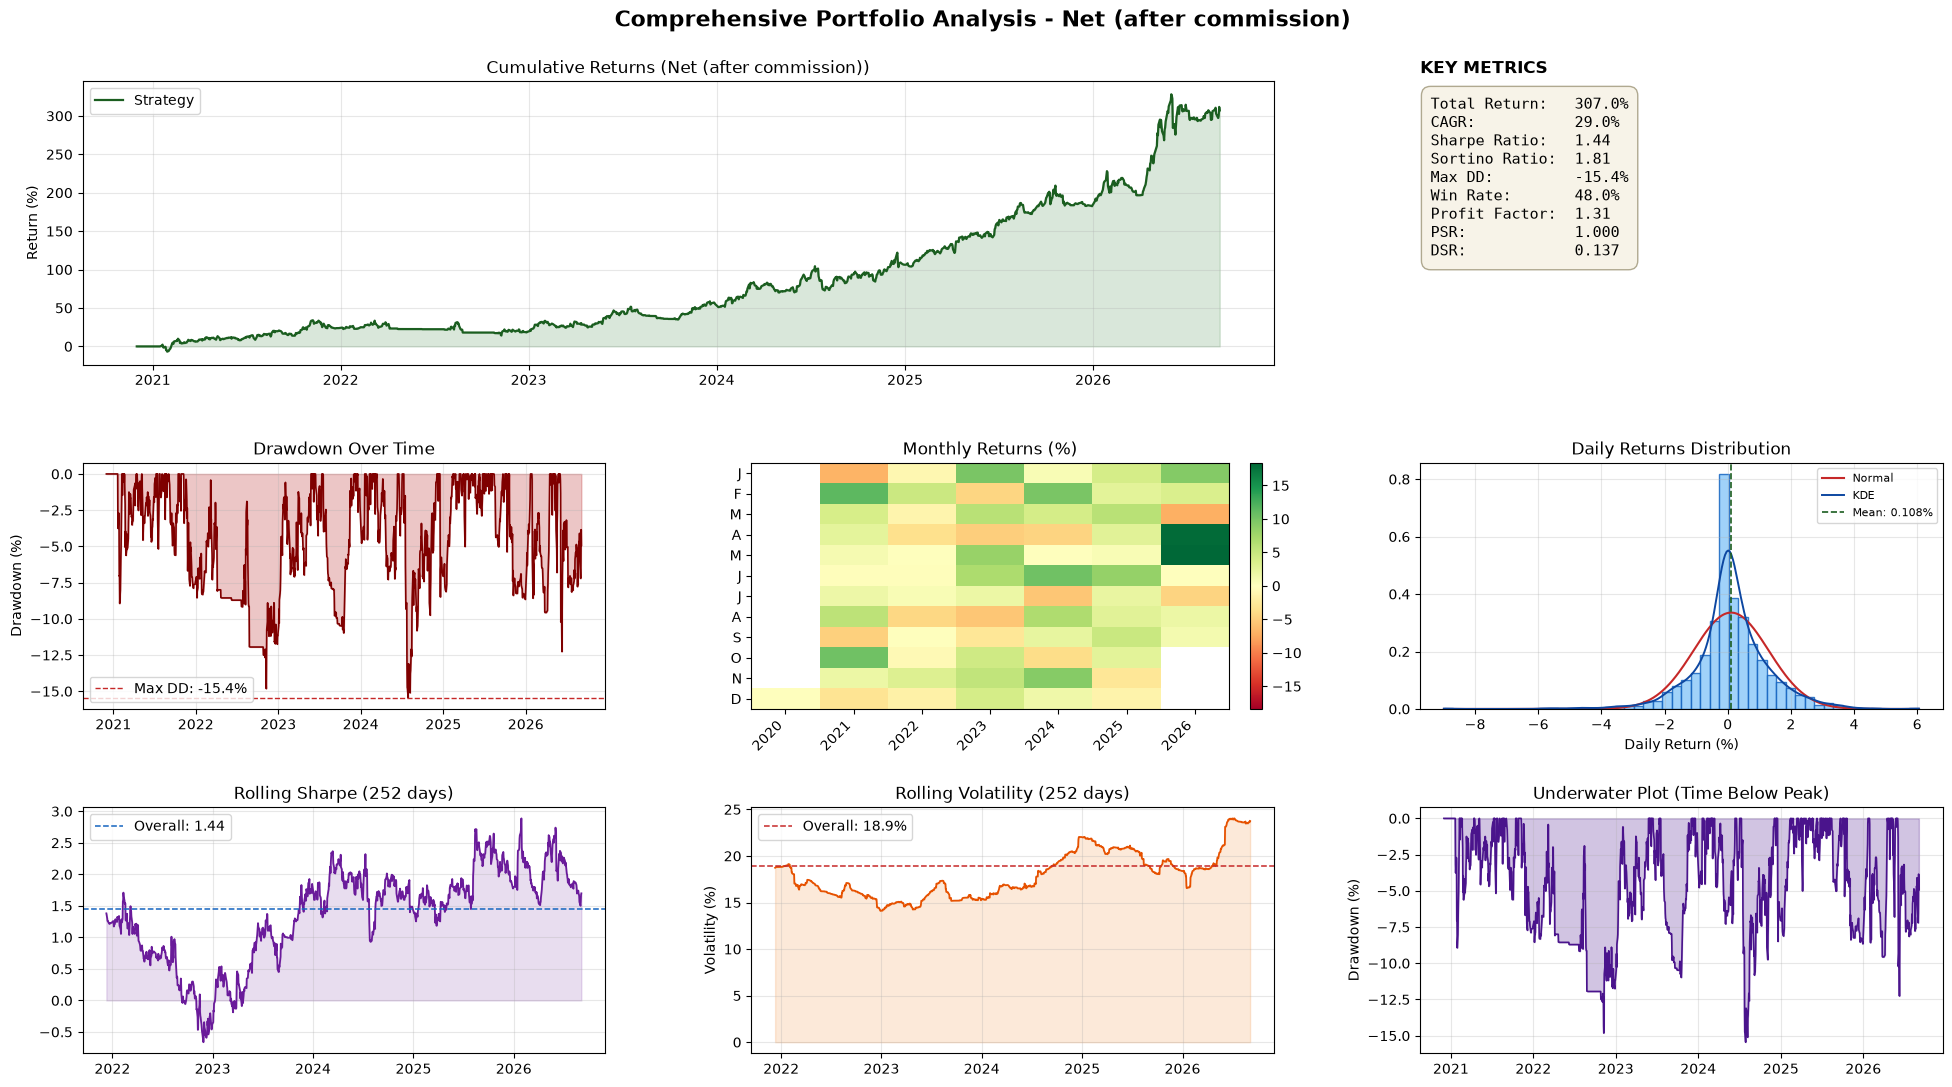

Step 5 Visuals Complete


In [164]:
# BACKTEST ANALYSIS: COMPREHENSIVE PORTFOLIO DASHBOARD
# Uses net returns and the metrics computed in the previous cell.

from scipy import stats

if "returns" not in globals() or "backtest_metrics" not in globals() or "label" not in globals():
    raise NameError("Backtest metrics are missing. Run the net-returns / metrics cell first.")
if not isinstance(returns, pd.Series) or returns.empty:
    raise ValueError("returns is missing or empty. Run the net-returns / metrics cell first.")
if not isinstance(backtest_metrics, dict):
    raise TypeError("backtest_metrics must be a dict from the metrics cell.")
if not isinstance(returns.index, pd.DatetimeIndex):
    raise TypeError("returns index must be a DatetimeIndex for monthly resampling.")

required_metric_keys = (
    "portfolio_value",
    "drawdown",
    "total_return",
    "cagr",
    "sharpe_ratio",
    "sortino_ratio",
    "max_drawdown",
    "win_rate",
    "profit_factor",
    "psr",
    "dsr",
    "annual_volatility",
    "mean_daily",
    "std_daily",
)
missing_keys = [k for k in required_metric_keys if k not in backtest_metrics]
if missing_keys:
    raise KeyError(f"backtest_metrics is missing {missing_keys}. Re-run the metrics cell.")

portfolio_value = backtest_metrics["portfolio_value"]
drawdown = backtest_metrics["drawdown"]
if not isinstance(portfolio_value, pd.Series) or not isinstance(drawdown, pd.Series):
    raise TypeError("portfolio_value and drawdown must be pandas Series.")
if not portfolio_value.index.equals(returns.index) or not drawdown.index.equals(returns.index):
    raise ValueError("portfolio_value / drawdown index does not match returns.")

if "rolling_sharpe" not in globals() or "rolling_std" not in globals():
    raise NameError("Rolling metrics are missing. Run the net-returns / metrics cell first.")
if not isinstance(rolling_sharpe, pd.Series) or not isinstance(rolling_std, pd.Series):
    raise TypeError("rolling_sharpe and rolling_std must be pandas Series.")
if not rolling_sharpe.index.equals(returns.index) or not rolling_std.index.equals(returns.index):
    raise ValueError("Rolling metric indexes do not match returns.")

returns_pct = returns * 100.0
cum_pct = (portfolio_value - 1.0) * 100.0
dd_pct = drawdown * 100.0

monthly_returns = returns.resample("ME").apply(lambda x: (1.0 + x).prod() - 1.0)
if bool((~np.isfinite(monthly_returns.to_numpy(dtype=float))).any()):
    raise ValueError("Monthly compounded returns are non-finite.")
monthly_df = monthly_returns.to_frame("ret")
monthly_df["year"] = monthly_df.index.year
monthly_df["month"] = monthly_df.index.month
heat = monthly_df.pivot(index="month", columns="year", values="ret") * 100.0
heat = heat.reindex(range(1, 13))

month_labels = list("JFMAMJJASOND")
mean_pct = float(backtest_metrics["mean_daily"]) * 100.0
std_pct = float(backtest_metrics["std_daily"]) * 100.0

fig = plt.figure(figsize=(24, 12))
fig.patch.set_facecolor("white")
gs = fig.add_gridspec(3, 3, height_ratios=[1.15, 1.0, 1.0], hspace=0.38, wspace=0.28)
fig.suptitle(
    f"Comprehensive Portfolio Analysis - {label}",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

ax_cum = fig.add_subplot(gs[0, :2])
ax_metrics = fig.add_subplot(gs[0, 2])
ax_dd = fig.add_subplot(gs[1, 0])
ax_heat = fig.add_subplot(gs[1, 1])
ax_dist = fig.add_subplot(gs[1, 2])
ax_rsharpe = fig.add_subplot(gs[2, 0])
ax_rvol = fig.add_subplot(gs[2, 1])
ax_uw = fig.add_subplot(gs[2, 2])

cum_vals = cum_pct.to_numpy(dtype=float)
ax_cum.fill_between(cum_pct.index, cum_vals, 0.0, color="#2e7d32", alpha=0.18)
ax_cum.plot(cum_pct.index, cum_vals, color="#1b5e20", lw=1.6, label="Strategy")
ax_cum.set_title(f"Cumulative Returns ({label})")
ax_cum.set_ylabel("Return (%)")
ax_cum.legend(loc="upper left")
ax_cum.grid(True, alpha=0.3)

pf = backtest_metrics["profit_factor"]
pf_txt = f"{pf:.2f}" if np.isfinite(pf) else "inf"
ax_metrics.axis("off")
ax_metrics.set_title("KEY METRICS", fontweight="bold", loc="left")
metrics_text = (
    f"Total Return:   {backtest_metrics['total_return']:.1%}\n"
    f"CAGR:           {backtest_metrics['cagr']:.1%}\n"
    f"Sharpe Ratio:   {backtest_metrics['sharpe_ratio']:.2f}\n"
    f"Sortino Ratio:  {backtest_metrics['sortino_ratio']:.2f}\n"
    f"Max DD:         {backtest_metrics['max_drawdown']:.1%}\n"
    f"Win Rate:       {backtest_metrics['win_rate']:.1%}\n"
    f"Profit Factor:  {pf_txt}\n"
    f"PSR:            {backtest_metrics['psr']:.3f}\n"
    f"DSR:            {backtest_metrics['dsr']:.3f}"
)
ax_metrics.text(
    0.02,
    0.95,
    metrics_text,
    transform=ax_metrics.transAxes,
    va="top",
    ha="left",
    family="monospace",
    fontsize=11,
    bbox={"boxstyle": "round,pad=0.6", "facecolor": "#f7f3e8", "edgecolor": "#b0a990"},
)

dd_vals = dd_pct.to_numpy(dtype=float)
ax_dd.fill_between(dd_pct.index, dd_vals, 0.0, color="#b71c1c", alpha=0.25)
ax_dd.plot(dd_pct.index, dd_vals, color="#7f0000", lw=1.2)
ax_dd.axhline(
    backtest_metrics["max_drawdown"] * 100.0,
    color="#c62828",
    ls="--",
    lw=1.0,
    label=f"Max DD: {backtest_metrics['max_drawdown']:.1%}",
)
ax_dd.set_title("Drawdown Over Time")
ax_dd.set_ylabel("Drawdown (%)")
ax_dd.legend(loc="lower left")
ax_dd.grid(True, alpha=0.3)

heat_vals = heat.to_numpy(dtype=float)
finite_heat = heat_vals[np.isfinite(heat_vals)]
vmax = max(float(np.max(np.abs(finite_heat))), 1.0) if finite_heat.size else 10.0
im = ax_heat.imshow(heat_vals, aspect="auto", cmap="RdYlGn", vmin=-vmax, vmax=vmax)
ax_heat.set_title("Monthly Returns (%)")
ax_heat.set_yticks(range(12))
ax_heat.set_yticklabels(month_labels)
ax_heat.set_xticks(range(len(heat.columns)))
ax_heat.set_xticklabels([str(c) for c in heat.columns], rotation=45, ha="right")
fig.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)

finite_pct = returns_pct.to_numpy(dtype=float)
finite_pct = finite_pct[np.isfinite(finite_pct)]
if finite_pct.size == 0:
    raise ValueError("No finite daily returns to plot.")
n_bins = int(min(50, max(10, finite_pct.size // 5)))
ax_dist.hist(finite_pct, bins=n_bins, density=True, color="#90caf9", edgecolor="#1565c0", alpha=0.85)
if finite_pct.size >= 8 and std_pct > 0:
    xs = np.linspace(float(np.min(finite_pct)), float(np.max(finite_pct)), 300)
    ax_dist.plot(xs, stats.norm.pdf(xs, loc=mean_pct, scale=std_pct), color="#c62828", lw=1.5, label="Normal")
    try:
        kde = stats.gaussian_kde(finite_pct)
        ax_dist.plot(xs, kde(xs), color="#0d47a1", lw=1.4, label="KDE")
    except (np.linalg.LinAlgError, ValueError):
        pass
ax_dist.axvline(mean_pct, color="#1b5e20", ls="--", lw=1.2, label=f"Mean: {mean_pct:.3f}%")
ax_dist.set_title("Daily Returns Distribution")
ax_dist.set_xlabel("Daily Return (%)")
ax_dist.legend(loc="upper right", fontsize=8)
ax_dist.grid(True, alpha=0.3)

rs = rolling_sharpe.replace([np.inf, -np.inf], np.nan)
ax_rsharpe.fill_between(rs.index, rs.to_numpy(dtype=float), 0.0, color="#6a1b9a", alpha=0.15)
ax_rsharpe.plot(rs.index, rs.to_numpy(dtype=float), color="#6a1b9a", lw=1.3)
ax_rsharpe.axhline(
    backtest_metrics["sharpe_ratio"],
    color="#1565c0",
    ls="--",
    lw=1.1,
    label=f"Overall: {backtest_metrics['sharpe_ratio']:.2f}",
)
ax_rsharpe.set_title("Rolling Sharpe (252 days)")
ax_rsharpe.legend(loc="upper left")
ax_rsharpe.grid(True, alpha=0.3)

rv = rolling_std.replace([np.inf, -np.inf], np.nan) * 100.0
ax_rvol.fill_between(rv.index, rv.to_numpy(dtype=float), 0.0, color="#ef6c00", alpha=0.15)
ax_rvol.plot(rv.index, rv.to_numpy(dtype=float), color="#e65100", lw=1.3)
ax_rvol.axhline(
    backtest_metrics["annual_volatility"] * 100.0,
    color="#c62828",
    ls="--",
    lw=1.1,
    label=f"Overall: {backtest_metrics['annual_volatility']:.1%}",
)
ax_rvol.set_title("Rolling Volatility (252 days)")
ax_rvol.set_ylabel("Volatility (%)")
ax_rvol.legend(loc="upper left")
ax_rvol.grid(True, alpha=0.3)

ax_uw.fill_between(dd_pct.index, dd_vals, 0.0, color="#4a148c", alpha=0.25)
ax_uw.plot(dd_pct.index, dd_vals, color="#4a148c", lw=1.2)
ax_uw.set_title("Underwater Plot (Time Below Peak)")
ax_uw.set_ylabel("Drawdown (%)")
ax_uw.grid(True, alpha=0.3)

fig.subplots_adjust(top=0.92)
plt.show()
print("Step 5 Visuals Complete")


Dropped 1 incomplete day(s) from the static benchmark (1 missing print(s): 2020-12-01 SMH.L).
STEP 6: STATIC BENCHMARKS (MAX SHARPE / MAX OMEGA)
In-sample long-only, fully invested, fixed weights. Evaluated on the same dates.
This is an optimistic bound (weights see the whole sample), not a walk-forward test.
Constant-mix returns assume daily rebalancing; only the opening buy is charged commission.
Initial commission on the static book: 0.100% (one buy, no further turnover).

Optimized static weights
--------------------------------------------------------------------------------
Ticker           Max Sharpe      Max Omega
QTUM                 18.39%         21.73%
BTC-USD               1.13%          0.44%
TQQQ                  0.00%          0.00%
SMH.L                20.41%         14.35%
MGK                   0.00%          0.00%
UPRO                  0.00%          0.00%
GLD                  49.77%         53.87%
^STOXX50E            10.30%          9.61%
SUM                 100.00

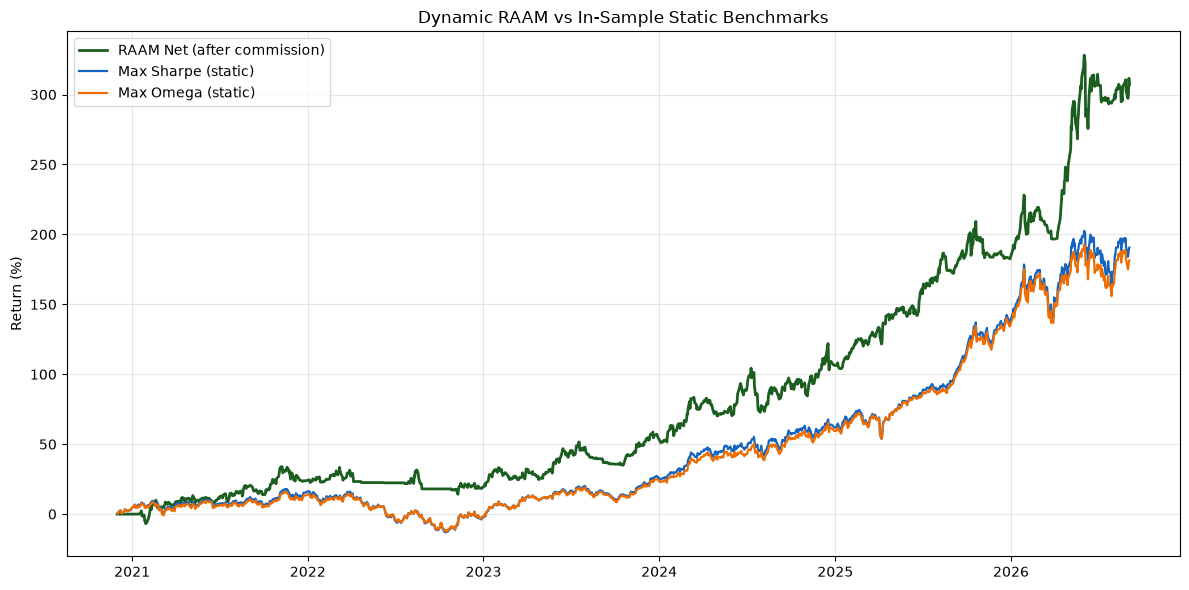

Step 6 Complete


In [165]:
# BACKTEST ANALYSIS: MAX SHARPE AND MAX OMEGA STATIC BENCHMARKS
# In-sample long-only fixed weights over the same dates as the dynamic strategy.

from scipy.optimize import minimize

if "allocation_df" not in globals() or "combined_df" not in globals():
    raise NameError("allocation_df / combined_df are missing. Run the strategy-execution cells first.")
if "tickers" not in globals():
    raise NameError("tickers is missing. Run the parameter-validation cell first.")
if "returns" not in globals() or "backtest_metrics" not in globals() or "compute_performance_metrics" not in globals():
    raise NameError("Backtest metrics are missing. Run the net-returns / metrics cell first.")
if "COMMISSION_RATE" not in globals():
    raise NameError("COMMISSION_RATE is missing. Run the net-returns / metrics cell first.")
if "label" not in globals():
    raise NameError("label is missing. Run the net-returns / metrics cell first.")
if "N_TRIALS" not in globals():
    raise NameError("N_TRIALS is missing. Run the net-returns / metrics cell first.")
if not callable(compute_performance_metrics):
    raise TypeError("compute_performance_metrics is not callable. Re-run the metrics cell.")
if not isinstance(backtest_metrics, dict):
    raise TypeError("backtest_metrics must be a dict from the metrics cell.")
if not isinstance(returns, pd.Series) or returns.empty:
    raise ValueError("returns is missing or empty. Run the metrics cell first.")

if not isinstance(combined_df, pd.DataFrame) or combined_df.empty:
    raise ValueError("combined_df is missing or empty.")
if not isinstance(allocation_df, pd.DataFrame) or allocation_df.empty:
    raise ValueError("allocation_df is missing or empty.")
if not combined_df.index.equals(allocation_df.index):
    raise ValueError("allocation_df and combined_df indexes do not match.")
if not returns.index.equals(allocation_df.index) and not (
    isinstance(returns.index, pd.DatetimeIndex)
    and pd.DatetimeIndex(allocation_df.index).equals(returns.index)
):
    # Allow timezone-naive vs converted datetime, but length and order must match.
    if len(returns) != len(allocation_df) or not np.array_equal(
        pd.DatetimeIndex(allocation_df.index).asi8, pd.DatetimeIndex(returns.index).asi8
    ):
        raise ValueError("Strategy returns do not align with allocation_df dates.")

tickers = [str(t) for t in tickers]
if len(tickers) < 1 or len(set(tickers)) != len(tickers):
    raise ValueError(f"tickers must be a unique non-empty list; got {tickers}")
ret_cols = [f"{ticker}_Return" for ticker in tickers]
missing_r = [col for col in ret_cols if col not in combined_df.columns]
if missing_r:
    raise KeyError(f"combined_df is missing return column(s): {missing_r}")

try:
    commission_rate = float(COMMISSION_RATE)
except (TypeError, ValueError) as exc:
    raise ValueError(f"COMMISSION_RATE must be numeric; got {COMMISSION_RATE!r}") from exc
if not np.isfinite(commission_rate) or commission_rate < 0 or commission_rate >= 1.0:
    raise ValueError(f"COMMISSION_RATE must be in [0, 1); got {COMMISSION_RATE!r}")

try:
    asset_ret = combined_df.loc[:, ret_cols].replace([np.inf, -np.inf], np.nan).astype(float)
except (TypeError, ValueError) as exc:
    raise TypeError(f"Asset returns must be numeric: {exc}") from exc
asset_ret.columns = tickers
asset_ret = asset_ret.reindex(allocation_df.index)
if bool(asset_ret.isna().all().any()):
    bad = [t for t in tickers if bool(asset_ret[t].isna().all())]
    raise ValueError(f"No finite Buy & Hold returns in the backtest window: {bad}")
missing_mask = asset_ret.isna()
n_missing = int(missing_mask.to_numpy(dtype=bool).sum())
if n_missing:
    missing_locs = []
    for col in asset_ret.columns:
        for idx in asset_ret.index[missing_mask[col]]:
            date_label = idx.date() if hasattr(idx, "date") else idx
            missing_locs.append(f"{date_label} {col}")
    complete = asset_ret.dropna(how="any")
    n_dropped = int(len(asset_ret) - len(complete))
    preview = ", ".join(missing_locs[:8])
    extra = " ..." if len(missing_locs) > 8 else ""
    if len(complete) < 20:
        raise ValueError(
            f"{n_missing} missing Buy & Hold return(s) ({preview}{extra}); "
            f"only {len(complete)} complete day(s) remain."
        )
    print(
        f"Dropped {n_dropped} incomplete day(s) from the static benchmark "
        f"({n_missing} missing print(s): {preview}{extra})."
    )
    asset_ret = complete
R = asset_ret.to_numpy(dtype=float)
if R.shape[0] < 20:
    raise ValueError(f"Need at least 20 days to optimize static weights; got {R.shape[0]}.")
n_assets = R.shape[1]
if n_assets < 1:
    raise ValueError("No assets available for static optimization.")

print("=" * 80)
print("STEP 6: STATIC BENCHMARKS (MAX SHARPE / MAX OMEGA)")
print("=" * 80)
print("In-sample long-only, fully invested, fixed weights. Evaluated on the same dates.")
print("This is an optimistic bound (weights see the whole sample), not a walk-forward test.")
print("Constant-mix returns assume daily rebalancing; only the opening buy is charged commission.")
print(f"Initial commission on the static book: {commission_rate:.3%} (one buy, no further turnover).")
print()


def _portfolio_returns(weights, returns_mat):
    w = np.asarray(weights, dtype=float)
    if w.shape != (returns_mat.shape[1],):
        raise ValueError("Weight vector length does not match the return matrix.")
    if not np.isfinite(w).all():
        raise ValueError("Weight vector contains non-finite values.")
    return returns_mat @ w


def _neg_sharpe(weights, returns_mat):
    port = _portfolio_returns(weights, returns_mat)
    mu = float(np.mean(port))
    sig = float(np.std(port, ddof=1))
    if not np.isfinite(sig) or sig <= 0:
        return -1.0e12 if mu > 0 else 1.0e12
    return -((mu / sig) * np.sqrt(252.0))


def _neg_omega(weights, returns_mat):
    port = _portfolio_returns(weights, returns_mat)
    gains = float(np.sum(port[port > 0]))
    losses = float(np.abs(np.sum(port[port < 0])))
    if losses <= 1e-18:
        return -1.0e12 if gains > 0 else 0.0
    return -(gains / losses)


def _weights_feasible(weights, n):
    w = np.asarray(weights, dtype=float)
    if w.shape != (n,) or not np.isfinite(w).all():
        return False
    if np.any(w < -1e-8) or np.any(w > 1.0 + 1e-8):
        return False
    return abs(float(w.sum()) - 1.0) < 1e-6


def _optimize_static(objective, returns_mat, starts):
    n = returns_mat.shape[1]
    bounds = [(0.0, 1.0)] * n
    cons = ({"type": "eq", "fun": lambda w: float(np.sum(w) - 1.0)},)
    best = None
    best_fun = np.inf
    for start in starts:
        w0 = np.asarray(start, dtype=float)
        if w0.shape != (n,) or not np.isfinite(w0).all():
            continue
        w0 = np.clip(w0, 0.0, 1.0)
        if w0.sum() <= 0:
            continue
        w0 = w0 / w0.sum()
        result = minimize(
            objective,
            w0,
            args=(returns_mat,),
            method="SLSQP",
            bounds=bounds,
            constraints=cons,
            options={"maxiter": 500, "ftol": 1e-12},
        )
        if result.x is None or not np.isfinite(result.fun):
            continue
        if not _weights_feasible(result.x, n):
            continue
        if float(result.fun) < best_fun:
            best_fun = float(result.fun)
            best = result
    if best is None:
        raise RuntimeError("Static-weight optimizer failed from every starting point.")
    weights = np.clip(best.x, 0.0, 1.0)
    weights[weights < 1e-8] = 0.0
    if weights.sum() <= 0:
        raise RuntimeError("Static-weight optimizer returned only numerically zero weights.")
    weights = weights / weights.sum()
    return weights


equal = np.ones(n_assets) / n_assets
vertices = [np.eye(n_assets)[i] for i in range(n_assets)]
sharpe_starts = [equal] + vertices
max_sharpe_weights = _optimize_static(_neg_sharpe, R, sharpe_starts)
omega_starts = [equal, max_sharpe_weights] + vertices
max_omega_weights = _optimize_static(_neg_omega, R, omega_starts)

static_sharpe = pd.Series(_portfolio_returns(max_sharpe_weights, R), index=asset_ret.index)
static_omega = pd.Series(_portfolio_returns(max_omega_weights, R), index=asset_ret.index)
static_sharpe.iloc[0] = static_sharpe.iloc[0] - commission_rate
static_omega.iloc[0] = static_omega.iloc[0] - commission_rate
if bool((static_sharpe < -1.0 + 1e-15).any()) or bool((static_omega < -1.0 + 1e-15).any()):
    raise ValueError("Static benchmark return is <= -100% after the opening commission.")

sharpe_metrics = compute_performance_metrics(static_sharpe, n_trials=N_TRIALS)
omega_metrics = compute_performance_metrics(static_omega, n_trials=N_TRIALS)
max_sharpe_w = pd.Series(max_sharpe_weights, index=tickers, name="Max_Sharpe_Weight")
max_omega_w = pd.Series(max_omega_weights, index=tickers, name="Max_Omega_Weight")

print("Optimized static weights")
print("-" * 80)
print(f"{'Ticker':<12} {'Max Sharpe':>14} {'Max Omega':>14}")
for ticker in tickers:
    print(f"{ticker:<12} {float(max_sharpe_w[ticker]):14.2%} {float(max_omega_w[ticker]):14.2%}")
print(f"{'SUM':<12} {float(max_sharpe_w.sum()):14.2%} {float(max_omega_w.sum()):14.2%}")
print()


def _fmt_pct(value):
    return f"{value:>14.2%}"


def _fmt_num(value):
    if not np.isfinite(value):
        return f"{'inf':>14}"
    return f"{value:>14.3f}"


def _beats(strategy_val, bench_val, higher_is_better=True):
    s = strategy_val
    b = bench_val
    if not np.isfinite(s) and not np.isfinite(b):
        return False
    if not np.isfinite(s):
        return (s == np.inf) if higher_is_better else (s == -np.inf)
    if not np.isfinite(b):
        return (b == -np.inf) if higher_is_better else (b == np.inf)
    return (s > b) if higher_is_better else (s < b)


rows = [
    ("Total Return", "total_return", _fmt_pct),
    ("CAGR", "cagr", _fmt_pct),
    ("Ann. Volatility", "annual_volatility", _fmt_pct),
    ("Sharpe Ratio", "sharpe_ratio", _fmt_num),
    ("Sortino Ratio", "sortino_ratio", _fmt_num),
    ("Omega Ratio", "omega_ratio", _fmt_num),
    ("Max Drawdown", "max_drawdown", _fmt_pct),
    ("Calmar Ratio", "calmar_ratio", _fmt_num),
    ("PSR", "psr", _fmt_num),
    ("DSR", "dsr", _fmt_num),
]

print(f"{'Metric':<18} {'Strategy':>14} {'Max Sharpe':>14} {'Max Omega':>14}")
print("-" * 80)
for name, key, fmt in rows:
    print(
        f"{name:<18} {fmt(backtest_metrics[key])} "
        f"{fmt(sharpe_metrics[key])} {fmt(omega_metrics[key])}"
    )
print()

beat_sharpe = _beats(backtest_metrics["sharpe_ratio"], sharpe_metrics["sharpe_ratio"])
beat_omega = _beats(backtest_metrics["omega_ratio"], omega_metrics["omega_ratio"])
beat_cagr_sharpe = _beats(backtest_metrics["cagr"], sharpe_metrics["cagr"])
beat_cagr_omega = _beats(backtest_metrics["cagr"], omega_metrics["cagr"])
print("Does the dynamic strategy beat the in-sample static bound?")
print(
    f"  Sharpe vs Max Sharpe: {beat_sharpe}  "
    f"({_fmt_num(backtest_metrics['sharpe_ratio']).strip()} vs {_fmt_num(sharpe_metrics['sharpe_ratio']).strip()})"
)
print(
    f"  Omega vs Max Omega:   {beat_omega}  "
    f"({_fmt_num(backtest_metrics['omega_ratio']).strip()} vs {_fmt_num(omega_metrics['omega_ratio']).strip()})"
)
print(
    f"  CAGR vs Max Sharpe:   {beat_cagr_sharpe}  "
    f"({backtest_metrics['cagr']:.2%} vs {sharpe_metrics['cagr']:.2%})"
)
print(
    f"  CAGR vs Max Omega:    {beat_cagr_omega}  "
    f"({backtest_metrics['cagr']:.2%} vs {omega_metrics['cagr']:.2%})"
)
print()

if "portfolio_value" not in backtest_metrics:
    raise KeyError("backtest_metrics is missing portfolio_value.")
strat_cum = backtest_metrics["portfolio_value"]
sharpe_cum = (1.0 + static_sharpe).cumprod()
omega_cum = (1.0 + static_omega).cumprod()
if bool((sharpe_cum.to_numpy(dtype=float) <= 0).any()) or bool((omega_cum.to_numpy(dtype=float) <= 0).any()):
    raise ValueError("A static benchmark path hit 0 or below.")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(strat_cum.index, (strat_cum - 1.0) * 100.0, color="#1b5e20", lw=2.0, label=f"RAAM {label}")
ax.plot(sharpe_cum.index, (sharpe_cum - 1.0) * 100.0, color="#1565c0", lw=1.6, label="Max Sharpe (static)")
ax.plot(omega_cum.index, (omega_cum - 1.0) * 100.0, color="#ef6c00", lw=1.6, label="Max Omega (static)")
ax.set_title("Dynamic RAAM vs In-Sample Static Benchmarks")
ax.set_ylabel("Return (%)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("Step 6 Complete")


In [166]:
# YEAR-BY-YEAR BREAKDOWN & ASSET ALLOCATION STATISTICS
# Calendar-year metrics plus how often the book was full, partial, or cash.

if "returns" not in globals():
    raise NameError("returns is missing. Run the metrics cell first.")
if "allocation_df" not in globals():
    raise NameError("allocation_df is missing. Run the daily-returns cell first.")
if "tickers" not in globals():
    raise NameError("tickers is missing. Run the parameter-validation cell first.")
if "SAFE_HAVEN" not in globals():
    raise NameError("SAFE_HAVEN is missing. Run the parameter-validation cell first.")

if not isinstance(returns, pd.Series) or returns.empty:
    raise ValueError("returns must be a non-empty pandas Series from the metrics cell.")
if not isinstance(allocation_df, pd.DataFrame) or allocation_df.empty:
    raise ValueError("allocation_df is missing or empty.")
if not isinstance(tickers, (list, tuple, pd.Index)) or len(tickers) < 1:
    raise TypeError(f"tickers must be a non-empty sequence; got {type(tickers).__name__}")

ticker_list = [str(t) for t in tickers]
if any(not t for t in ticker_list):
    raise ValueError("tickers contains a blank name.")
if len(set(ticker_list)) != len(ticker_list):
    raise ValueError(f"Duplicate ticker(s): {ticker_list}")
safe_haven = str(SAFE_HAVEN).strip()
if not safe_haven:
    raise ValueError(f"SAFE_HAVEN must be a non-empty ticker; got {SAFE_HAVEN!r}")
if safe_haven not in ticker_list:
    raise KeyError(f"SAFE_HAVEN={safe_haven!r} is not in tickers {ticker_list}.")

try:
    returns_dt = pd.Series(returns, copy=True).astype(float)
except (TypeError, ValueError) as exc:
    raise TypeError(f"returns must be numeric: {exc}") from exc
if bool((~np.isfinite(returns_dt.to_numpy(dtype=float))).any()):
    raise ValueError("returns contains non-finite values.")
if bool((returns_dt < -1.0 + 1e-15).any()):
    raise ValueError("returns contains a day <= -100%; yearly compounding is undefined.")

if not isinstance(returns_dt.index, pd.DatetimeIndex):
    returns_dt.index = pd.to_datetime(returns_dt.index, errors="coerce")
if bool(pd.isna(returns_dt.index).any()):
    raise ValueError("returns index must be datetime; some values could not be parsed.")
if returns_dt.index.has_duplicates:
    raise ValueError("returns has duplicate dates; yearly compounding would double-count.")
if not returns_dt.index.is_monotonic_increasing:
    raise ValueError("returns is not sorted by date; year buckets would be wrong.")

weight_cols = [f"{ticker}_Weight" for ticker in ticker_list]
needed_cols = weight_cols + ["Total_Weight"]
missing_w = [col for col in needed_cols if col not in allocation_df.columns]
if missing_w:
    raise KeyError(f"allocation_df is missing weight column(s): {missing_w}")

alloc_idx = allocation_df.index
if not isinstance(alloc_idx, pd.DatetimeIndex):
    alloc_idx = pd.to_datetime(alloc_idx, errors="coerce")
if bool(pd.isna(alloc_idx).any()):
    raise ValueError("allocation_df index must be datetime; some values could not be parsed.")
alloc_idx = pd.DatetimeIndex(alloc_idx)
if not alloc_idx.equals(returns_dt.index):
    raise ValueError("returns and allocation_df indexes do not match.")

try:
    weight_mat = allocation_df.loc[:, weight_cols].astype(float).copy()
    total_weight = allocation_df["Total_Weight"].astype(float).copy()
except (TypeError, ValueError) as exc:
    raise TypeError(f"Weight columns must be numeric: {exc}") from exc
weight_mat.index = returns_dt.index
total_weight.index = returns_dt.index
if bool((~np.isfinite(weight_mat.to_numpy(dtype=float))).any()) or bool(
    (~np.isfinite(total_weight.to_numpy(dtype=float))).any()
):
    raise ValueError("Weights contain non-finite values.")
if bool((weight_mat.to_numpy(dtype=float) < -1e-9).any()) or bool((total_weight < -1e-9).any()):
    raise ValueError("Weights have negative values.")
if not np.allclose(total_weight.to_numpy(dtype=float), weight_mat.sum(axis=1).to_numpy(dtype=float), atol=1e-9):
    raise ValueError("Total_Weight does not match the sum of asset weights.")

WEIGHT_EPS = 1e-9
is_held = ~np.isclose(weight_mat.to_numpy(dtype=float), 0.0)
is_held = pd.DataFrame(is_held, index=weight_mat.index, columns=weight_cols)
is_cash = pd.Series(np.isclose(total_weight.to_numpy(dtype=float), 0.0), index=total_weight.index)
is_full = total_weight >= (1.0 - WEIGHT_EPS)
is_partial = ~is_cash & ~is_full
n_days = len(returns_dt)
mean_allocation = float(total_weight.mean())
days_full = int(is_full.sum())
days_partial = int(is_partial.sum())
days_cash = int(is_cash.sum())
if days_full + days_partial + days_cash != n_days:
    raise ValueError("Cash / partial / full day counts do not cover the sample.")


def _period_metrics(r):
    r = pd.Series(r, copy=False).astype(float)
    n = int(len(r))
    if n < 1:
        raise ValueError("A reporting window is empty.")
    total = float((1.0 + r).prod() - 1.0)
    vol = float(r.std(ddof=1) * np.sqrt(252.0)) if n > 1 else 0.0
    if not np.isfinite(vol) or vol <= 0:
        vol = 0.0
        sharpe = 0.0
    else:
        sharpe = float(r.mean() * 252.0 / vol)
    cum = (1.0 + r).cumprod()
    cum_vals = cum.to_numpy(dtype=float)
    if bool((cum_vals <= 0).any()) or bool((~np.isfinite(cum_vals)).any()):
        raise ValueError("Cumulative wealth is non-finite or <= 0 for a reporting window.")
    max_dd = float((cum / cum.cummax() - 1.0).min())
    win = float((r > 0).sum() / n)
    if not np.isfinite(total) or not np.isfinite(sharpe) or not np.isfinite(max_dd):
        raise ValueError("A reporting window produced a non-finite metric.")
    return n, total, vol, sharpe, max_dd, win


print("=" * 80)
print("YEAR-BY-YEAR PERFORMANCE & ASSET ALLOCATION ANALYSIS")
print("=" * 80)

# --------------------------------------------------------------------------------------------------------------------
# 1) YEAR-BY-YEAR METRICS
# --------------------------------------------------------------------------------------------------------------------
print("\n📊 YEAR-BY-YEAR PERFORMANCE METRICS:\n")

year_ids = returns_dt.index.year
yearly_data = []
for year in sorted(pd.unique(year_ids)):
    year_mask = year_ids == year
    year_returns = returns_dt[year_mask]
    year_w = total_weight[year_mask]
    year_cash = is_cash[year_mask]
    year_full = is_full[year_mask]
    n, tot, vol, sharpe, max_dd, win = _period_metrics(year_returns)
    yearly_data.append({
        "Year": int(year),
        "Trading Days": n,
        "Total Return": tot,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Max DD": max_dd,
        "Win Rate": win,
        "Avg Allocation": float(year_w.mean()),
        "% Days Full": float(year_full.sum() / n * 100.0),
        "% Days Cash": float(year_cash.sum() / n * 100.0),
    })

if not yearly_data:
    raise ValueError("No yearly rows to report. Check that returns has a datetime index with years.")

yearly_df = pd.DataFrame(yearly_data)
n_tot, total_return, annual_volatility, sharpe_ratio, max_drawdown, win_rate = _period_metrics(returns_dt)
if n_tot != n_days or int(yearly_df["Trading Days"].sum()) != n_days:
    raise ValueError("Yearly day counts do not sum to the full sample.")

_yoy_header = (
    f"{'Year':<6}  {'Days':>5}  {'Return':>9}  {'Vol':>6}  {'Sharpe':>7}  "
    f"{'Max DD':>8}  {'Win%':>6}  {'Avg Alloc':>9}  {'Full%':>6}  {'Cash%':>6}"
)
print(_yoy_header)
print("-" * len(_yoy_header))

for _, row in yearly_df.iterrows():
    print(
        f"{int(row['Year']):<6}  {int(row['Trading Days']):>5}  "
        f"{row['Total Return']:>9.2%}  {row['Volatility']:>6.1%}  {row['Sharpe']:>7.2f}  "
        f"{row['Max DD']:>8.2%}  {row['Win Rate']:>6.1%}  {row['Avg Allocation']:>9.1%}  "
        f"{row['% Days Full'] / 100.0:>6.1%}  {row['% Days Cash'] / 100.0:>6.1%}"
    )

print("-" * len(_yoy_header))
print(
    f"{'TOTAL':<6}  {n_tot:>5}  "
    f"{total_return:>9.2%}  {annual_volatility:>6.1%}  {sharpe_ratio:>7.2f}  "
    f"{max_drawdown:>8.2%}  {win_rate:>6.1%}  {mean_allocation:>9.1%}  "
    f"{days_full / n_days:>6.1%}  {days_cash / n_days:>6.1%}"
)

# --------------------------------------------------------------------------------------------------------------------
# 2) ASSET ALLOCATION BREAKDOWN
# --------------------------------------------------------------------------------------------------------------------
print("\n\n📊 ASSET ALLOCATION STATISTICS:\n")

print("Overall Portfolio Allocation:")
print(f"Mean allocation:          {mean_allocation:.2%}")
print(f"Days 100% allocated:     {days_full} ({days_full / n_days * 100.0:.1f}%)")
print(f"Days partially allocated: {days_partial} ({days_partial / n_days * 100.0:.1f}%)")
print(f"Days in cash (0%):       {days_cash} ({days_cash / n_days * 100.0:.1f}%)")

days_held = is_held.sum(axis=0)
pct_of_days = days_held.astype(float) / n_days * 100.0
avg_weight = weight_mat.mean()
max_weight = weight_mat.max()
avg_when_held = weight_mat.where(is_held).mean()

print("\nIndividual Asset Statistics:")
print(
    f"{'Asset':<12} {'Days Held':>10} {'% of Days':>10} "
    f"{'Avg Weight':>12} {'Max Weight':>12} {'Avg When Held':>15}"
)
print("-" * 80)

for ticker, weight_col in zip(ticker_list, weight_cols):
    held_n = int(days_held[weight_col])
    when_held = float(avg_when_held[weight_col]) if held_n > 0 and np.isfinite(avg_when_held[weight_col]) else 0.0
    haven_tag = " (safe haven)" if ticker == safe_haven else ""
    print(
        f"{ticker:<12} {held_n:>10} {pct_of_days[weight_col]:>9.1f}% "
        f"{float(avg_weight[weight_col]):>11.2%} {float(max_weight[weight_col]):>11.2%} "
        f"{when_held:>14.2%}{haven_tag}"
    )

# --------------------------------------------------------------------------------------------------------------------
# 3) ALLOCATION DISTRIBUTION
# --------------------------------------------------------------------------------------------------------------------
print("\n\nAllocation Distribution (by number of assets held):")
print(f"{'# Assets':>10} {'Days':>10} {'% of Days':>12}")
print("-" * 35)

held_count = is_held.sum(axis=1)
for n_assets in range(0, len(ticker_list) + 1):
    days_with_n = int((held_count == n_assets).sum())
    if days_with_n > 0:
        print(f"{n_assets:>10} {days_with_n:>10} {days_with_n / n_days * 100.0:>11.1f}%")

print("\n" + "=" * 80)
print("✅ YEAR-BY-YEAR ANALYSIS COMPLETE")
print("=" * 80)


YEAR-BY-YEAR PERFORMANCE & ASSET ALLOCATION ANALYSIS

📊 YEAR-BY-YEAR PERFORMANCE METRICS:

Year     Days     Return     Vol   Sharpe    Max DD    Win%  Avg Alloc   Full%   Cash%
--------------------------------------------------------------------------------------
2020       19      0.00%    0.0%     0.00     0.00%    0.0%       0.0%    0.0%  100.0%
2021      244     24.02%   19.1%     1.26    -8.94%   52.5%      71.7%   44.7%    7.4%
2022      240     -3.99%   14.4%    -0.23   -14.46%   25.4%      45.8%   40.4%   48.3%
2023      243     30.33%   15.4%     1.86   -10.98%   50.2%      73.3%   53.1%    8.6%
2024      241     32.96%   22.2%     1.45   -15.45%   57.3%      94.4%   87.1%    0.4%
2025      238     36.89%   16.5%     2.10    -8.66%   54.2%      79.6%   65.1%    5.9%
2026      164     44.10%   26.5%     2.25   -12.26%   54.3%      75.8%   59.1%    4.9%
--------------------------------------------------------------------------------------
TOTAL    1389    307.05%   18.9%     1.